# STEP 1 : BUSINESS UNDERSTANDING

#### 1. Why was this data collected?

The data was collected to understand how different house features (such as size, location, quality, number of rooms, etc.) affect the final selling price of a house.
By learning this relationship from past house sales, we can predict the price of a house before it is sold.

#### 2. What problem are we trying to solve?

The problem is to predict a fair and realistic house price based on available house features.
This helps real estate companies or salespersons to:

Price houses correctly

Explain to customers why a house is priced at a certain value

Avoid overpricing or underpricing

#### 3. Identify the target variable

The target variable is SalePrice, which represents the final selling price of the house.
Since the target value is available and is a numeric value, this is a supervised regression problem.

#### 4. When and how will the prediction be used?

The prediction will be used before the house is sold, based only on features that are known at that time.
Features that contain future information (such as booking date or sold date) are not used, as they would cause data leakage and give unrealistic model performance.

#### 5. Impact of wrong predictions

If the predicted price is too high, the house may not sell, leading to loss of customers and business.
If the predicted price is too low, the house may sell at a loss.
Therefore, minimizing prediction error is important, and appropriate evaluation metrics will be chosen accordingly.

-------------------------------------------------------------------------------------------------------------------

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# STEP 2: COLLECT AND LOAD THE DATASET

In [2]:
import pandas as pd

df_house = pd.read_csv(r"C:\Users\ADMIN\Downloads\train.csv")

In [3]:
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


-----------------------------------------------------------------------------------------------------------------------------

# STEP 3 : DATA UNDERSTANDING

Each row represents one house, and each column represents a specific feature describing that house.

In [4]:
# Check Rows & Columns
df_house.shape

(1460, 81)

In [5]:
# To see the first few rows and get a quick idea of the data
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df_house.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
df_house.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating           object


In [8]:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

---------------------------------------------------------------------------------------------------------------------------------

# STEP 4 : DATA CLEANING

In [9]:
# Check Missing Values
df_house.isnull().sum()[df_house.isnull().sum() > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [10]:
missing_cols = df_house.isnull().sum()[df_house.isnull().sum() > 0].index.tolist()
missing_cols

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [11]:
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
for col in missing_cols:
    print(f"\n====== Checking Missing Impact for: {col} ======\n")
    
    # Create missing indicator
    missing_flag = col + '_missing'
    df_house[missing_flag] = df_house[col].isnull()
    
    # Compare mean SalePrice
    print(df_house.groupby(missing_flag)['SalePrice'].mean())



====== Checking Missing Impact for: LotFrontage ======

LotFrontage_missing
False    180770.480433
True     181620.073359
Name: SalePrice, dtype: float64

====== Checking Missing Impact for: Alley ======

Alley_missing
False    142845.912088
True     183452.131483
Name: SalePrice, dtype: float64

====== Checking Missing Impact for: MasVnrType ======

MasVnrType_missing
False    216458.091837
True     156958.243119
Name: SalePrice, dtype: float64

====== Checking Missing Impact for: MasVnrArea ======

MasVnrArea_missing
False    180615.063361
True     236484.250000
Name: SalePrice, dtype: float64

====== Checking Missing Impact for: BsmtQual ======

BsmtQual_missing
False    182878.277583
True     105652.891892
Name: SalePrice, dtype: float64

====== Checking Missing Impact for: BsmtCond ======

BsmtCond_missing
False    182878.277583
True     105652.891892
Name: SalePrice, dtype: float64

====== Checking Missing Impact for: BsmtExposure ======

BsmtExposure_missing
False    182871.511

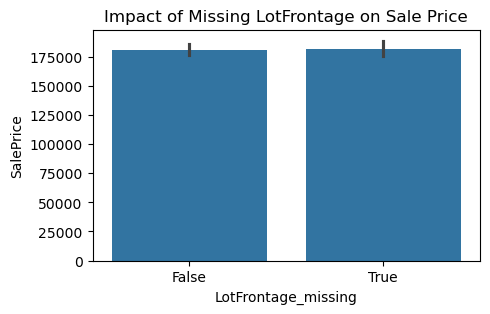

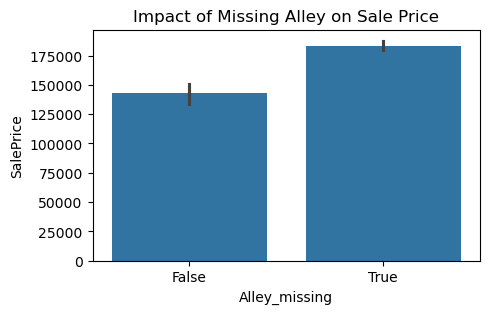

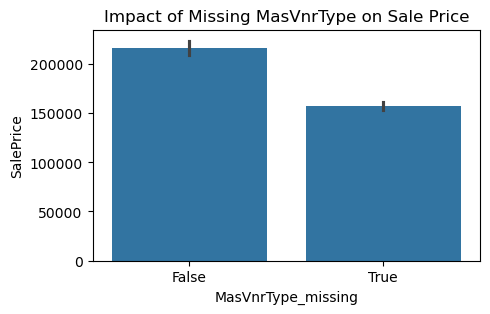

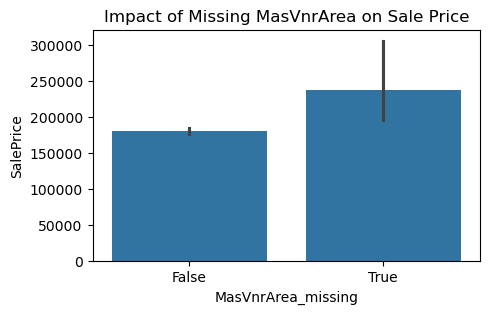

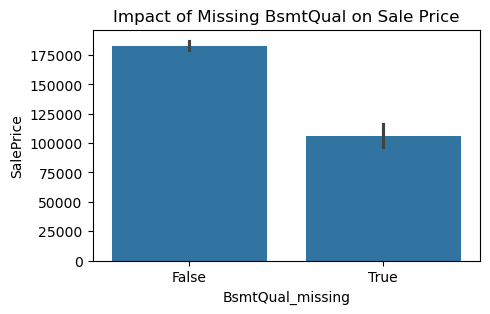

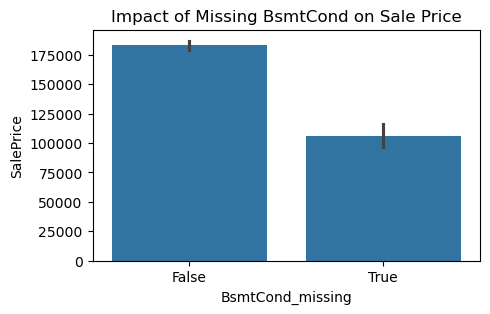

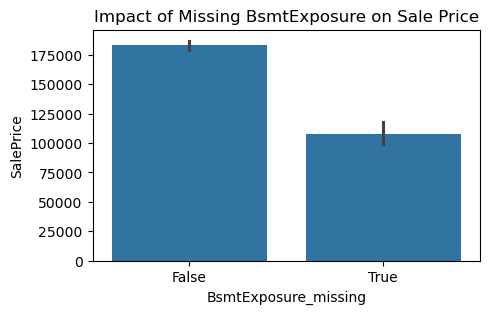

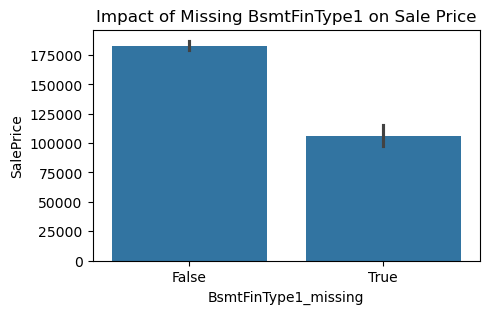

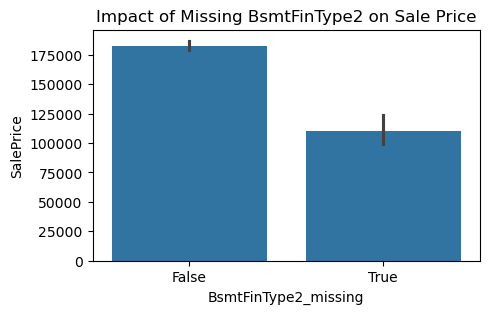

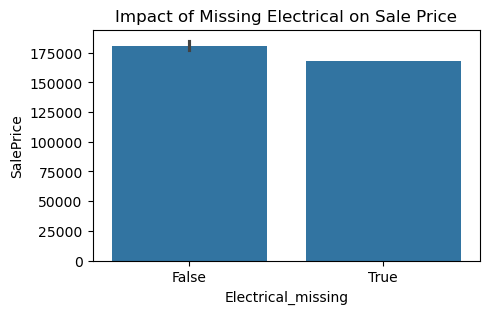

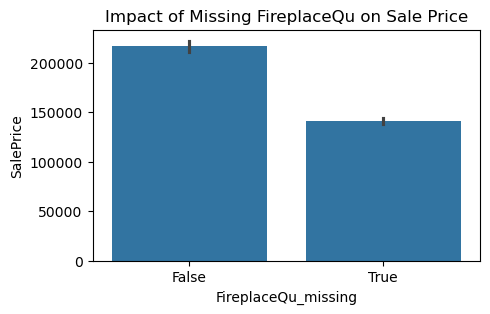

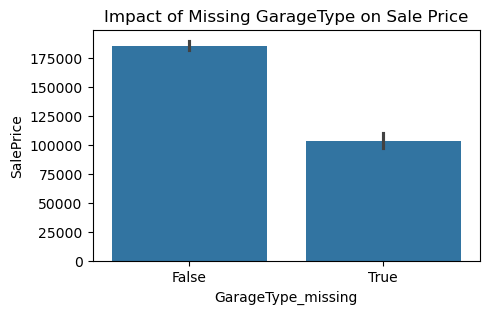

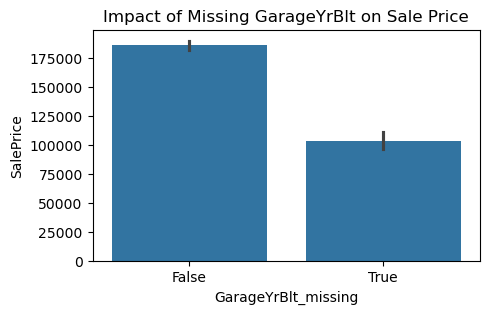

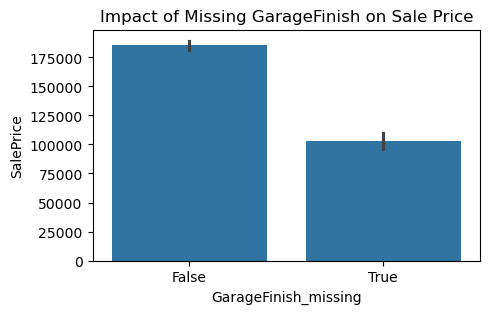

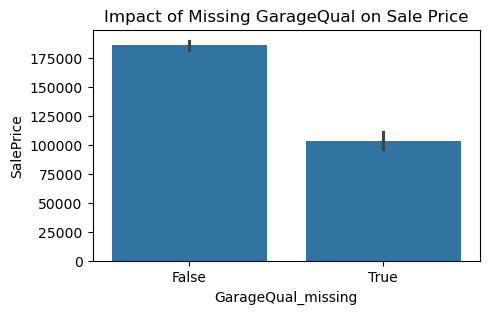

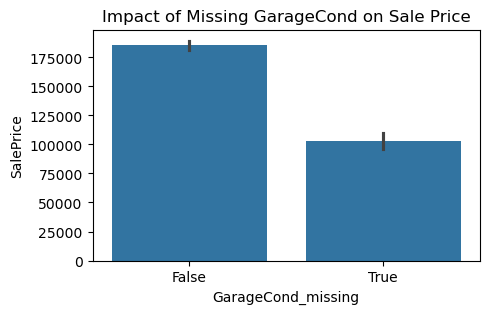

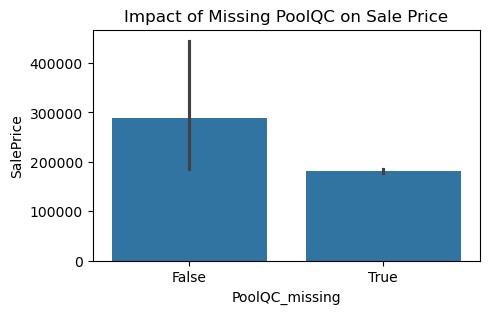

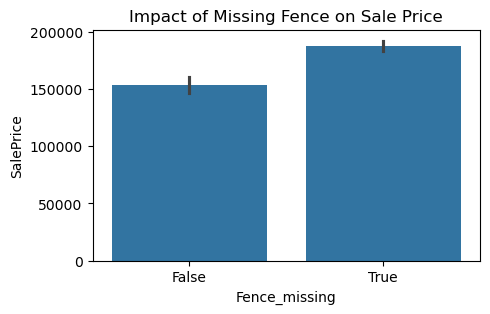

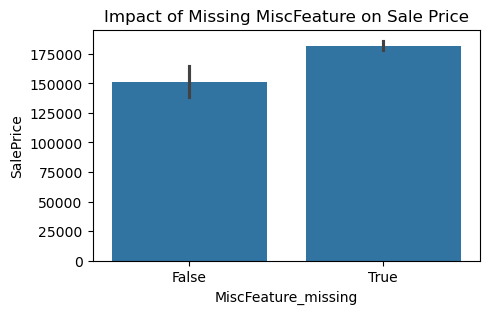

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in missing_cols:
    # Create missing indicator
    missing_flag = col + '_missing'
    df_house[missing_flag] = df_house[col].isnull()
    
    plt.figure(figsize=(5,3))
    sns.barplot(
        x = col + '_missing',
        y = 'SalePrice',
        data = df_house
    )
    plt.title(f"Impact of Missing {col} on Sale Price")
    plt.ylabel('SalePrice')
    plt.xlabel(f'{col}_missing')
    plt.show()

In [14]:
# Handle categorical features where missing = "Not Present"
# Basement features
bsmt_cols = [
    'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2'
]

for col in bsmt_cols:
    df_house[col] = df_house[col].fillna('NoBasement')


# Garage features
garage_cols = [
    'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond'
]

for col in garage_cols:
    df_house[col] = df_house[col].fillna('NoGarage')


# Fireplace
df_house['FireplaceQu'] = df_house['FireplaceQu'].fillna('NoFireplace')


# High-missing but informative features
df_house['PoolQC'] = df_house['PoolQC'].fillna('NoPool')
df_house['Fence'] = df_house['Fence'].fillna('NoFence')
df_house['Alley'] = df_house['Alley'].fillna('NoAlley')
df_house['MiscFeature'] = df_house['MiscFeature'].fillna('None')


In [15]:
df_house['MasVnrArea'] = df_house['MasVnrArea'].fillna(0)
df_house['GarageYrBlt'] = df_house['GarageYrBlt'].fillna(0)
df_house['MasVnrType'] = df_house['MasVnrType'].fillna("None")

df_house['LotFrontage'] = df_house['LotFrontage'].fillna(df_house['LotFrontage'].median())
df_house['Electrical'] = df_house['Electrical'].fillna(df_house['Electrical'].mode()[0])

In [16]:
# Save values from TRAIN data To Apply SAME values to TEST data:
lotfrontage_median = df_house['LotFrontage'].median()
electrical_mode = df_house['Electrical'].mode()[0]

In [17]:
df_house.isnull().sum()[df_house.isnull().sum() > 0]

Series([], dtype: int64)

In [18]:
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontage_missing,Alley_missing,MasVnrType_missing,MasVnrArea_missing,BsmtQual_missing,BsmtCond_missing,BsmtExposure_missing,BsmtFinType1_missing,BsmtFinType2_missing,Electrical_missing,FireplaceQu_missing,GarageType_missing,GarageYrBlt_missing,GarageFinish_missing,GarageQual_missing,GarageCond_missing,PoolQC_missing,Fence_missing,MiscFeature_missing
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NoFireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NoPool,NoFence,None,0,2,2008,WD,Normal,208500,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True,True
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NoPool,NoFence,None,0,5,2007,WD,Normal,181500,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NoPool,NoFence,None,0,9,2008,WD,Normal,223500,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NoPool,NoFence,None,0,2,2006,WD,Abnorml,140000,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NoPool,NoFence,None,0,12,2008,WD,Normal,250000,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True


In [19]:
df_house.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [20]:
cols_to_drop = [col + '_missing' for col in [
    'LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature'
]]

df_house.drop(columns=cols_to_drop, inplace=True)

In [21]:
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NoFireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NoPool,NoFence,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NoPool,NoFence,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NoPool,NoFence,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NoPool,NoFence,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NoPool,NoFence,None,0,12,2008,WD,Normal,250000


In [22]:
# Check for Duplicates
df_house.duplicated().sum()

np.int64(0)

In [23]:
# To check Wrong Data Types
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [24]:
# MSSubClass: Stored as int , Values: 20, 30, 60, 120
# Real meaning: These are codes, not quantities
# Treating them as numbers is wrong, Should be categorical
df_house['MSSubClass'] = df_house['MSSubClass'].astype('category')

In [25]:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   category
 2   MSZoning       1460 non-null   object  
 3   LotFrontage    1460 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   object  
 6   Alley          1460 non-null   object  
 7   LotShape       1460 non-null   object  
 8   LandContour    1460 non-null   object  
 9   Utilities      1460 non-null   object  
 10  LotConfig      1460 non-null   object  
 11  LandSlope      1460 non-null   object  
 12  Neighborhood   1460 non-null   object  
 13  Condition1     1460 non-null   object  
 14  Condition2     1460 non-null   object  
 15  BldgType       1460 non-null   object  
 16  HouseStyle     1460 non-null   object  
 17  OverallQual    1460 non-null   in

In [26]:
# To check wrong values
# for Numerical columns
df_house.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
LotFrontage,1460.0,69.863699,22.027677,21.0,60.00,69.0,79.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1460.0,103.117123,180.731373,0.0,0.00,0.0,164.25,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [27]:
zero_cols  = ['GarageYrBlt', 'BedroomAbvGr', 'KitchenAbvGr']


===== Zero Impact Analysis for GarageYrBlt =====
GarageYrBlt
False    185479.511240
True     103317.283951
Name: SalePrice, dtype: float64


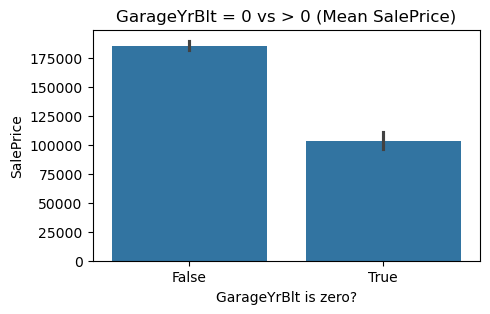


===== Zero Impact Analysis for BedroomAbvGr =====
BedroomAbvGr
False    180753.773728
True     221493.166667
Name: SalePrice, dtype: float64


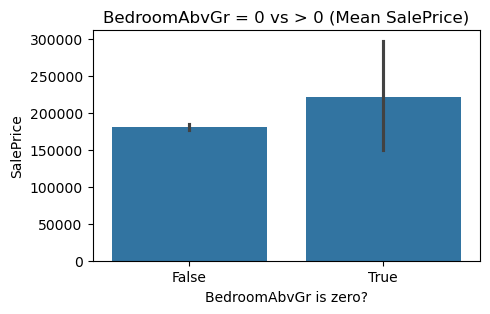


===== Zero Impact Analysis for KitchenAbvGr =====
KitchenAbvGr
False    180957.810829
True     127500.000000
Name: SalePrice, dtype: float64


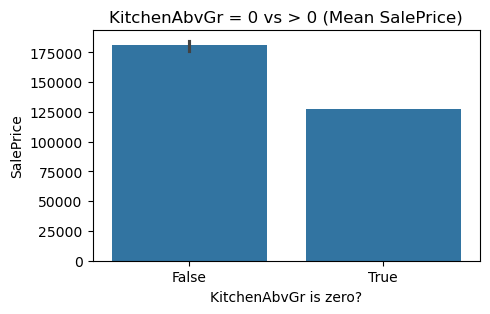

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in zero_cols:
    print(f"\n===== Zero Impact Analysis for {col} =====")
    
    # Mean comparison
    print(df_house.groupby(df_house[col] == 0)['SalePrice'].mean())
    
    # Barplot
    df_house['is_zero'] = df_house[col] == 0
    
    plt.figure(figsize=(5,3))
    sns.barplot(x='is_zero', y='SalePrice', data=df_house)
    plt.title(f"{col} = 0 vs > 0 (Mean SalePrice)")
    plt.xlabel(f"{col} is zero?")
    plt.ylabel("SalePrice")
    plt.show()


In [29]:
import numpy as np
# GarageYrBlt (zero = no garage)
df_house['GarageYrBlt'] = df_house['GarageYrBlt'].replace(0, np.nan)
df_house['HasGarage'] = df_house['GarageYrBlt'].notna().astype(int)
df_house['GarageYrBlt'] = df_house['GarageYrBlt'].fillna(df_house['GarageYrBlt'].median())

# BedroomAbvGr (zero not possible)
df_house['BedroomAbvGr'] = df_house['BedroomAbvGr'].replace(0, np.nan)
df_house['BedroomAbvGr'] = df_house['BedroomAbvGr'].fillna(df_house['BedroomAbvGr'].median())

# KitchenAbvGr (zero not possible)
df_house['KitchenAbvGr'] = df_house['KitchenAbvGr'].replace(0, np.nan)
df_house['KitchenAbvGr'] = df_house['KitchenAbvGr'].fillna(1)


In [30]:
# Save values from TRAIN data To Apply SAME values to TEST data:
garage_year_median = df_house['GarageYrBlt'].replace(0, np.nan).median()
bedroom_median = df_house['BedroomAbvGr'].replace(0, np.nan).median()


In [31]:
df_house.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
LotFrontage,1460.0,69.863699,22.027677,21.0,60.00,69.0,79.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1460.0,103.117123,180.731373,0.0,0.00,0.0,164.25,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [32]:
df_house.drop(columns=['is_zero'], inplace=True)

In [33]:
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HasGarage
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3.0,1.0,Gd,8,Typ,0,NoFireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NoPool,NoFence,None,0,2,2008,WD,Normal,208500,1
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3.0,1.0,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NoPool,NoFence,None,0,5,2007,WD,Normal,181500,1
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3.0,1.0,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NoPool,NoFence,None,0,9,2008,WD,Normal,223500,1
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3.0,1.0,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NoPool,NoFence,None,0,2,2006,WD,Abnorml,140000,1
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4.0,1.0,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NoPool,NoFence,None,0,12,2008,WD,Normal,250000,1


In [34]:
# For categorical columns, we want to detect:
# Inconsistent values (Yes, YES, yes)
# Extra spaces ("TA " vs "TA")
# Wrong labels / typos (Excellnt instead of Excellent)

cat_cols = df_house.select_dtypes(include='object').columns
cat_cols

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [35]:
for col in cat_cols:
    print(col, ":", df_house[col].unique())

MSZoning : ['RL' 'RM' 'C (all)' 'FV' 'RH']
Street : ['Pave' 'Grvl']
Alley : ['NoAlley' 'Grvl' 'Pave']
LotShape : ['Reg' 'IR1' 'IR2' 'IR3']
LandContour : ['Lvl' 'Bnk' 'Low' 'HLS']
Utilities : ['AllPub' 'NoSeWa']
LotConfig : ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
LandSlope : ['Gtl' 'Mod' 'Sev']
Neighborhood : ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
Condition1 : ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
Condition2 : ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']
BldgType : ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
HouseStyle : ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
RoofStyle : ['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
RoofMatl : ['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll'
 'ClyTil

In [36]:
for col in cat_cols:
    print(col, ":", df_house[col].nunique())


MSZoning : 5
Street : 2
Alley : 3
LotShape : 4
LandContour : 4
Utilities : 2
LotConfig : 5
LandSlope : 3
Neighborhood : 25
Condition1 : 9
Condition2 : 8
BldgType : 5
HouseStyle : 8
RoofStyle : 6
RoofMatl : 8
Exterior1st : 15
Exterior2nd : 16
MasVnrType : 4
ExterQual : 4
ExterCond : 5
Foundation : 6
BsmtQual : 5
BsmtCond : 5
BsmtExposure : 5
BsmtFinType1 : 7
BsmtFinType2 : 7
Heating : 6
HeatingQC : 5
CentralAir : 2
Electrical : 5
KitchenQual : 4
Functional : 7
FireplaceQu : 6
GarageType : 7
GarageFinish : 4
GarageQual : 6
GarageCond : 6
PavedDrive : 3
PoolQC : 4
Fence : 5
MiscFeature : 5
SaleType : 9
SaleCondition : 6


In [37]:
for col in cat_cols:
    if df_house[col].nunique() > 10:
        print(col, ":", df_house[col].value_counts())


Neighborhood : Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64
Exterior1st : Exterior1st
VinylSd    515
HdBoard    222
MetalSd    220
Wd Sdng    206
Plywood    108
CemntBd     61
BrkFace     50
WdShing     26
Stucco      25
AsbShng     20
BrkComm      2
Stone        2
AsphShn      1
ImStucc      1
CBlock       1
Name: count, dtype: int64
Exterior2nd : Exterior2nd
VinylSd    504
MetalSd    214
HdBoard    207
Wd Sdng    197
Plywood    142
CmentBd     60
Wd Shng     38
Stucco      26
BrkFace     25
AsbShng     20
ImStucc     10
Brk Cmn      7
Stone        5
AsphShn      3
Other        1
CBlock       1
Name: count, dtype: int64


In [38]:
# Remove whitespace
for col in cat_cols:
    df_house[col] = df_house[col].str.strip()

✔️ My dataset has no data leakage columns

❌ Id is an irrelevant identifier and should be removed

--------------------------------------------------------------------------------------------------------------------------------

# STEP 5: EDA

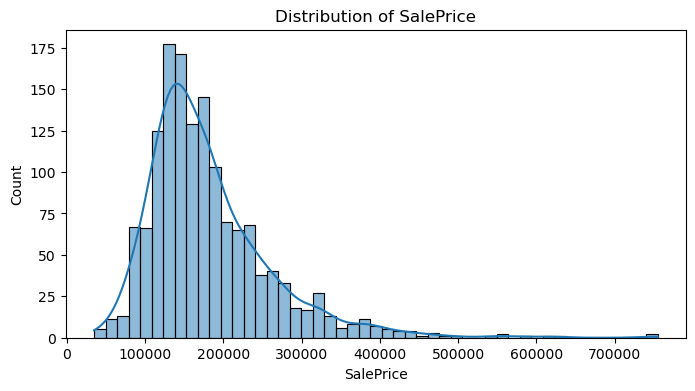

In [39]:
# Target Variable Analysis
# Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df_house['SalePrice'], kde=True)
plt.title("Distribution of SalePrice")
plt.show()


Right tail long? → right skewed

Peak on left, tail on right?

✔️ SalePrice is right-skewed

In [40]:
# Skewness
df_house['SalePrice'].skew()

np.float64(1.8828757597682129)

Skewness ≈ 1.8

✔️ Highly skewed

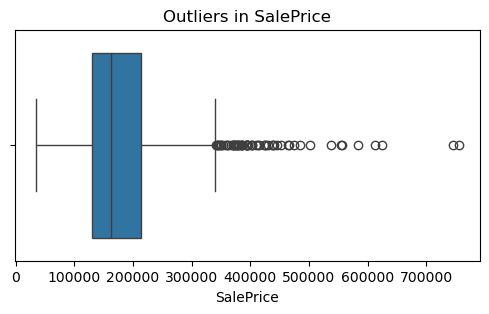

In [41]:
# Outliers
plt.figure(figsize=(6,3))
sns.boxplot(x=df_house['SalePrice'])
plt.title("Outliers in SalePrice")
plt.show()

Dots far on right side → high-price outliers

These are valid houses, not errors

📌 Important:
❌ Do NOT remove them
✔️ Handle via transformation

In [42]:
# Range / Variance of Target
df_house['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Min: 34,900
Max: 755,000
Huge range → model instability

“The target variable SalePrice is right-skewed with high-value outliers. 
To stabilize variance and reduce the impact of outliers, log transformation is considered for modeling.”

In [43]:
# Univariate Analysis:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   category
 2   MSZoning       1460 non-null   object  
 3   LotFrontage    1460 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   object  
 6   Alley          1460 non-null   object  
 7   LotShape       1460 non-null   object  
 8   LandContour    1460 non-null   object  
 9   Utilities      1460 non-null   object  
 10  LotConfig      1460 non-null   object  
 11  LandSlope      1460 non-null   object  
 12  Neighborhood   1460 non-null   object  
 13  Condition1     1460 non-null   object  
 14  Condition2     1460 non-null   object  
 15  BldgType       1460 non-null   object  
 16  HouseStyle     1460 non-null   object  
 17  OverallQual    1460 non-null   in

In [44]:
num_cols = df_house.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop(['SalePrice','Id'])


In [45]:
num_cols

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'HasGarage'],
      dtype='object')

In [46]:
df_house[num_cols].head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,HasGarage
0,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3.0,1.0,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,1
1,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3.0,1.0,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,1
2,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3.0,1.0,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008,1
3,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3.0,1.0,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006,1
4,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4.0,1.0,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008,1


In [47]:
# A. Continuous numerical features
# (Real values, wide range, magnitude matters)
# These show distribution, skewness, outliers.
continuous_cols = [
    'LotFrontage','LotArea','MasVnrArea','BsmtFinSF1','BsmtFinSF2',
    'BsmtUnfSF','TotalBsmtSF','1stFlrSF','2ndFlrSF','LowQualFinSF',
    'GrLivArea','GarageArea','WoodDeckSF','OpenPorchSF',
    'EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea','MiscVal'
]

# B. Discrete numerical features
# (Counts / small integers)
# These show frequency.
discrete_cols = [
    'BsmtFullBath','BsmtHalfBath','FullBath','HalfBath',
    'BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd',
    'Fireplaces','GarageCars'
]
# C. Numeric but categorical in nature
# (Ordered categories or yes/no encoded as numbers)
# These should be treated like categorical.
numeric_categorical_cols = [
    'OverallQual','OverallCond','HasGarage','MoSold','YrSold'
]

year_cols = [
    'YearBuilt','YearRemodAdd','GarageYrBlt'
]


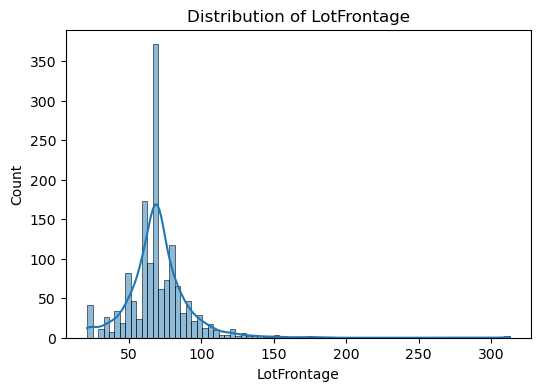

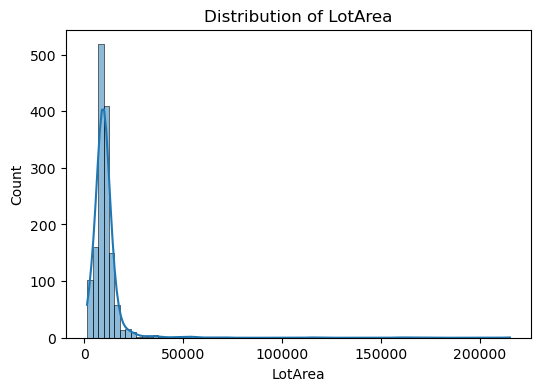

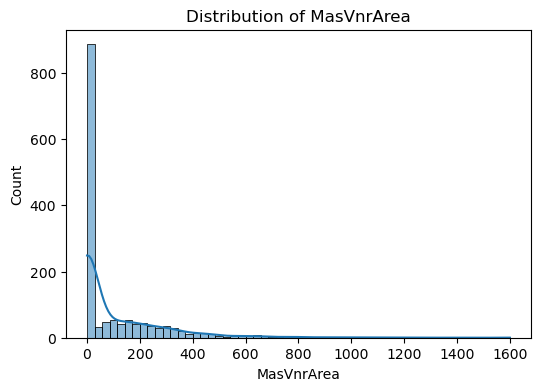

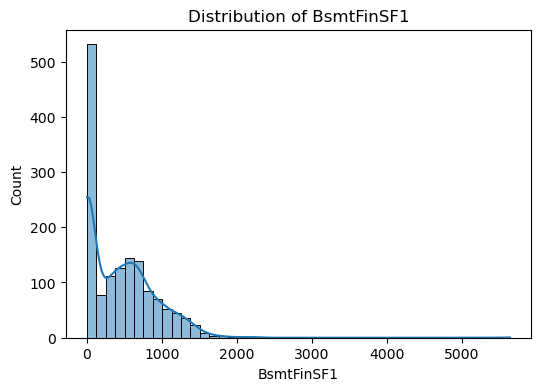

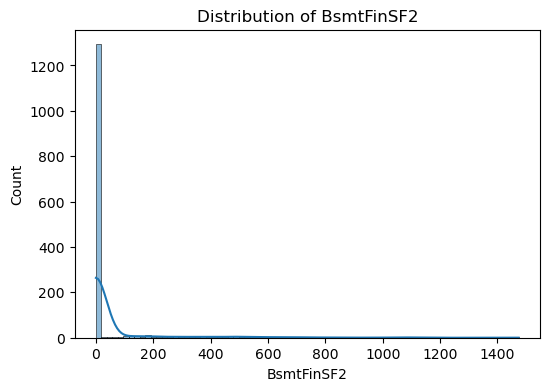

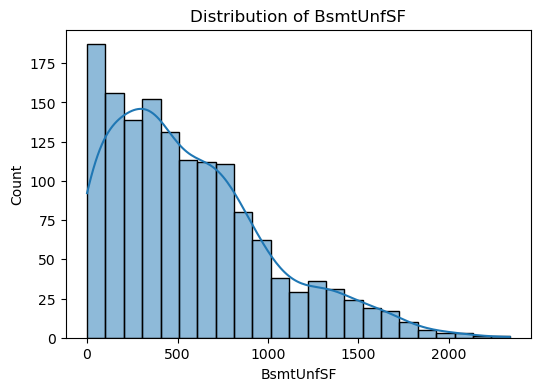

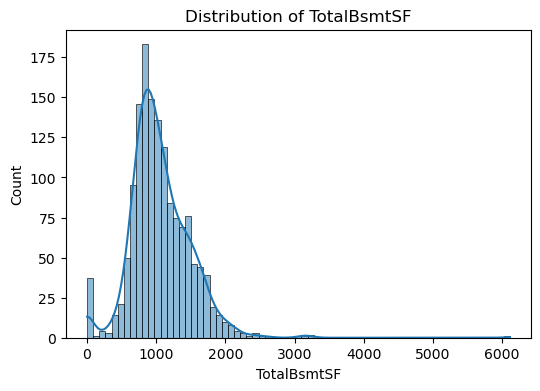

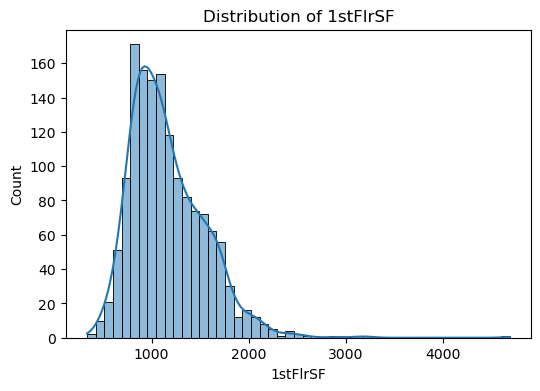

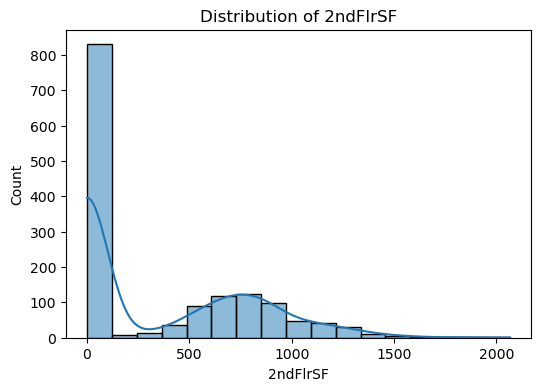

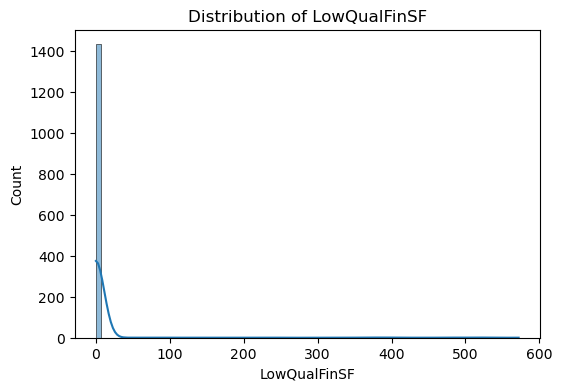

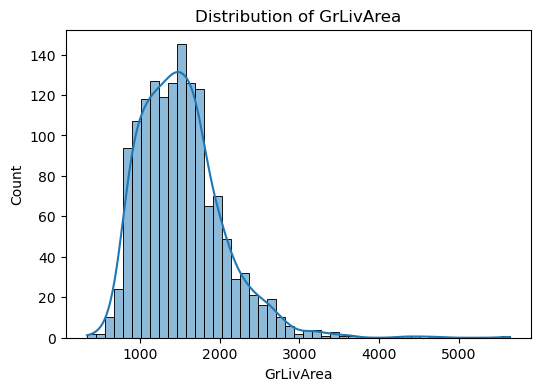

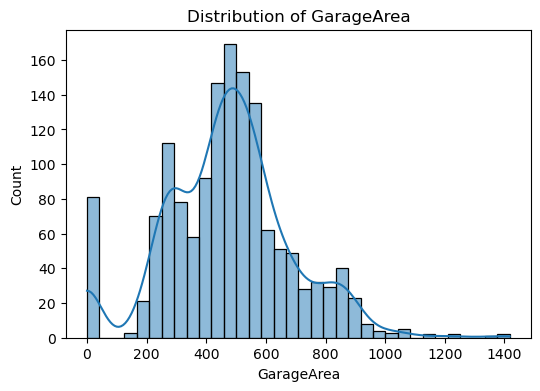

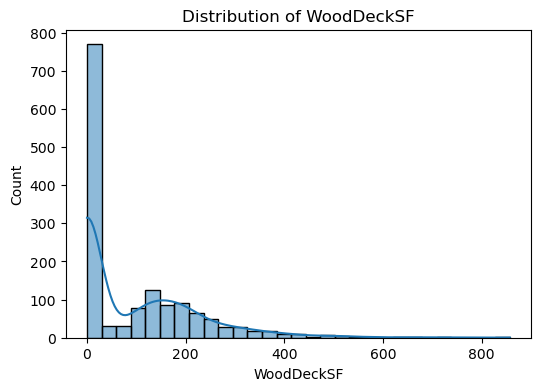

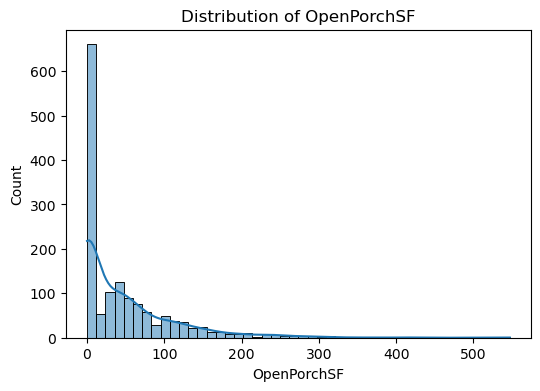

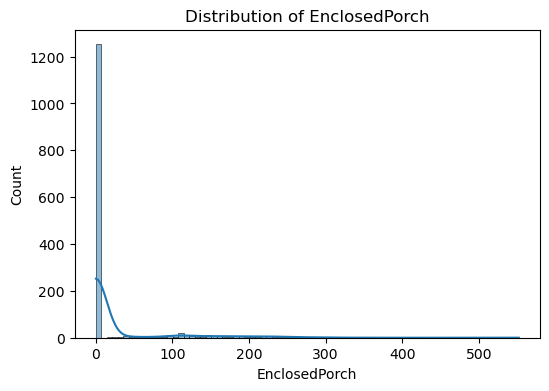

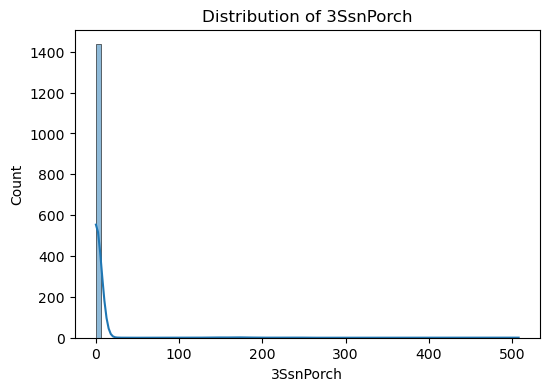

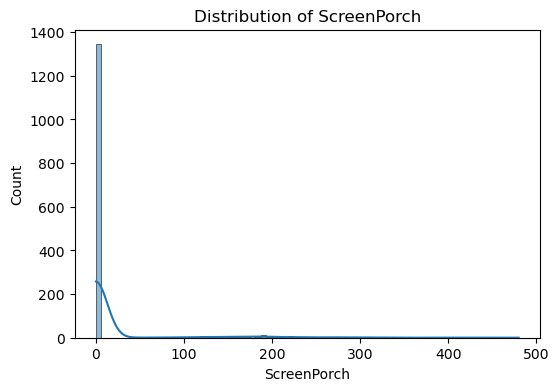

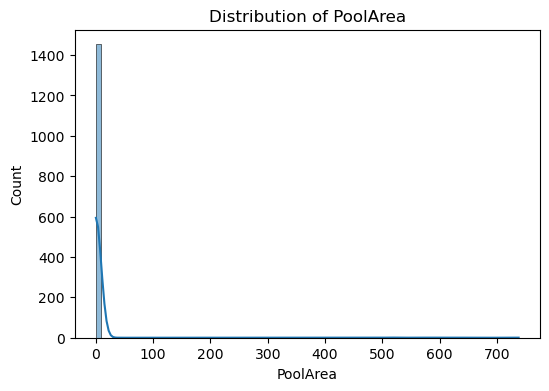

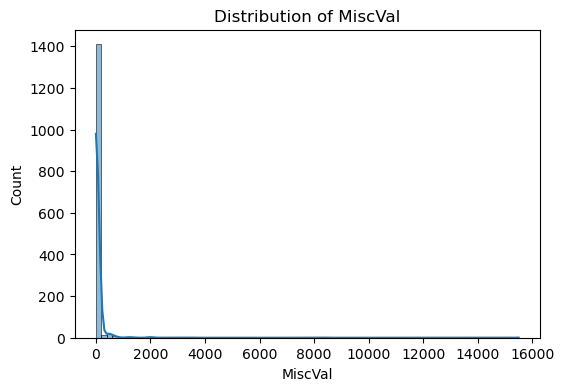

In [48]:
# A. Continuous numeric → Histogram
import seaborn as sns
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_house[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [49]:
df_house[continuous_cols].describe()

,LotFrontage,LotArea,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,69.863699,10516.828082,103.117123,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041
std,22.027677,9981.264932,180.731373,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024
min,21.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,7553.500000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,69.000000,9478.500000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,79.000000,11601.500000,164.250000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,313.000000,215245.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000


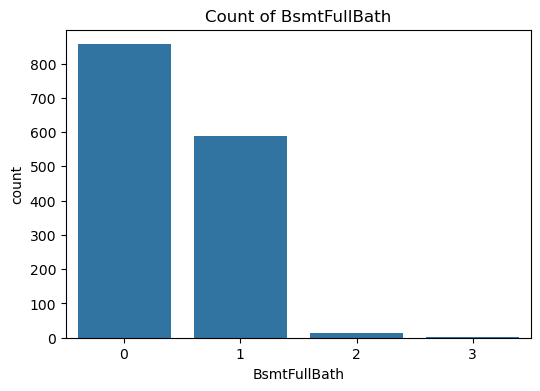

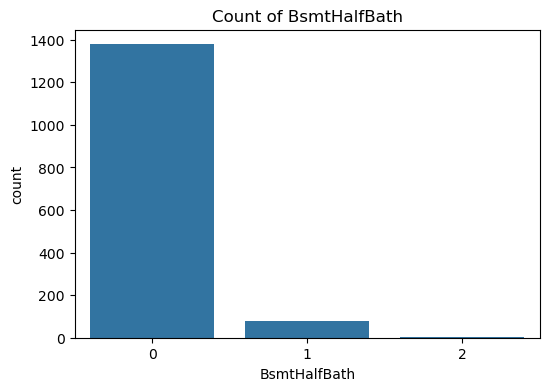

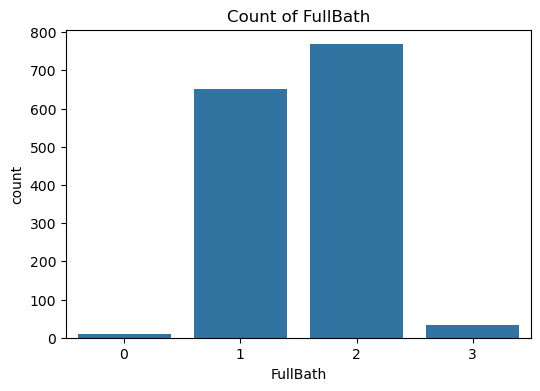

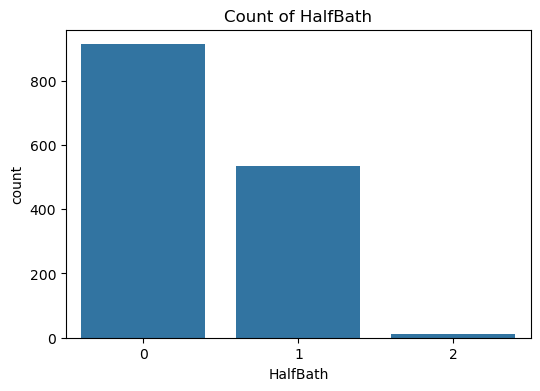

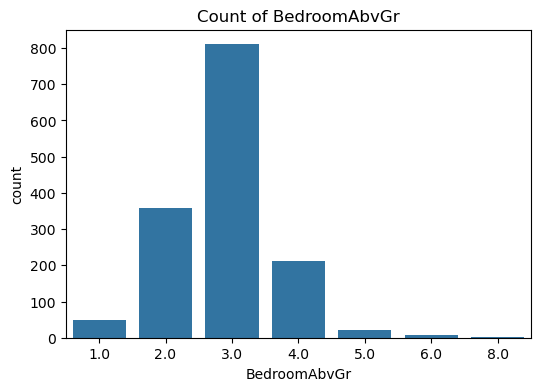

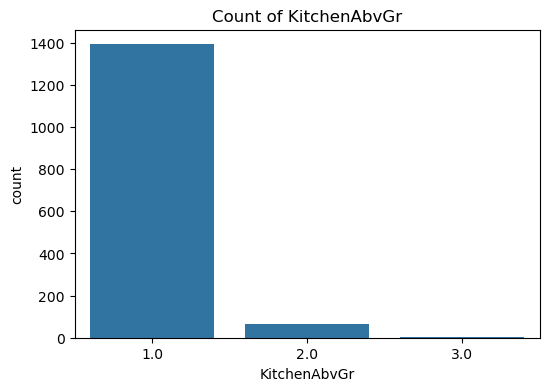

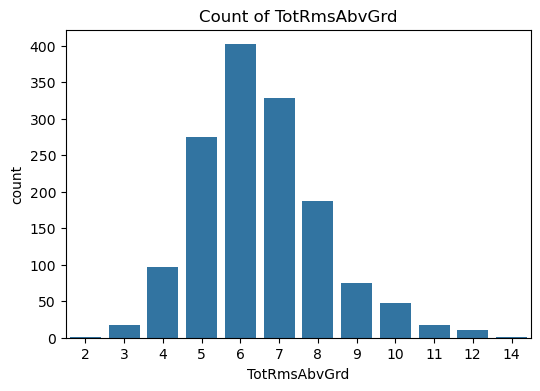

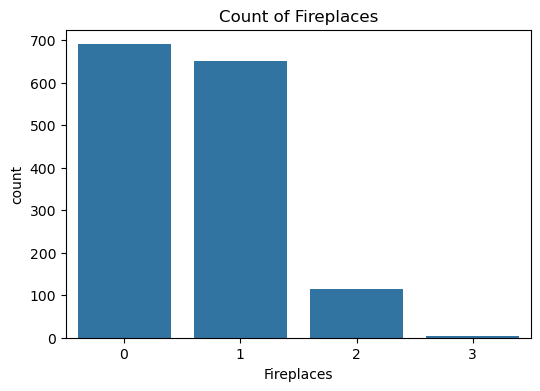

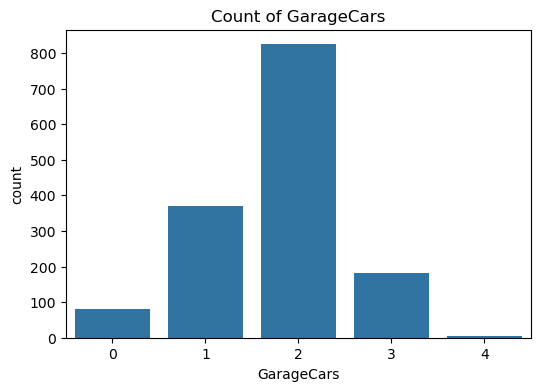

In [50]:
# B. Discrete numeric → Countplot
for col in discrete_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df_house[col])
    plt.title(f'Count of {col}')
    plt.show()

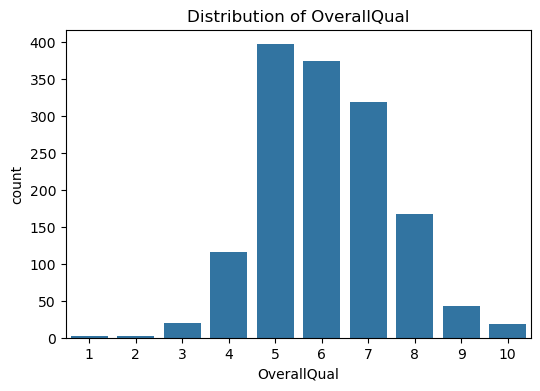

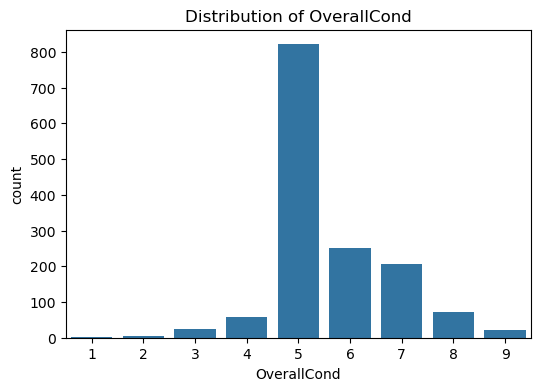

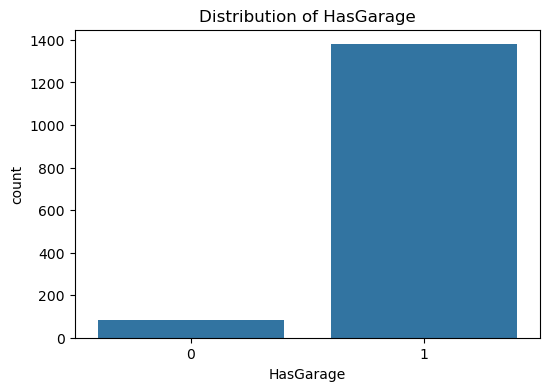

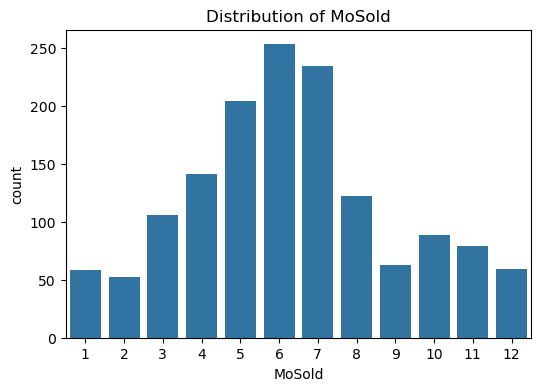

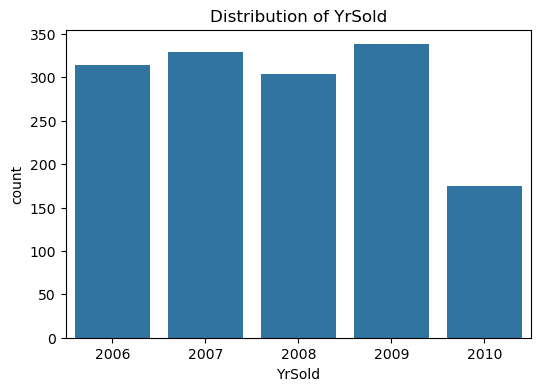

In [51]:
# C. Numeric but categorical → Countplot
for col in numeric_categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df_house[col])
    plt.title(f'Distribution of {col}')
    plt.show()

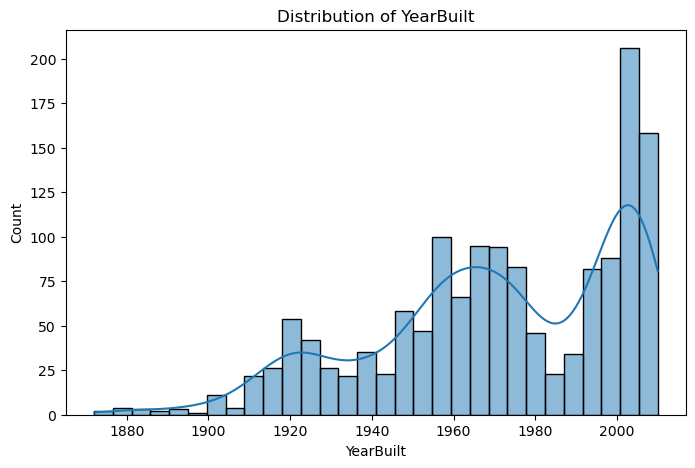

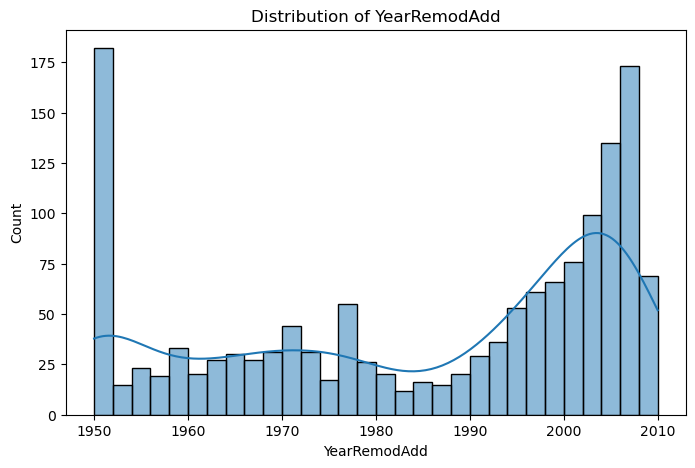

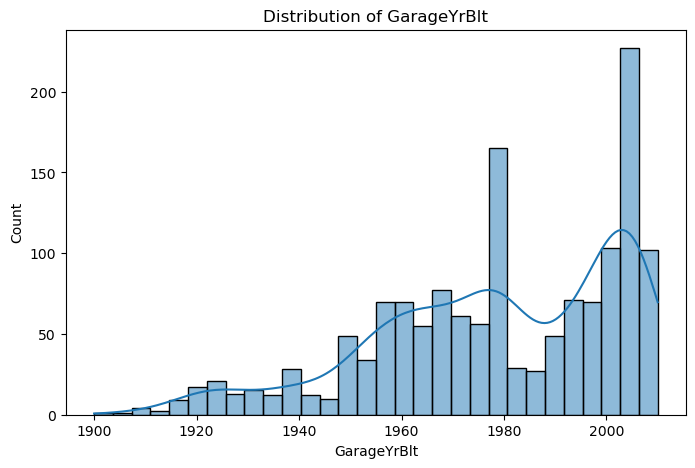

In [52]:
# Year-Based Columns (Special Case)
for col in year_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df_house[col].dropna(), bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


In [53]:
cat_cols

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

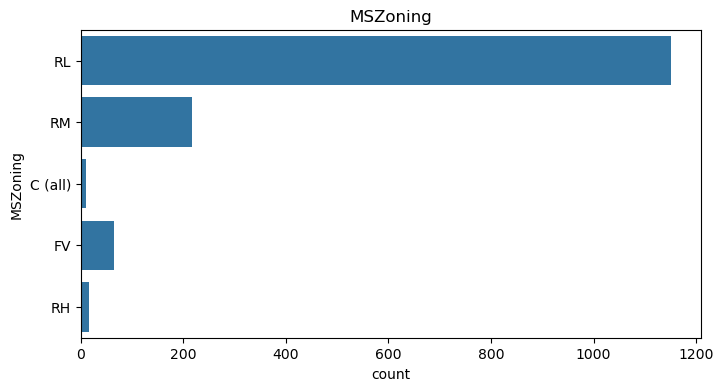

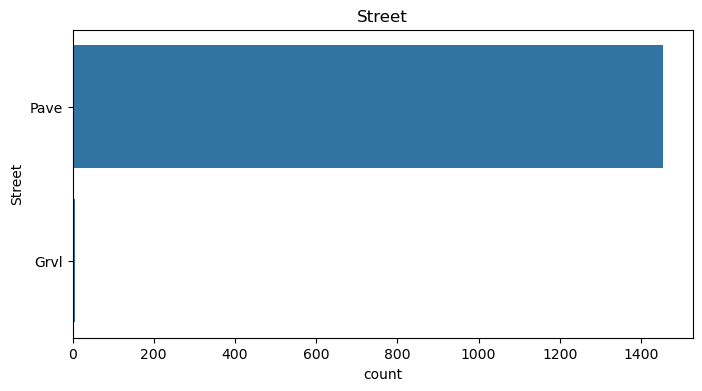

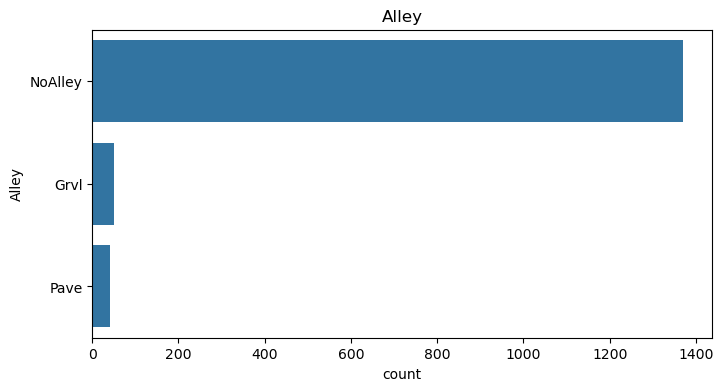

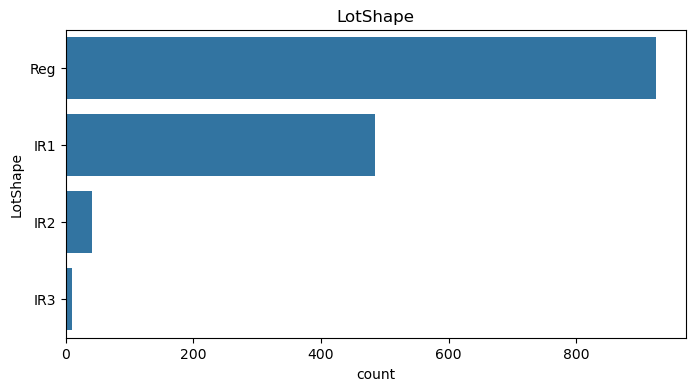

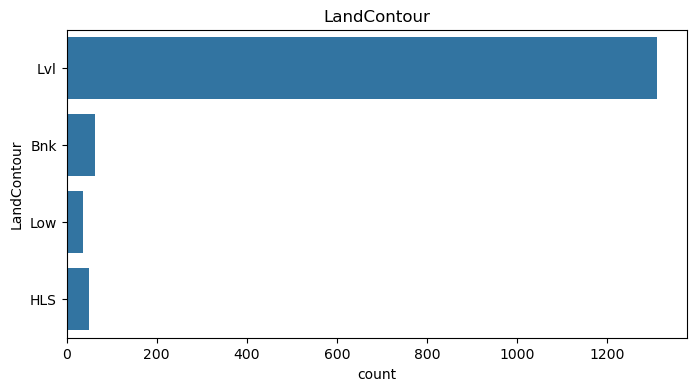

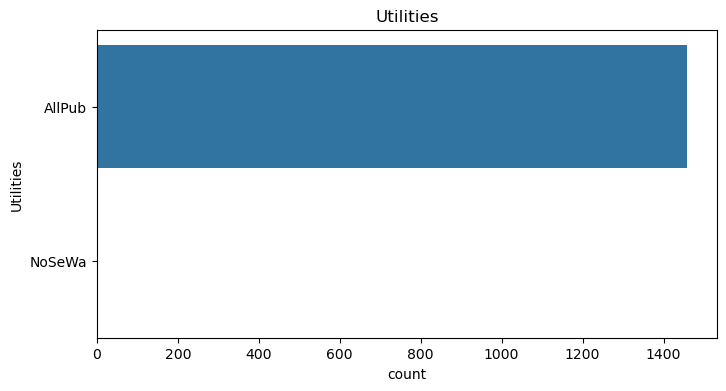

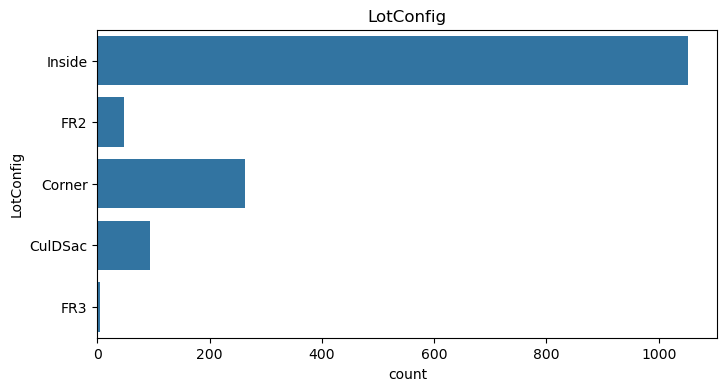

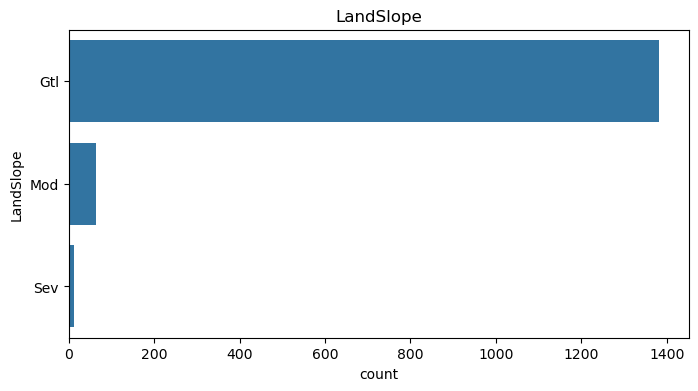

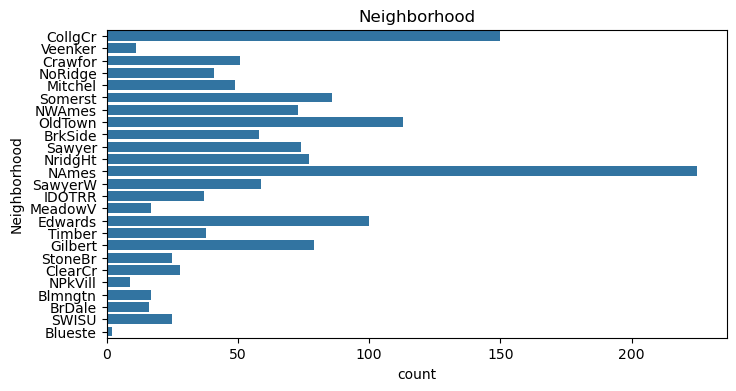

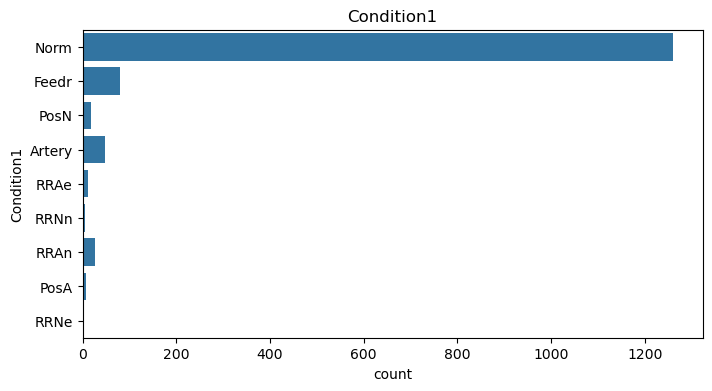

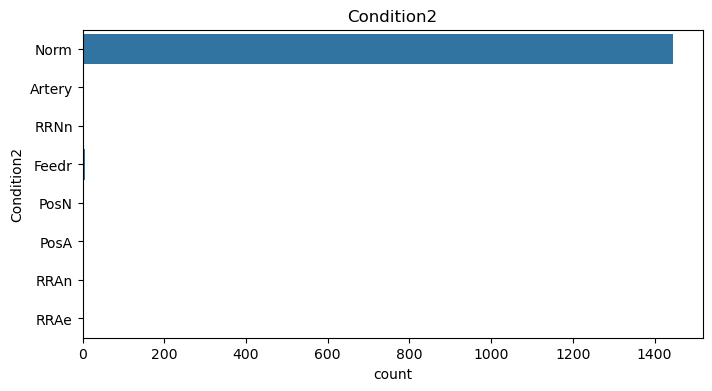

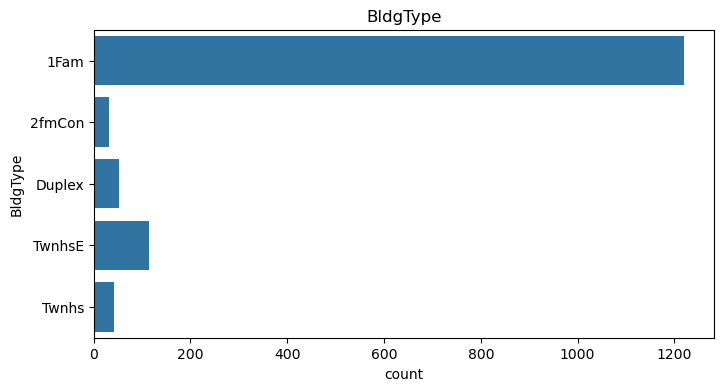

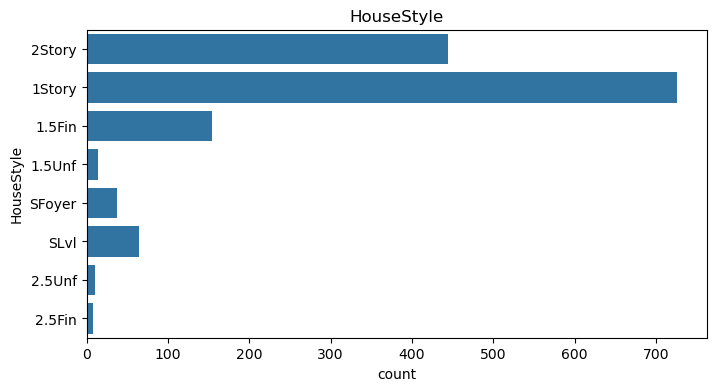

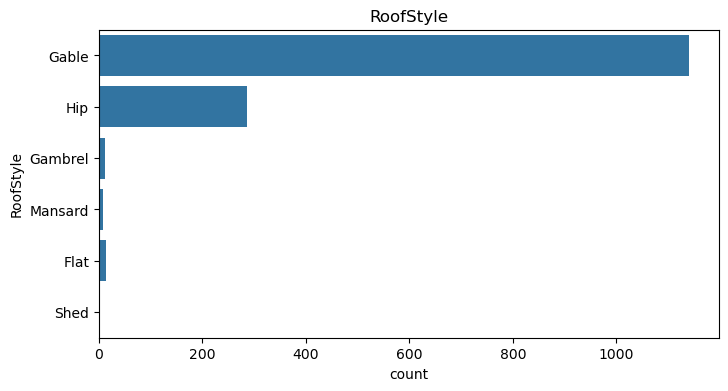

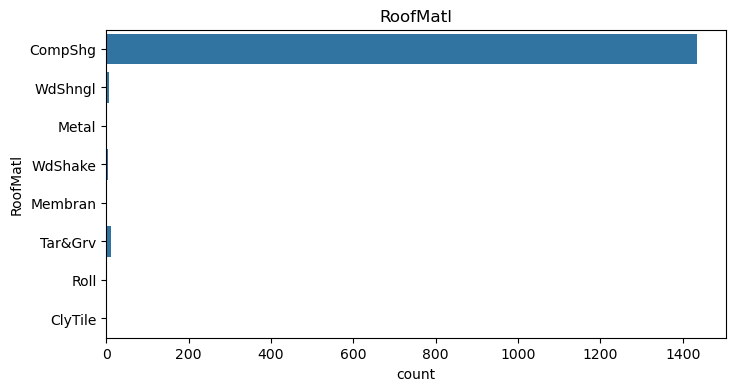

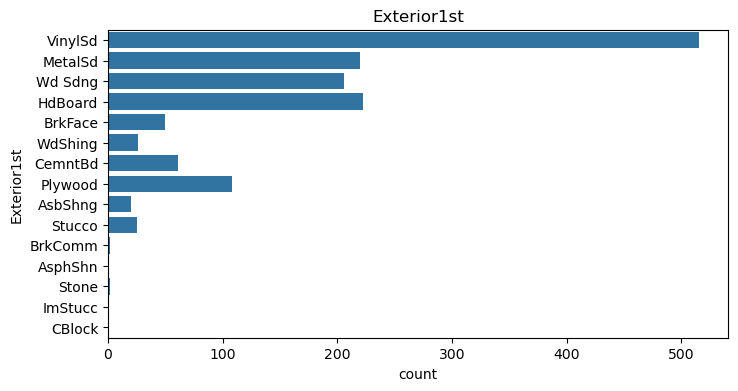

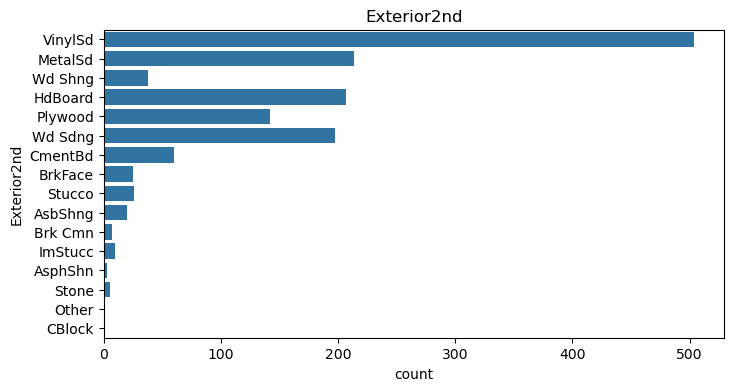

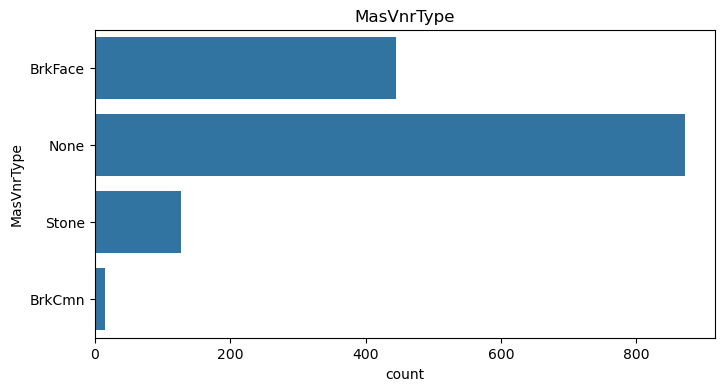

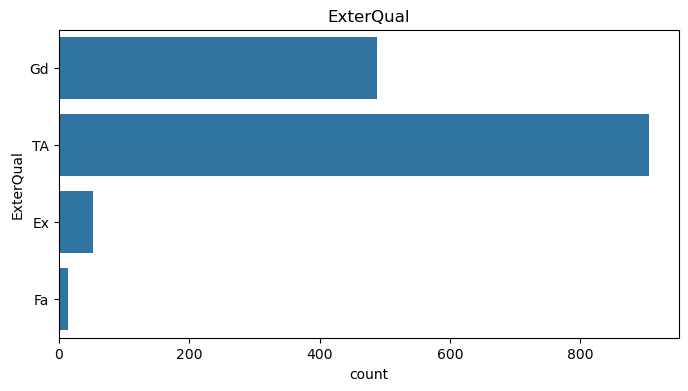

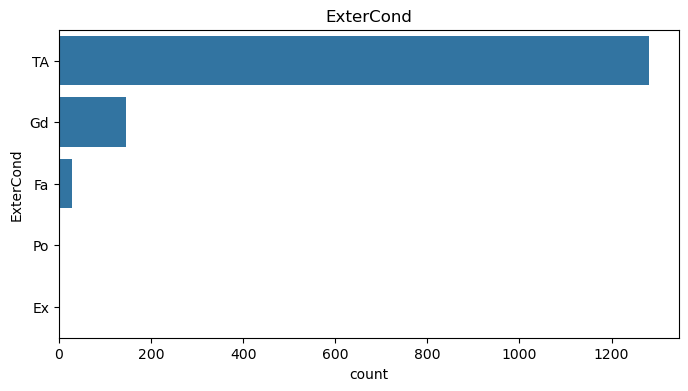

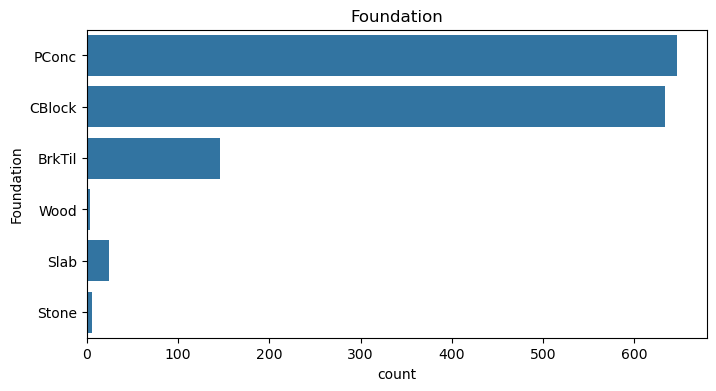

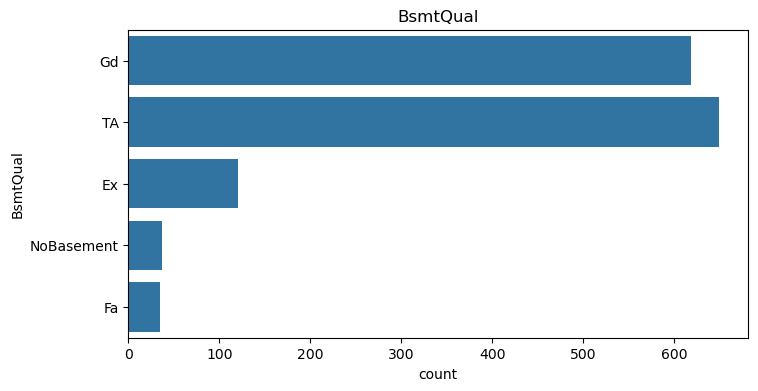

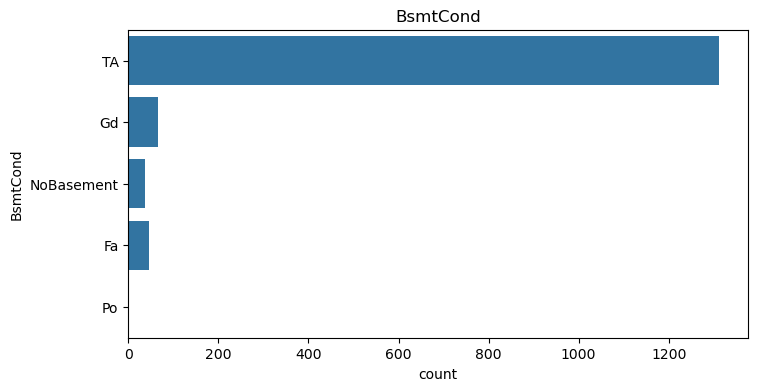

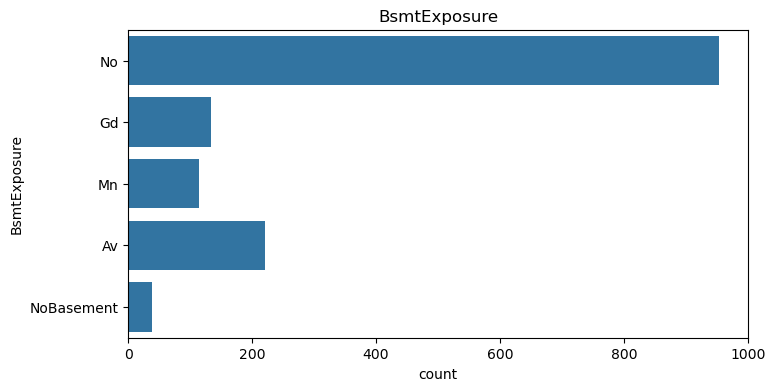

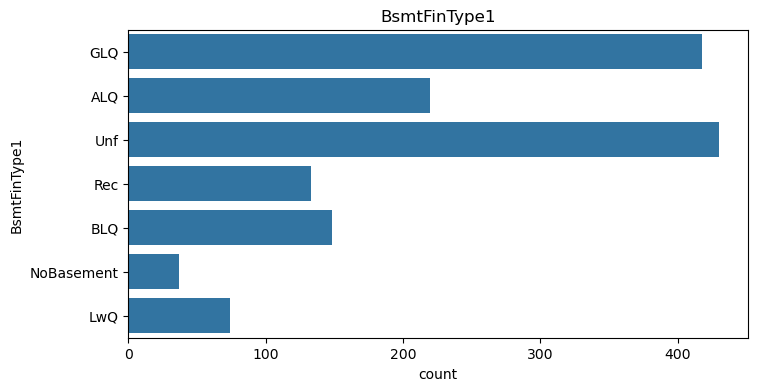

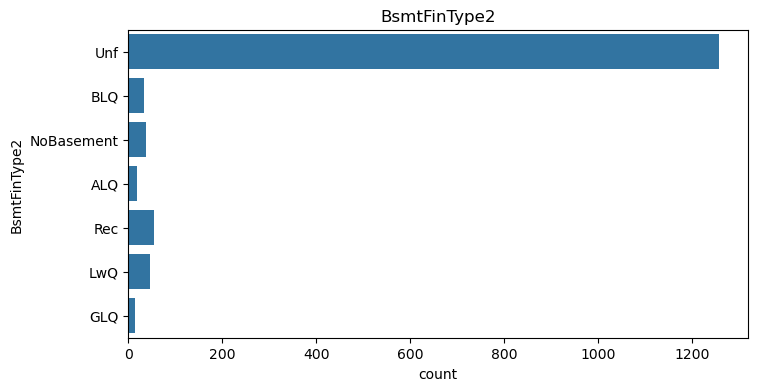

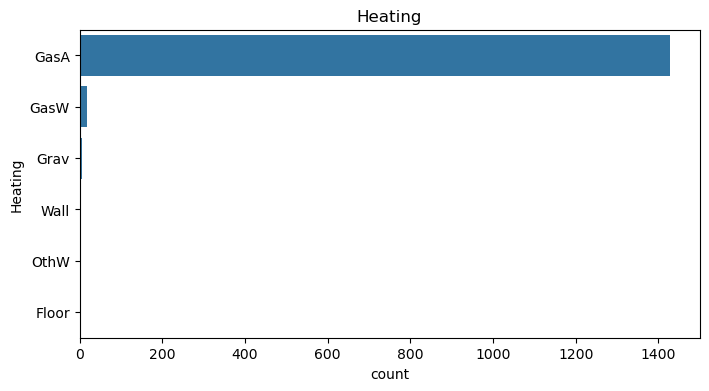

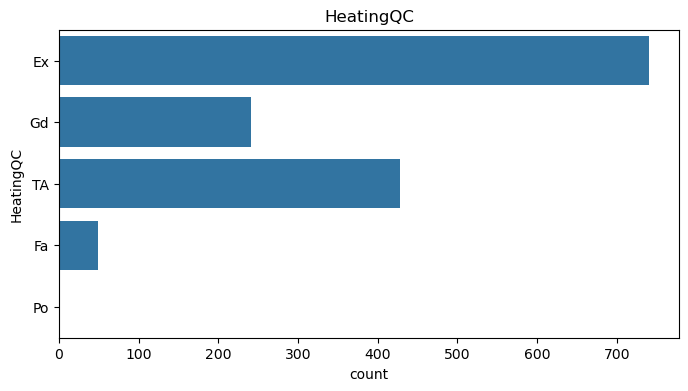

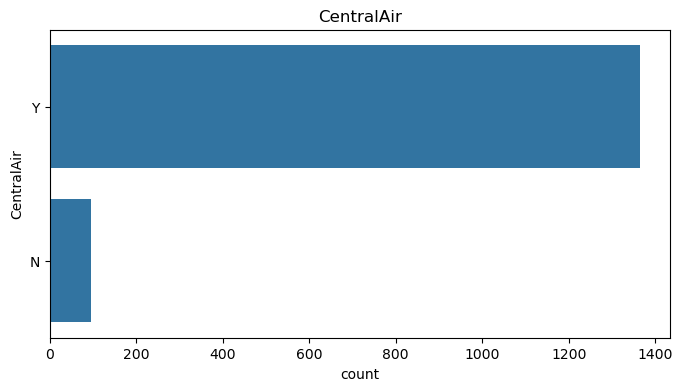

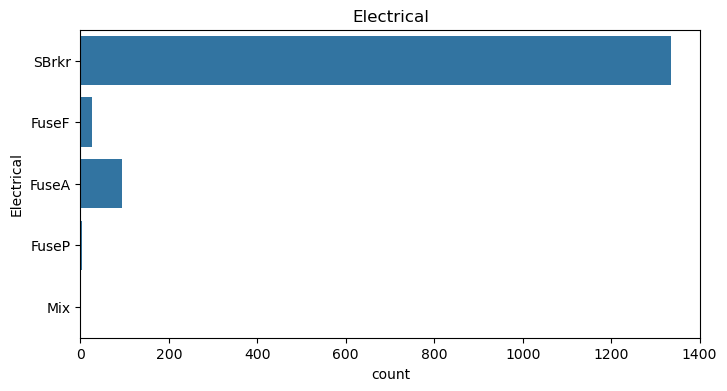

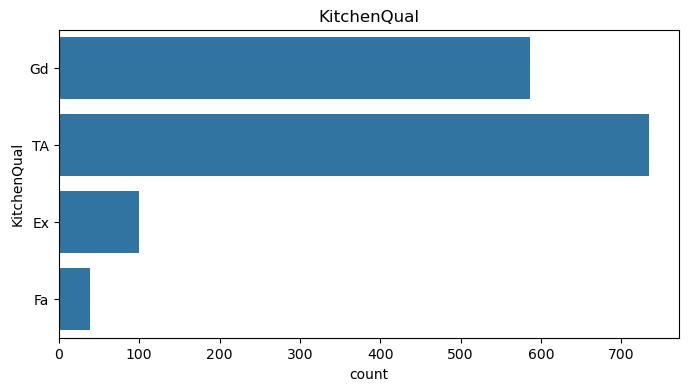

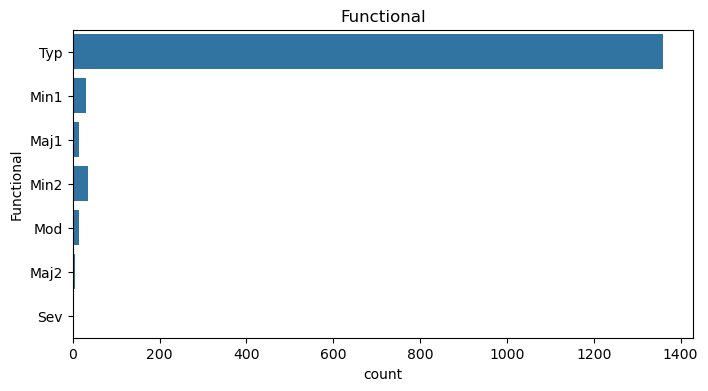

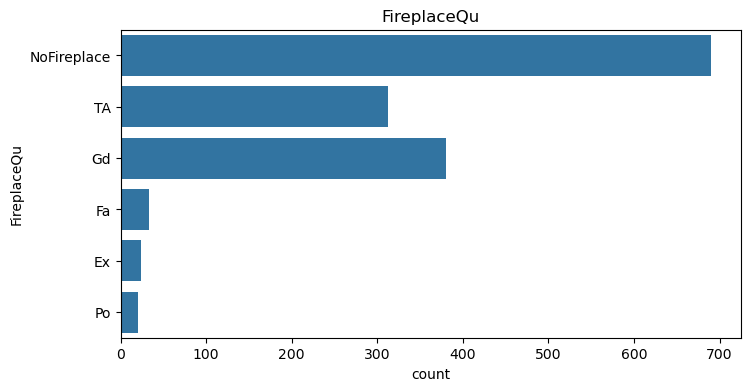

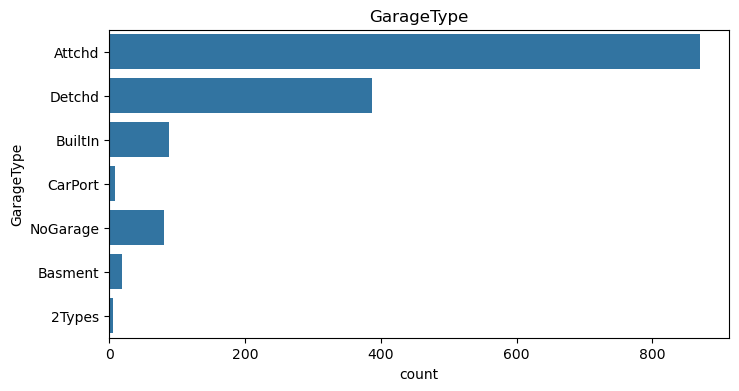

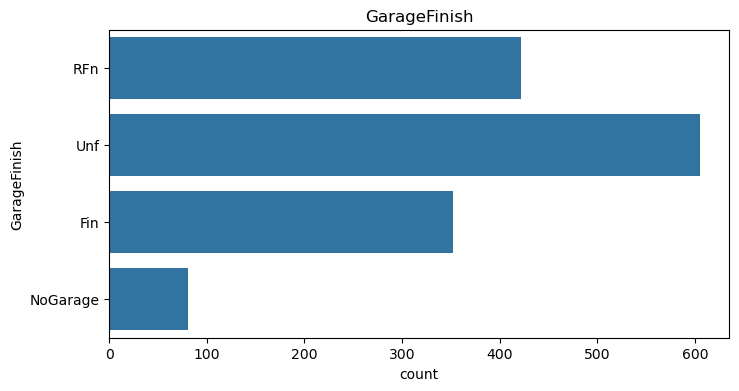

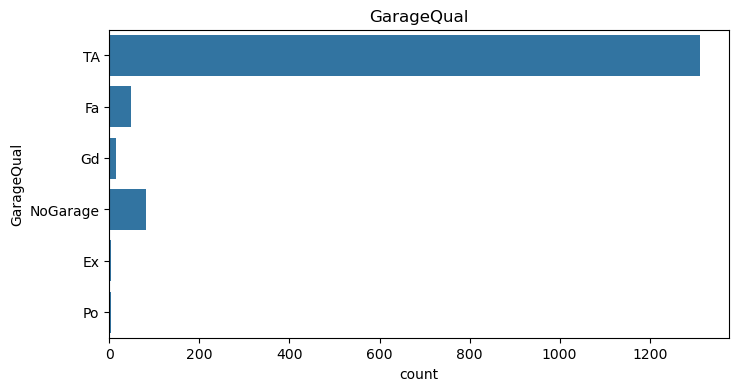

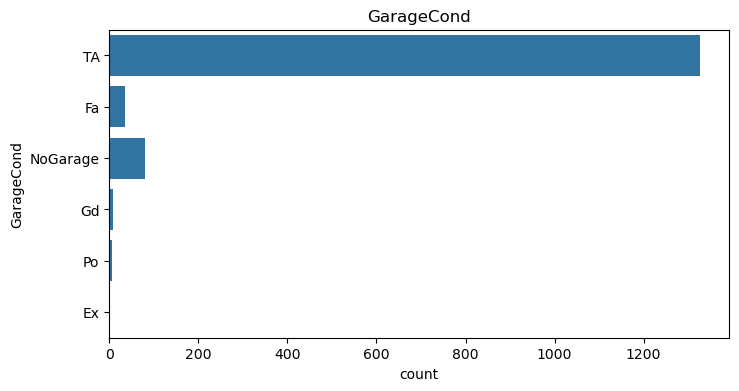

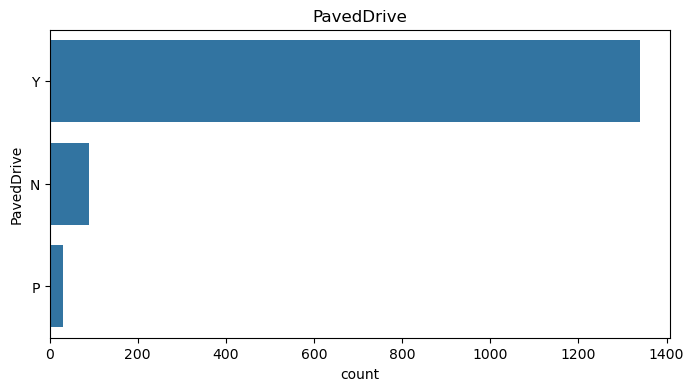

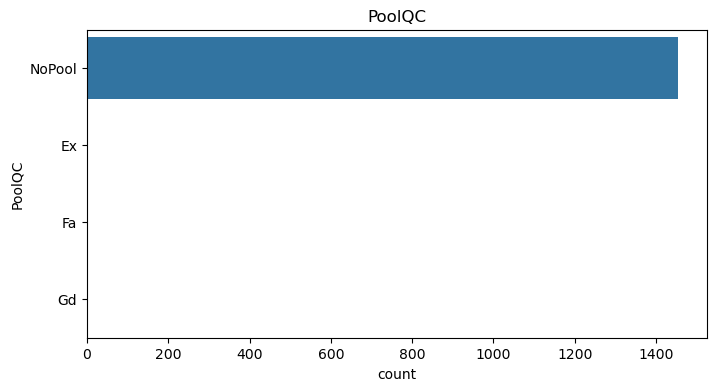

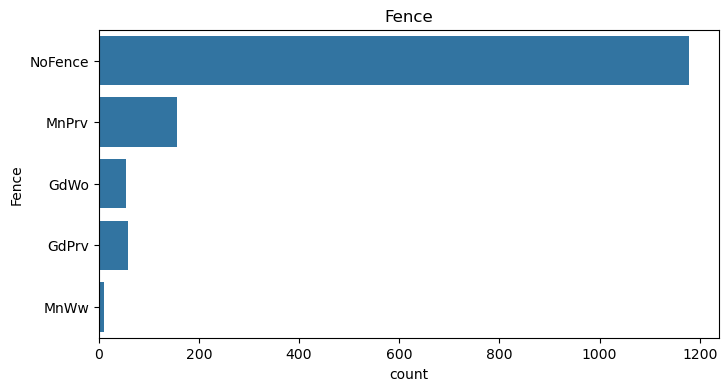

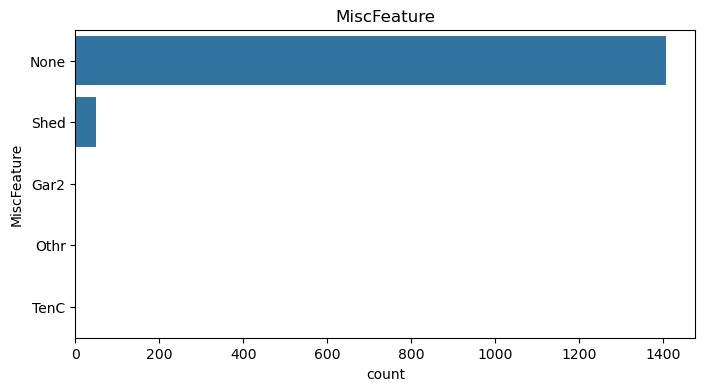

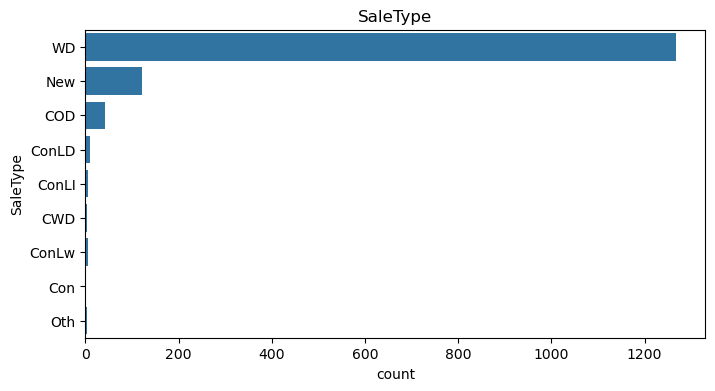

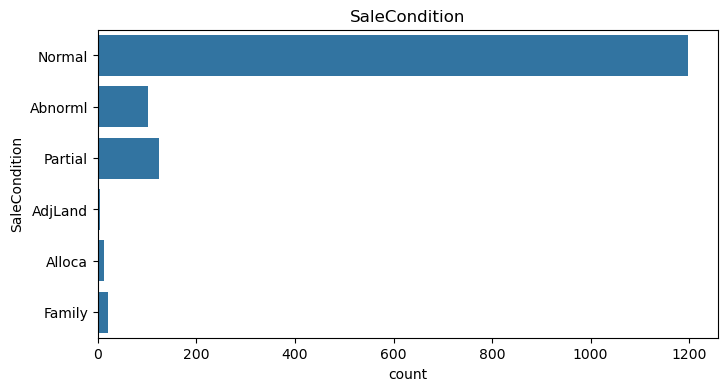

In [54]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=df_house[col])
    plt.title(col)
    plt.show()


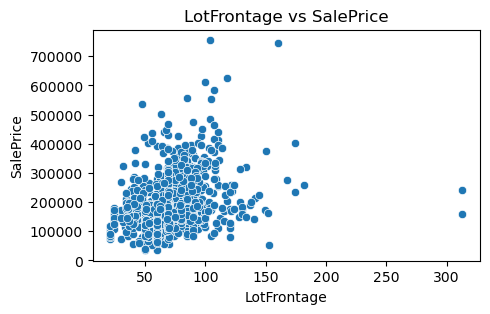

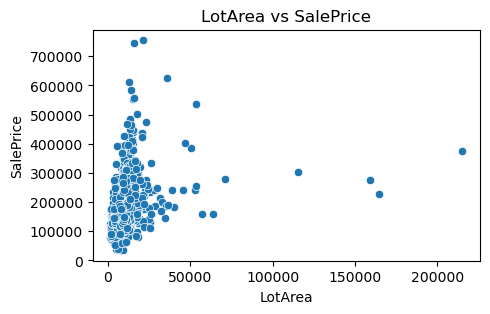

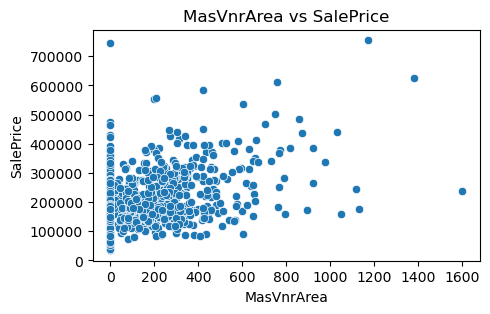

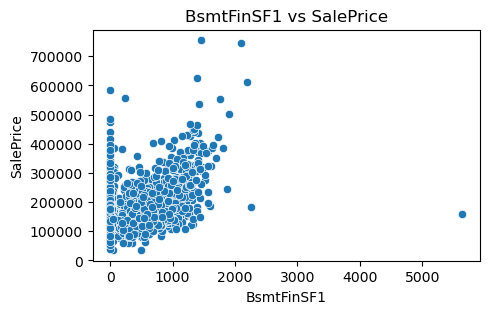

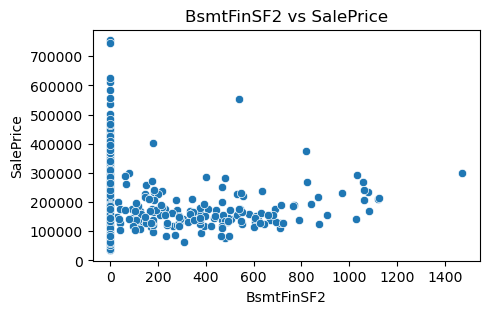

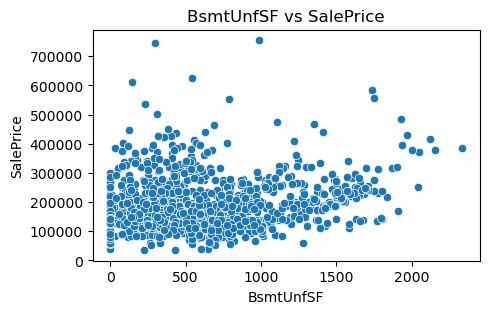

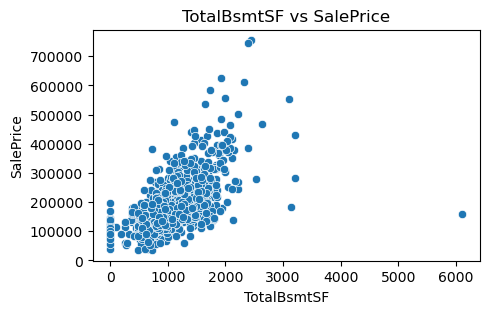

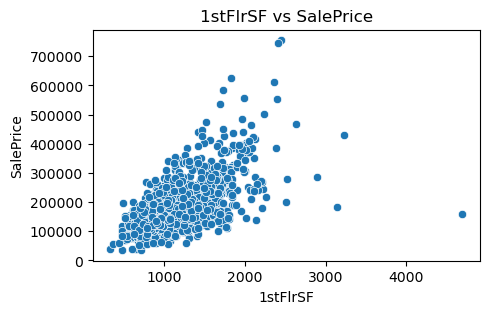

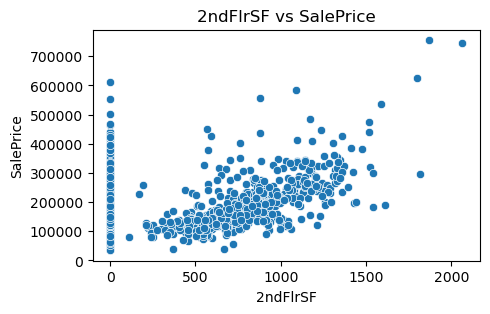

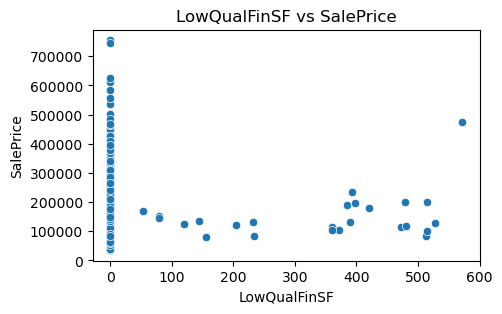

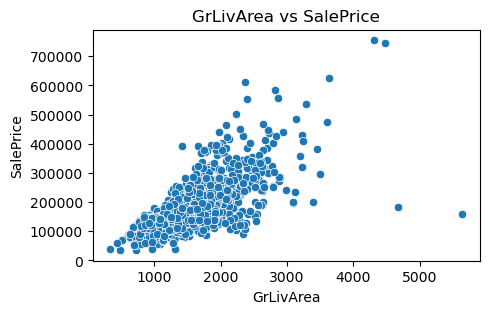

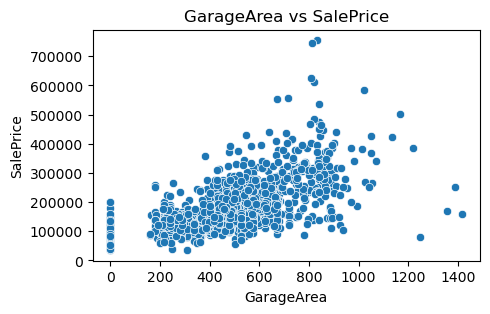

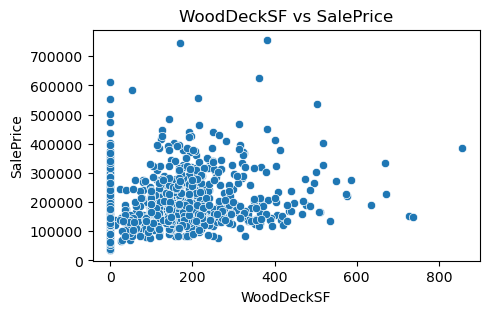

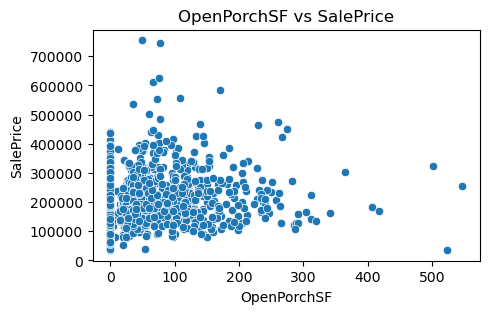

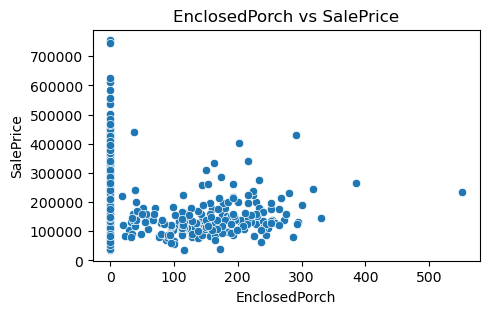

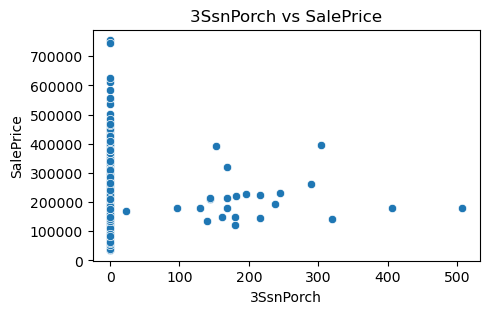

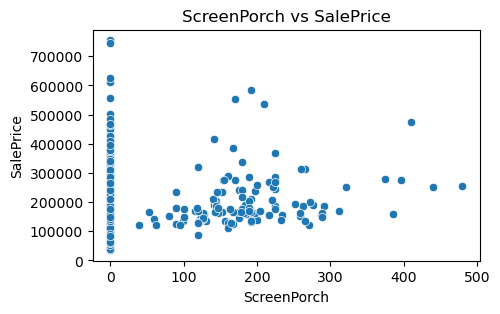

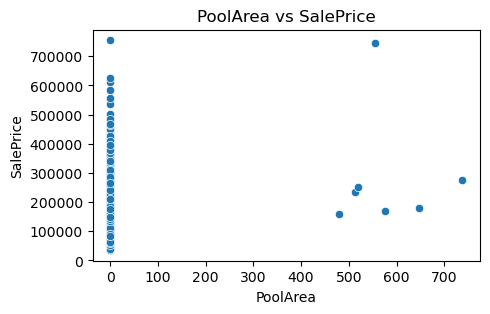

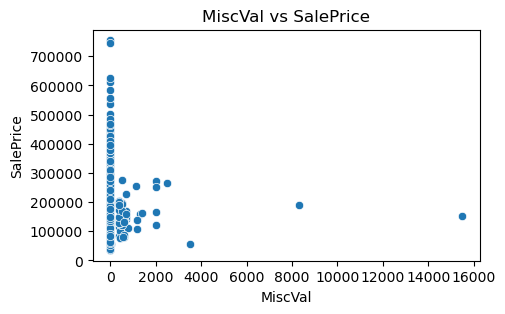

In [55]:
# Bivariate Analysis
# 1.Continuous Numerical vs Target
import seaborn as sns
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df_house[col], y=df_house['SalePrice'])
    plt.title(f"{col} vs SalePrice")
    plt.xlabel(col)
    plt.ylabel("SalePrice")
    plt.show()

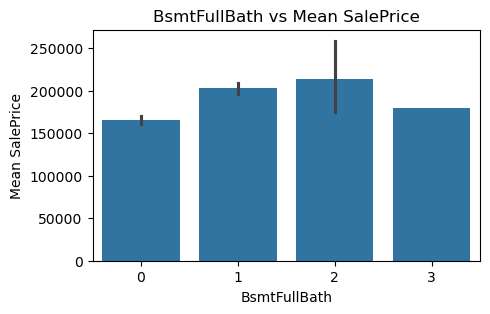

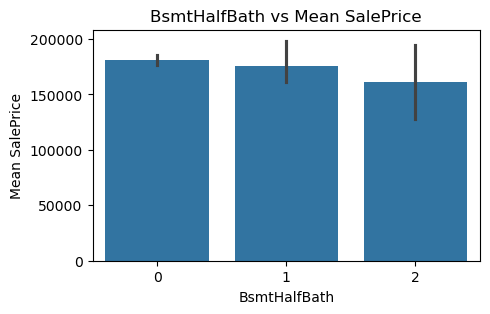

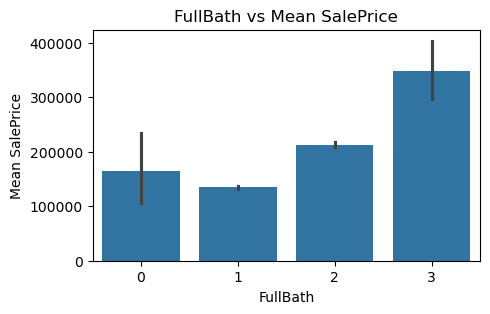

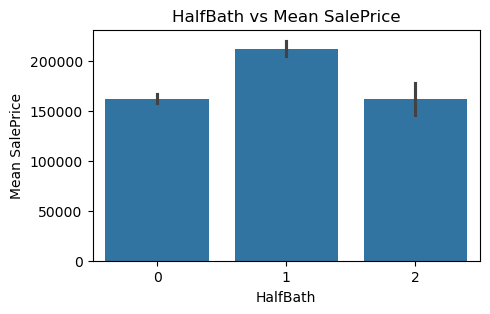

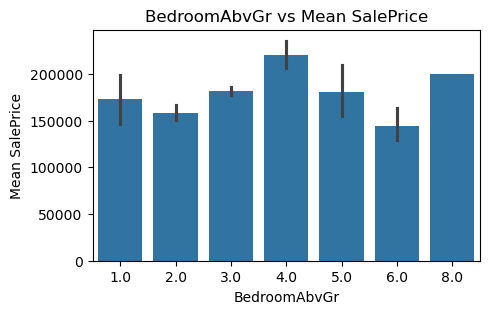

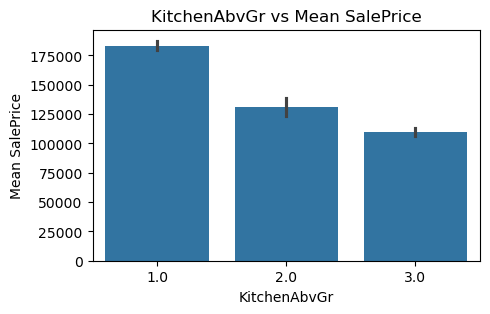

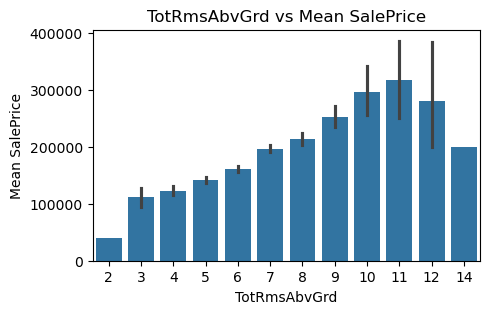

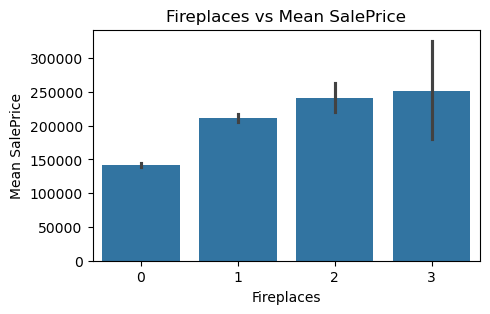

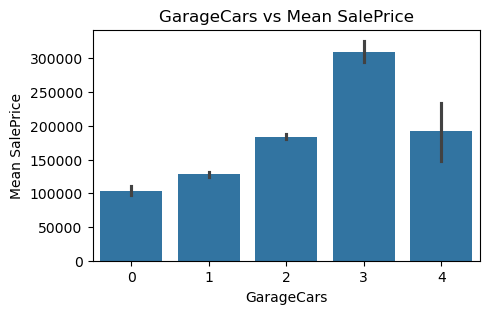

In [56]:
# ️Discrete Numerical vs Target
for col in discrete_cols:
    plt.figure(figsize=(5,3))
    sns.barplot(
        x=df_house[col],
        y=df_house['SalePrice'],
        estimator='mean'
    )
    plt.title(f"{col} vs Mean SalePrice")
    plt.xlabel(col)
    plt.ylabel("Mean SalePrice")
    plt.show()



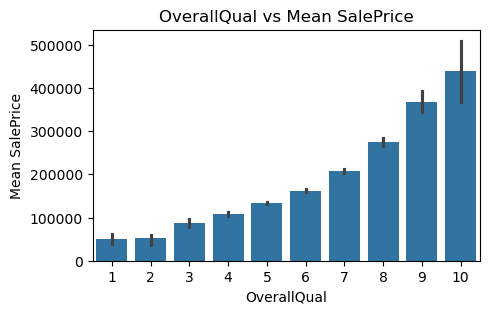

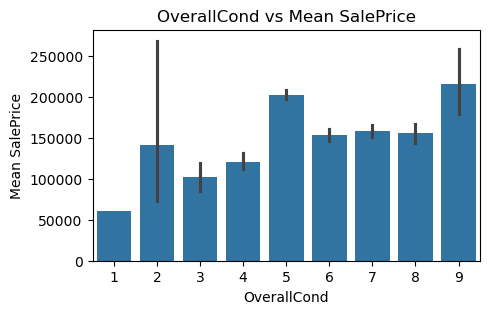

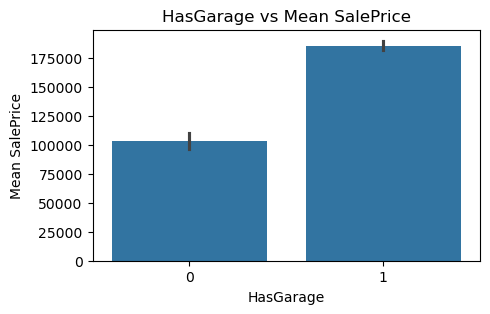

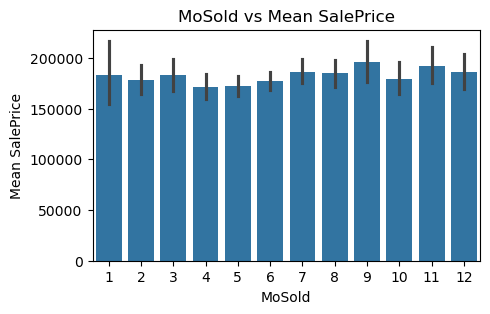

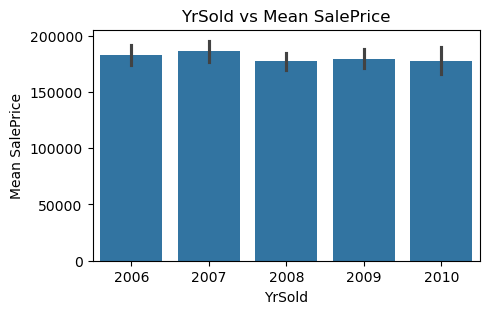

In [57]:
# Numeric but Categorical vs Target
for col in numeric_categorical_cols:
    plt.figure(figsize=(5,3))
    sns.barplot(x=df_house[col], y=df_house['SalePrice'], estimator='mean')
    plt.title(f"{col} vs Mean SalePrice")
    plt.xlabel(col)
    plt.ylabel("Mean SalePrice")
    plt.show()


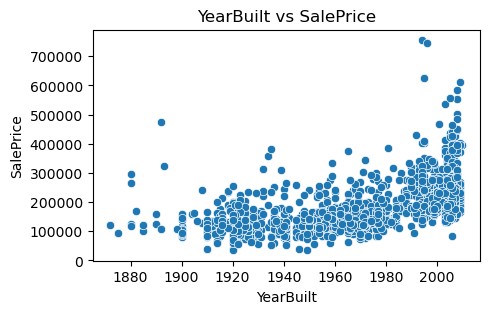

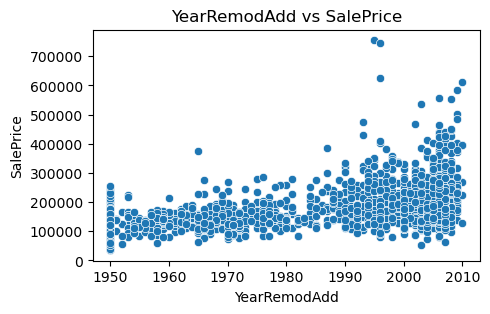

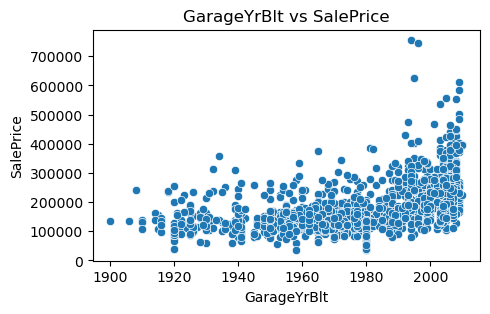

In [58]:
# 4.Year Features vs Target
for col in year_cols:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df_house[col], y=df_house['SalePrice'])
    plt.title(f"{col} vs SalePrice")
    plt.xlabel(col)
    plt.ylabel("SalePrice")
    plt.show()


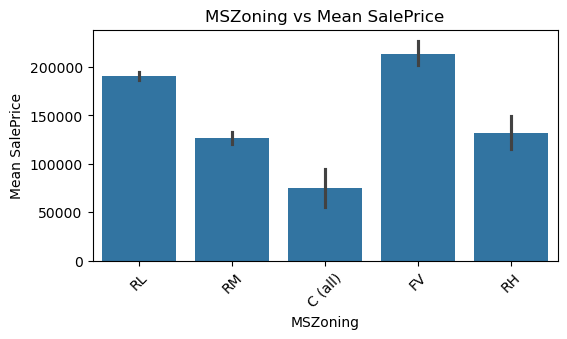

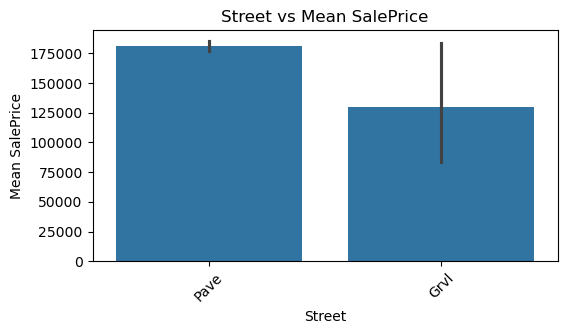

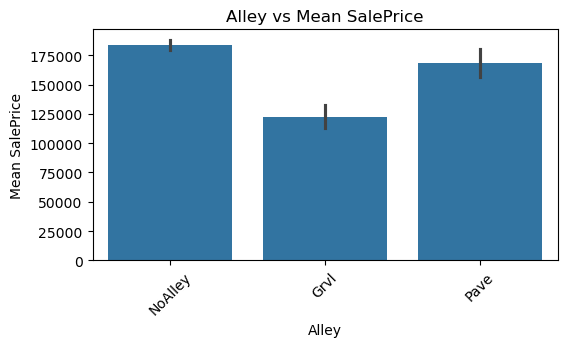

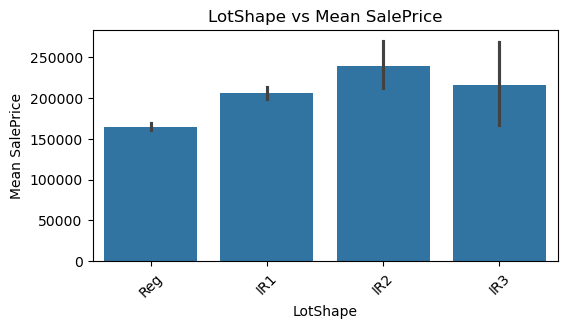

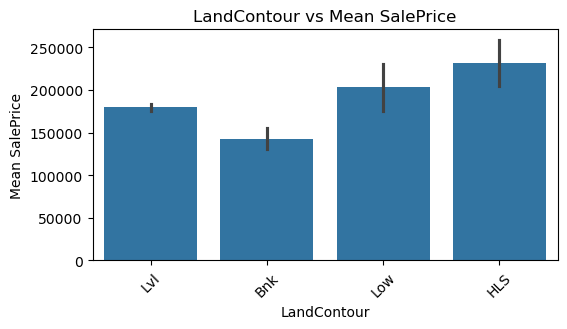

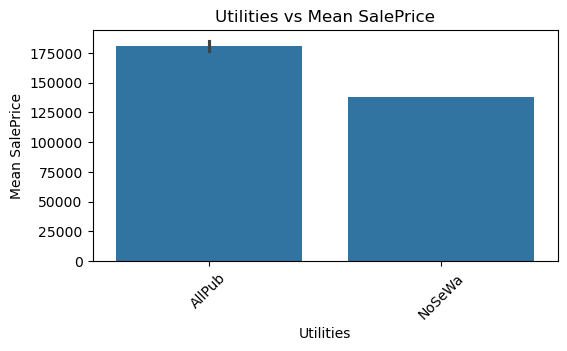

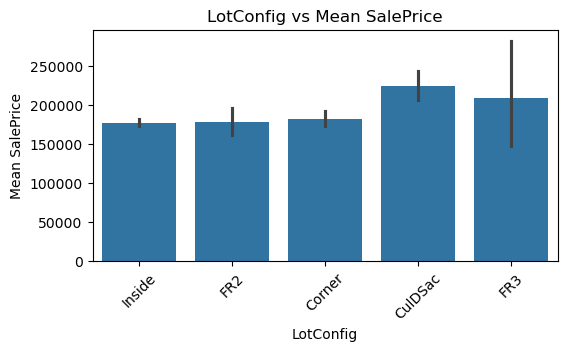

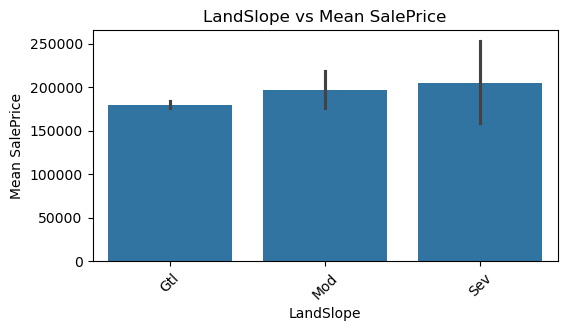

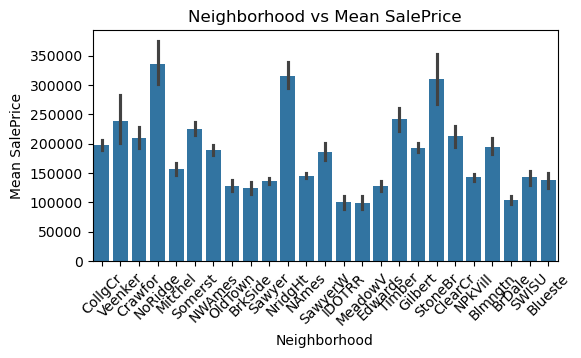

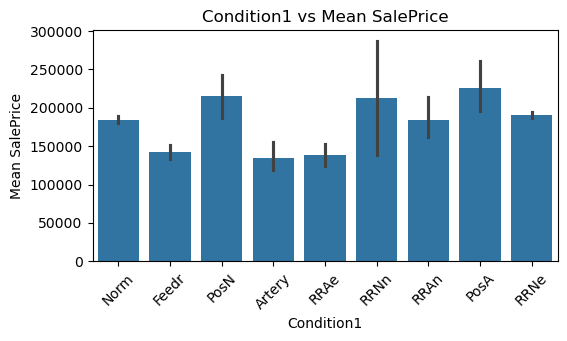

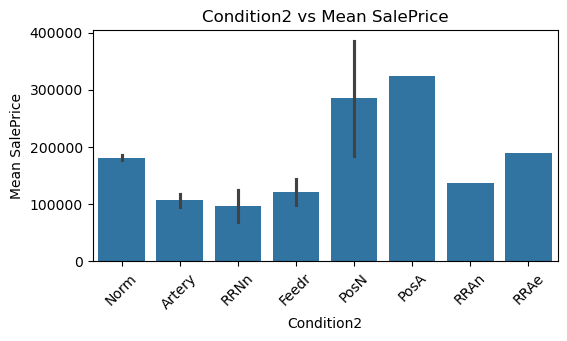

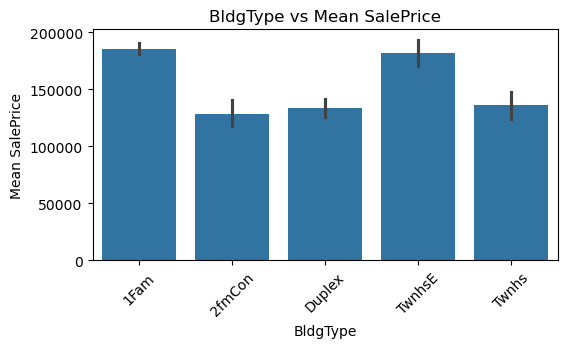

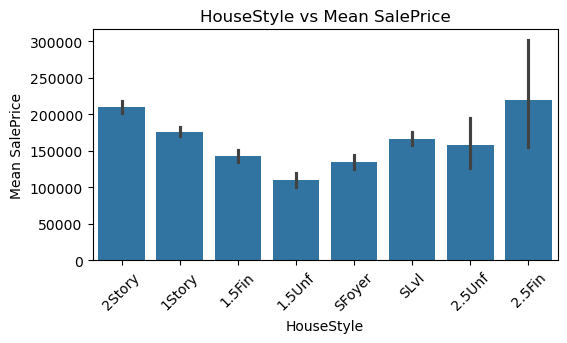

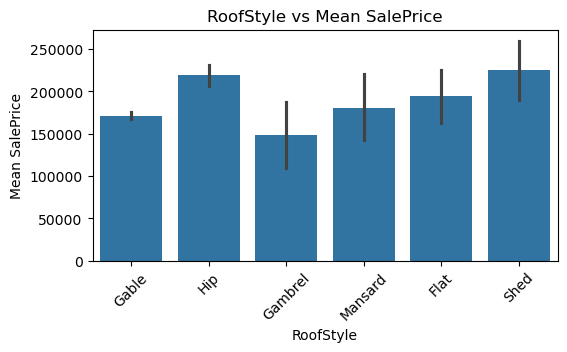

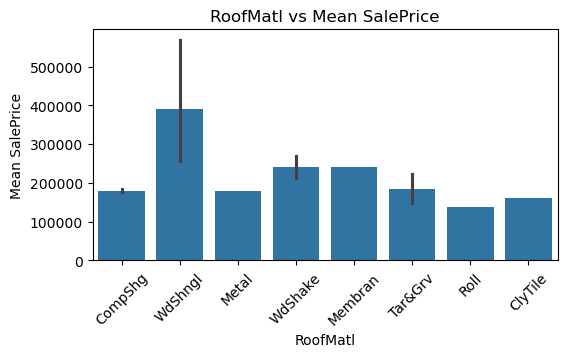

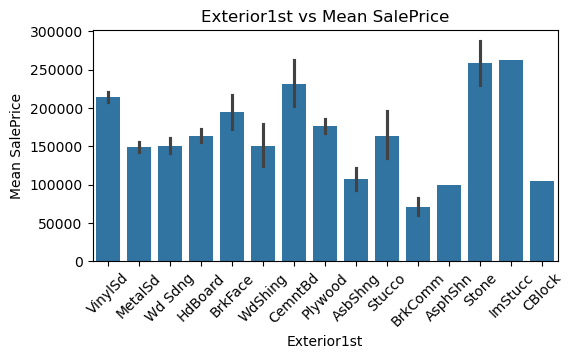

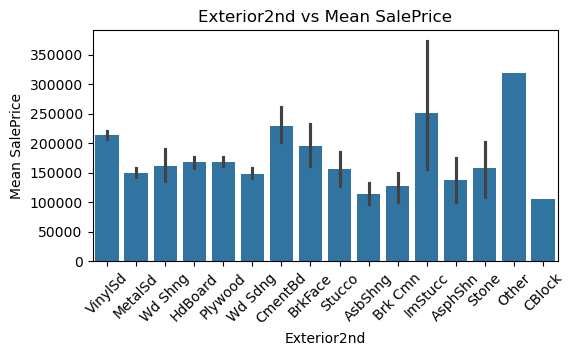

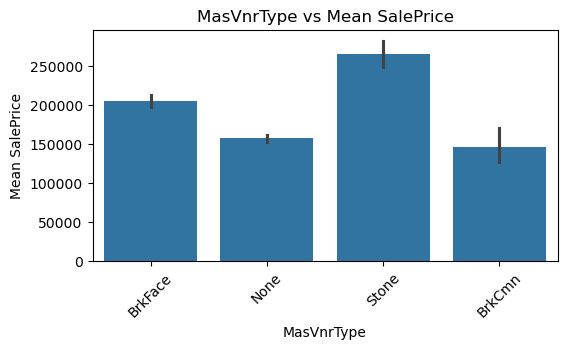

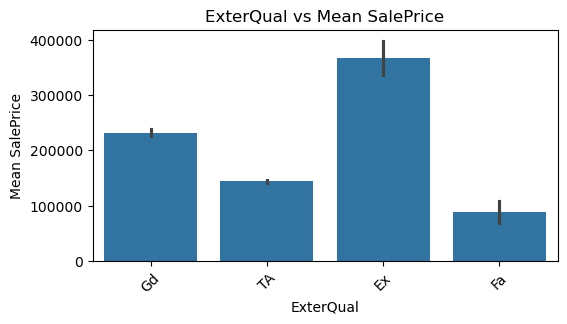

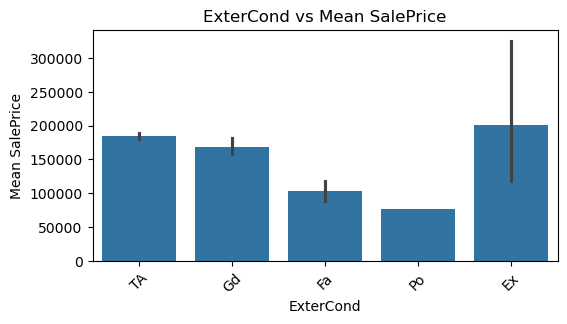

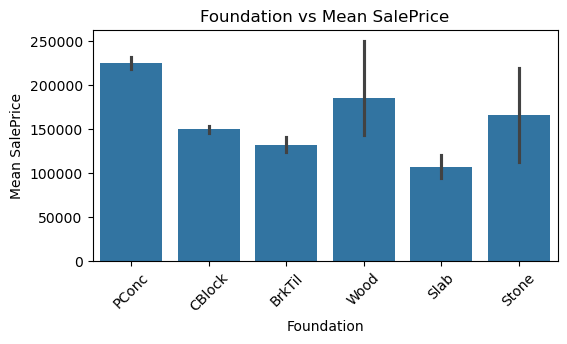

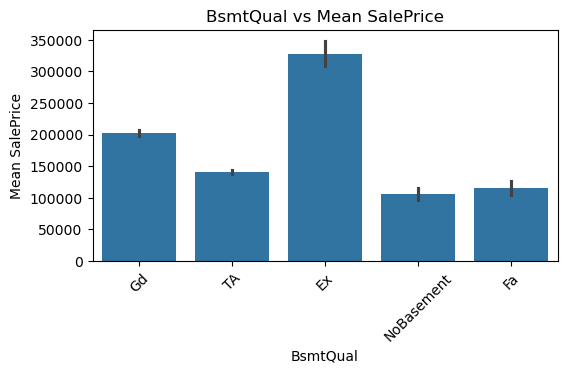

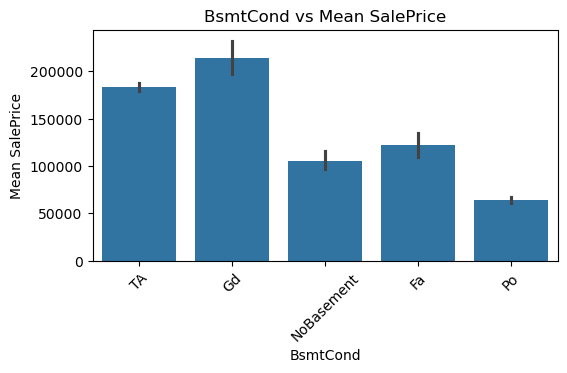

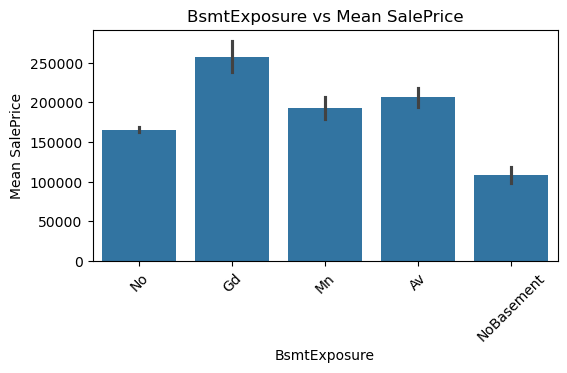

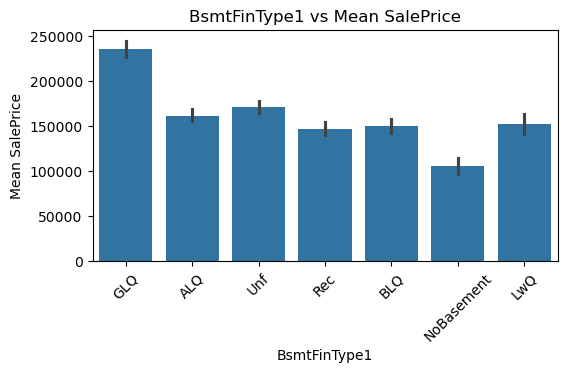

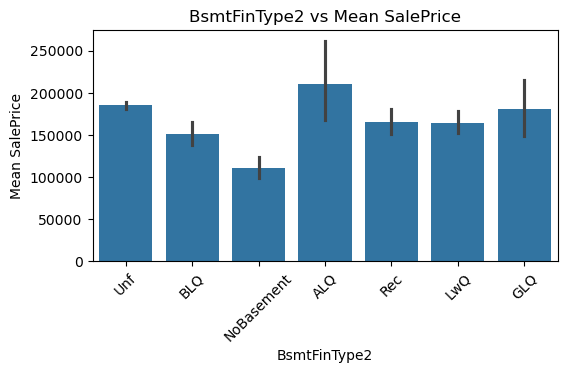

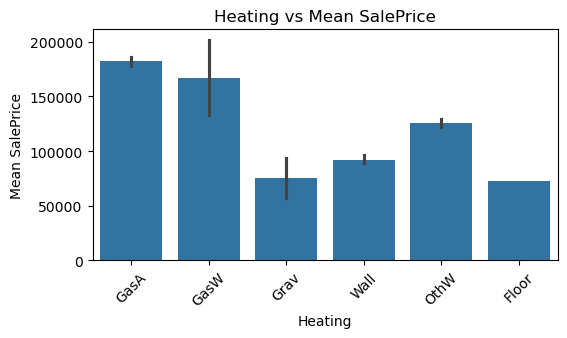

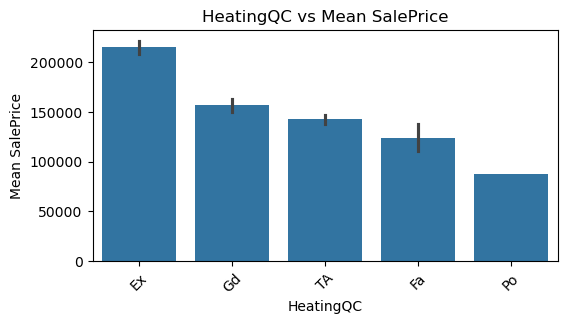

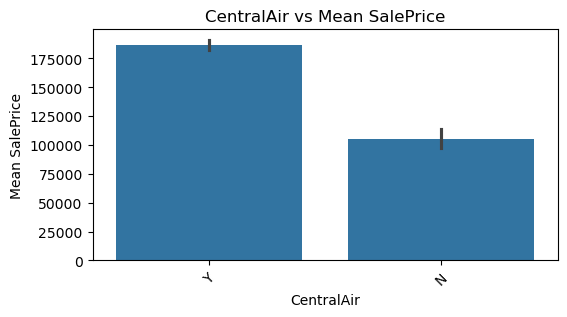

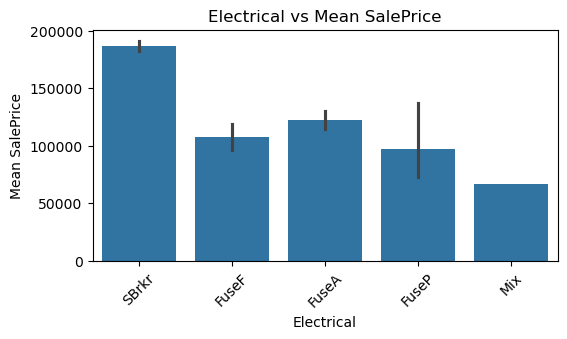

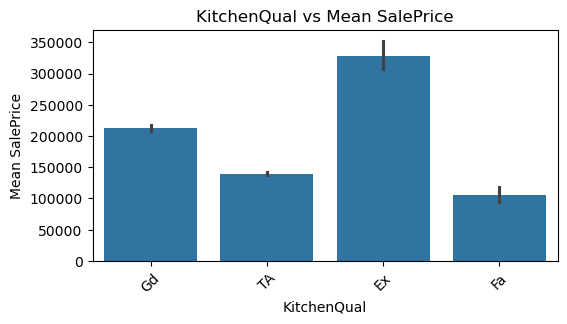

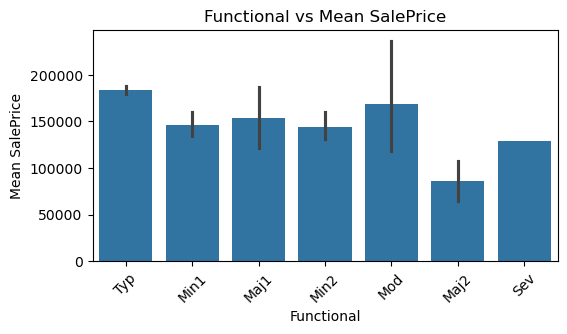

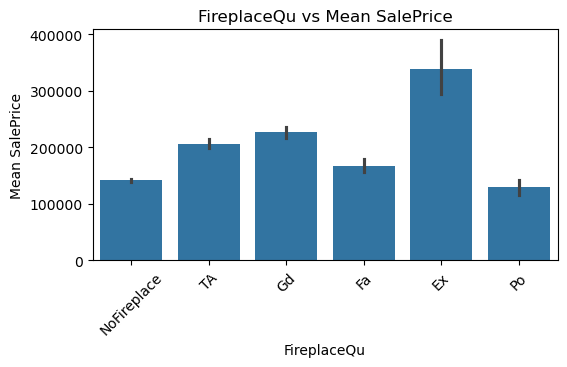

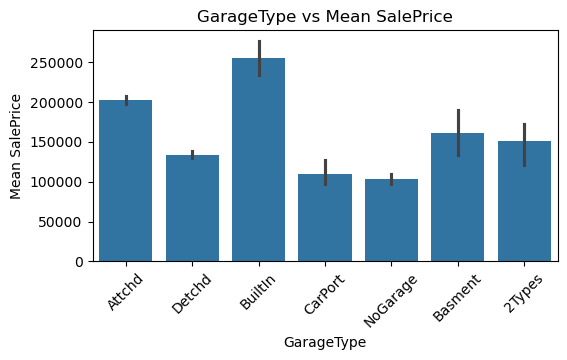

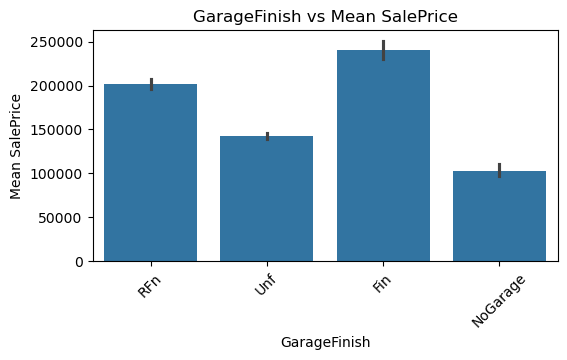

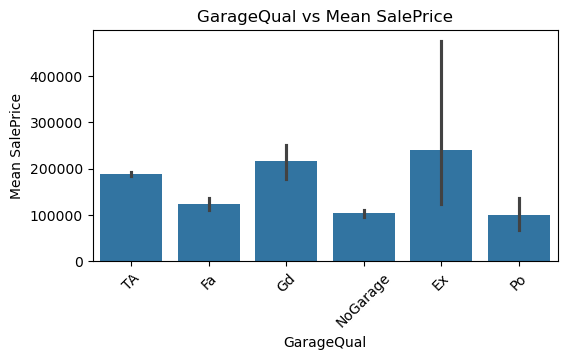

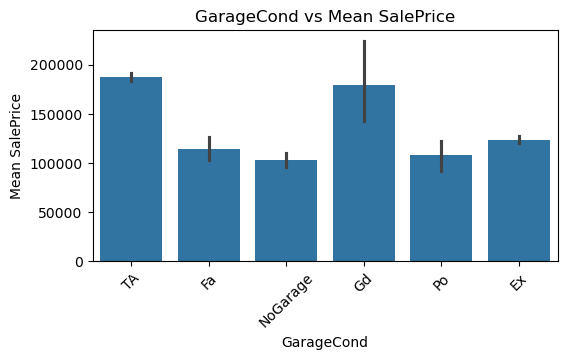

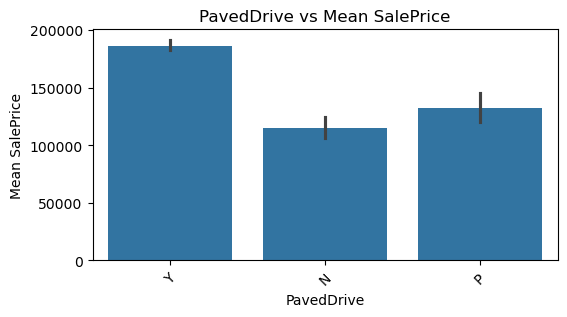

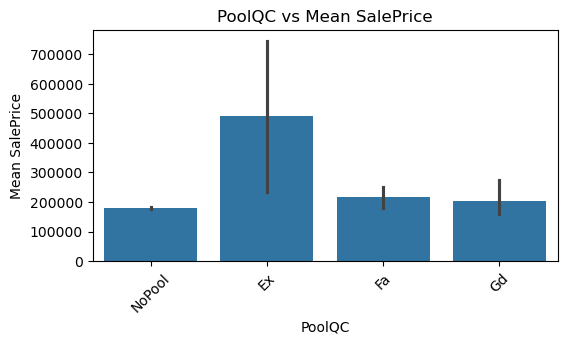

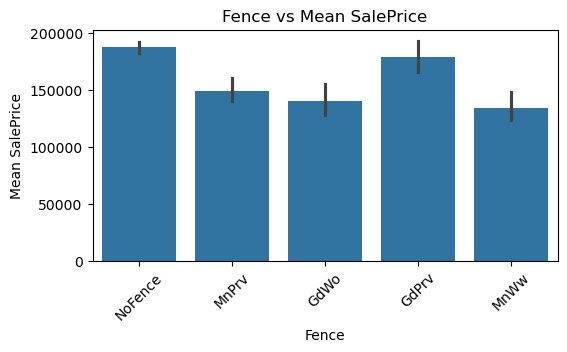

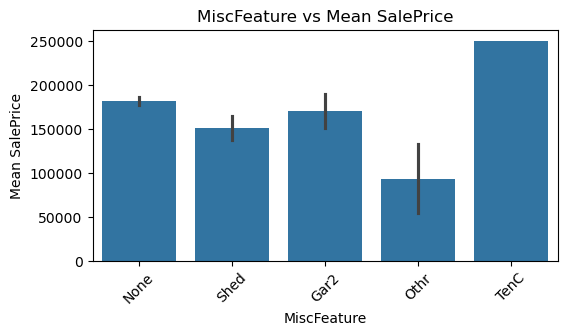

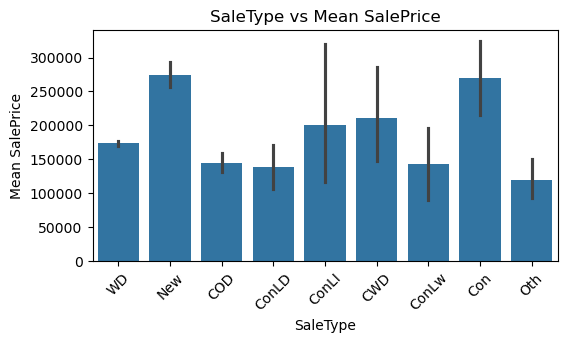

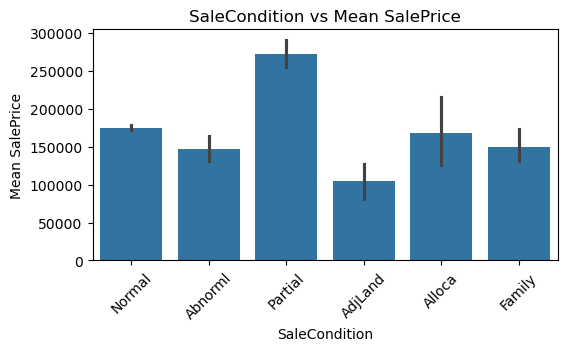

In [59]:
# for ALL your categorical features
import seaborn as sns
import matplotlib.pyplot as plt

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.barplot(
        x=df_house[col],
        y=df_house['SalePrice'],
        estimator='mean'
    )
    plt.title(f"{col} vs Mean SalePrice")
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel("Mean SalePrice")
    plt.show()


In [60]:
num_cols

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'HasGarage'],
      dtype='object')

In [61]:
# Redundancy check of Numerical Features
corr = df_house[num_cols].corr()
corr

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,HasGarage
LotFrontage,1.000000,0.304522,0.234812,-0.053281,0.116685,0.083348,0.178469,0.214367,0.042463,0.124098,0.363472,0.413773,0.072388,0.037469,0.368007,0.090343,-0.006979,0.180534,0.047222,0.237448,-0.009905,0.320518,0.233221,0.062996,0.269539,0.323511,0.075542,0.137014,0.010287,0.061945,0.037655,0.180819,-0.000255,0.010451,0.006380,0.095926
LotArea,0.304522,1.000000,0.105806,-0.005636,0.014228,0.013788,0.103321,0.214103,0.111170,-0.002618,0.260833,0.299475,0.050986,0.004779,0.263116,0.158155,0.048046,0.126031,0.014259,0.134732,-0.018274,0.190015,0.271364,-0.025865,0.154871,0.180403,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.074015
OverallQual,0.234812,0.105806,1.000000,-0.091932,0.572323,0.550684,0.407252,0.239666,-0.059119,0.308159,0.537808,0.476224,0.295493,-0.030429,0.593007,0.111098,-0.040150,0.550600,0.273458,0.106993,-0.185544,0.427452,0.396765,0.514231,0.600671,0.562022,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.261968
OverallCond,-0.053281,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.125694,-0.046231,0.040229,-0.136841,-0.171098,-0.144203,0.028942,0.025494,-0.079686,-0.054942,0.117821,-0.194149,-0.060769,0.014597,-0.089301,-0.057583,-0.023820,-0.306276,-0.185758,-0.151521,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,0.009690
YearBuilt,0.116685,0.014228,0.572323,-0.375983,1.000000,0.592855,0.311600,0.249503,-0.049107,0.149040,0.391452,0.281986,0.010308,-0.183784,0.199010,0.187599,-0.038162,0.468271,0.242656,-0.068461,-0.175778,0.095589,0.147716,0.777182,0.537850,0.478954,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.231072
YearRemodAdd,0.083348,0.013788,0.550684,0.073741,0.592855,1.000000,0.176529,0.128451,-0.067759,0.181133,0.291066,0.240379,0.140024,-0.062419,0.287389,0.119470,-0.012337,0.439046,0.183331,-0.040551,-0.152264,0.191740,0.112581,0.616444,0.420622,0.371600,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.113826
MasVnrArea,0.178469,0.103321,0.407252,-0.125694,0.311600,0.176529,1.000000,0.261256,-0.071330,0.113862,0.360067,0.339850,0.173800,-0.068628,0.388052,0.083010,0.027403,0.272999,0.199108,0.096637,-0.036203,0.279568,0.247015,0.244444,0.361945,0.370884,0.159991,0.122528,-0.109907,0.019144,0.062248,0.011928,-0.029512,-0.006723,-0.008317,0.119845
BsmtFinSF1,0.214367,0.214103,0.239666,-0.046231,0.249503,0.128451,0.261256,1.000000,-0.050117,-0.495251,0.522396,0.445863,-0.137079,-0.064503,0.208171,0.649212,0.067418,0.058543,0.004262,-0.084889,-0.078194,0.044316,0.260011,0.148782,0.224054,0.296970,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.108043
BsmtFinSF2,0.042463,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.071330,-0.050117,1.000000,-0.209294,0.104810,0.097117,-0.099260,0.014807,-0.009640,0.158678,0.070948,-0.076444,-0.032148,-0.020624,-0.041974,-0.035227,0.046921,-0.087684,-0.038264,-0.018227,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,0.039733
BsmtUnfSF,0.124098,-0.002618,0.308159,-0.136841,0.149040,0.181133,0.113862,-0.495251,-0.209294,1.000000,0.415360,0.317987,0.004469,0.028167,0.240257,-0.422900,-0.095804,0.288886,-0.041118,0.154322,0.026296,0.250647,0.051575,0.185610,0.214175,0.183303,-0.005316,0.129005,-0.002538,0.020764,-0.012579,-0.035092,-0.023837,0.034888,-0.041258,0.032924


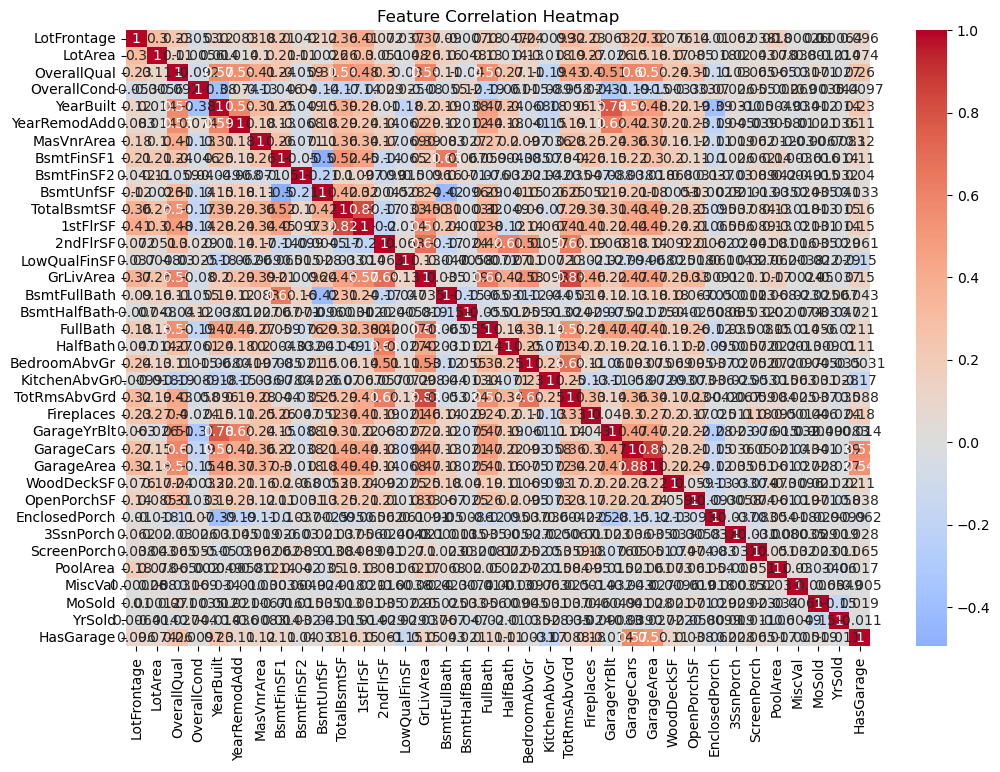

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0,annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()


In [63]:
corr_matrix = df_house[num_cols].corr()

In [64]:
corr_abs = corr_matrix.abs()

In [65]:
import numpy as np

upper_triangle = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)


In [66]:
high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] >= 0.8]


In [67]:
high_corr_pairs.sort_values(by='Correlation', ascending=False)

,Feature_1,Feature_2,Correlation
564,GarageCars,GarageArea,0.882475
405,GrLivArea,TotRmsAbvGrd,0.825489
305,TotalBsmtSF,1stFlrSF,0.819530


GarageCars and GarageArea are strongly related → both describe garage size

GrLivArea and TotRmsAbvGrd describe house size

TotalBsmtSF and 1stFlrSF describe lower-level area

In [68]:
cat_cols

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [69]:
cat_pairs = [
    ('GarageQual', 'GarageCond'),
    ('ExterQual', 'ExterCond'),
    ('BsmtQual', 'BsmtCond'),
    ('KitchenQual', 'ExterQual')
]

In [70]:
# Redundancy Check – Categorical ↔ Categorical (INPUT ↔ INPUT)
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))

results = []

for col1, col2 in cat_pairs:
    v = cramers_v(df_house[col1], df_house[col2])
    results.append([col1, col2, round(v, 3)])

cramer_results = pd.DataFrame(
    results, columns=['Feature_1', 'Feature_2', 'Cramers_V']
)

cramer_results


,Feature_1,Feature_2,Cramers_V
0,GarageQual,GarageCond,0.705
1,ExterQual,ExterCond,0.189
2,BsmtQual,BsmtCond,0.529
3,KitchenQual,ExterQual,0.547


In [71]:
# Redundancy Check – Numerical ↔ Categorical (INPUT ↔ INPUT)
num_cat_pairs = [
    ('GarageArea', 'GarageType'),
    ('GrLivArea', 'OverallQual'),
    ('TotalBsmtSF', 'BsmtQual'),
    ('GarageCars', 'GarageType')
]

In [72]:
from scipy.stats import f_oneway

anova_results = []

for num_col, cat_col in num_cat_pairs:
    groups = []
    for category in df_house[cat_col].dropna().unique():
        groups.append(
            df_house[df_house[cat_col] == category][num_col].dropna()
        )
    
    f_stat, p_value = f_oneway(*groups)
    anova_results.append([num_col, cat_col, round(p_value, 5)])

anova_df = pd.DataFrame(
    anova_results,
    columns=['Numerical_Feature', 'Categorical_Feature', 'p_value']
)

anova_df


,Numerical_Feature,Categorical_Feature,p_value
0,GarageArea,GarageType,0.0
1,GrLivArea,OverallQual,0.0
2,TotalBsmtSF,BsmtQual,0.0
3,GarageCars,GarageType,0.0


In [73]:
# Multicollinearity Check
corr_matrix = df_house[num_cols].corr()

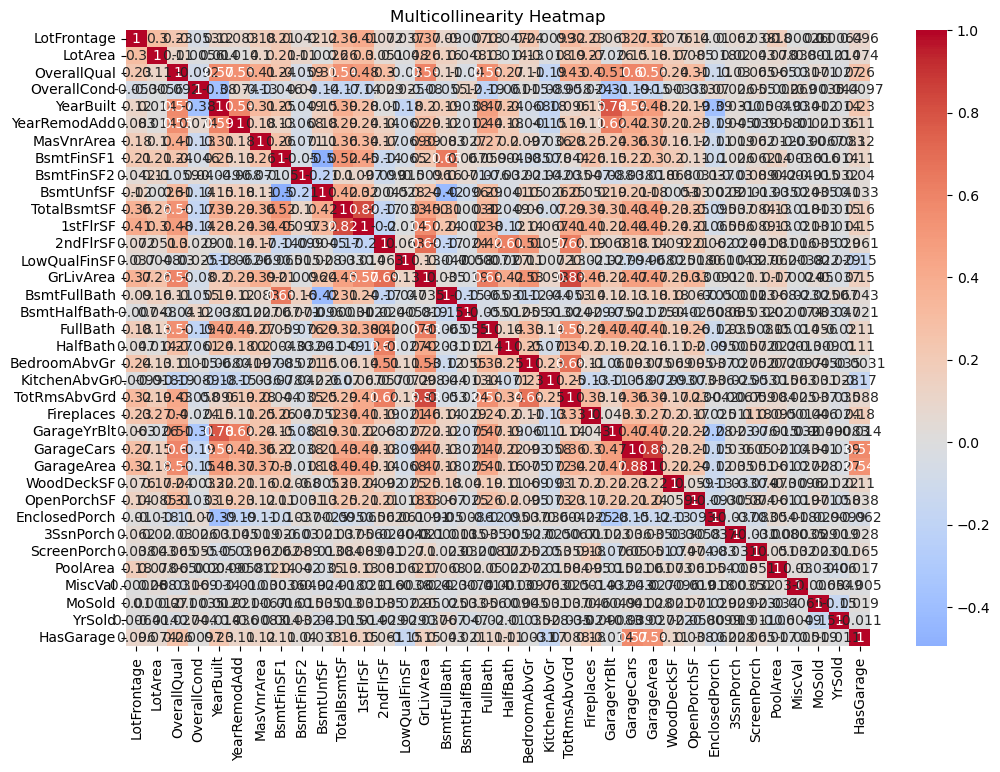

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,annot=True)
plt.title("Multicollinearity Heatmap")
plt.show()


In [75]:
high_corr = corr_matrix[
    (abs(corr_matrix) > 0.85) & (abs(corr_matrix) < 1)
]

high_corr = high_corr.dropna(how='all').dropna(axis=1, how='all')
high_corr


,GarageCars,GarageArea
GarageCars,NaN,0.882475
GarageArea,0.882475,NaN


In [76]:
# Common interaction types in House Price data
# A) Size × Quality

# GrLivArea × OverallQual

# TotalBsmtSF × BsmtQual

# B) Presence × Amount

# HasGarage × GarageArea

# HasGarage × GarageCars

# C) Count × Size

# TotRmsAbvGrd × GrLivArea

# BedroomAbvGr × GrLivArea

# D) Age × Condition

# YearBuilt × OverallCond

# YearRemodAdd × OverallQual

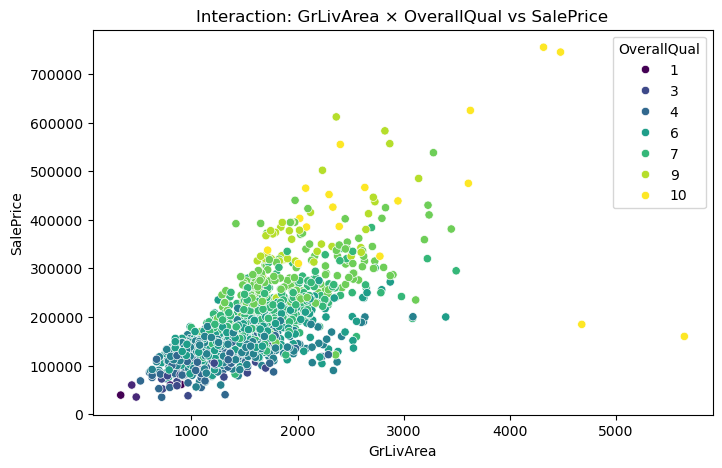

In [77]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df_house['GrLivArea'],
    y=df_house['SalePrice'],
    hue=df_house['OverallQual'],
    palette='viridis',
    # legend=False
)
plt.title("Interaction: GrLivArea × OverallQual vs SalePrice")
plt.show()


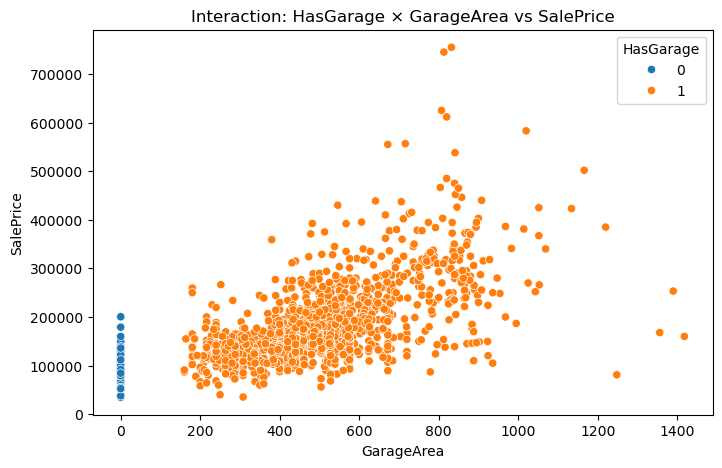

In [78]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df_house['GarageArea'],
    y=df_house['SalePrice'],
    hue=df_house['HasGarage']
)
plt.title("Interaction: HasGarage × GarageArea vs SalePrice")
plt.show()


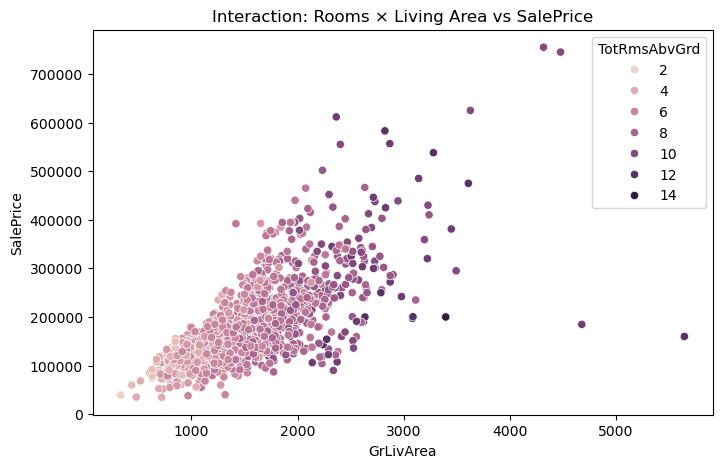

In [79]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df_house['GrLivArea'],
    y=df_house['SalePrice'],
    hue=df_house['TotRmsAbvGrd'],
    # legend=False
)
plt.title("Interaction: Rooms × Living Area vs SalePrice")
plt.show()


---------------------------------------------------------------------------------------------------------------------------------

# STEP 6 — OUTLIER DETECTION & HANDLING

In [80]:
continuous_cols

['LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal']

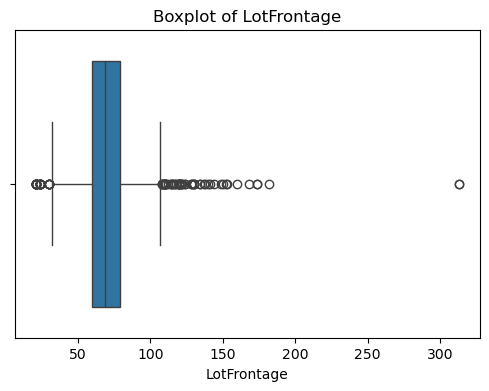

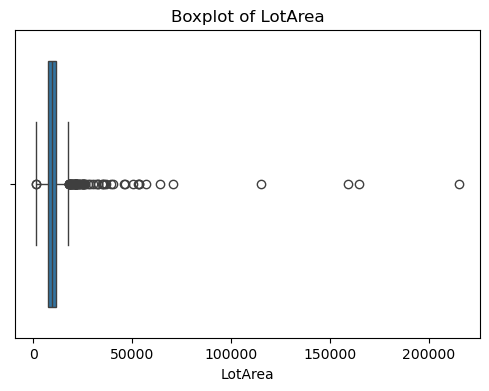

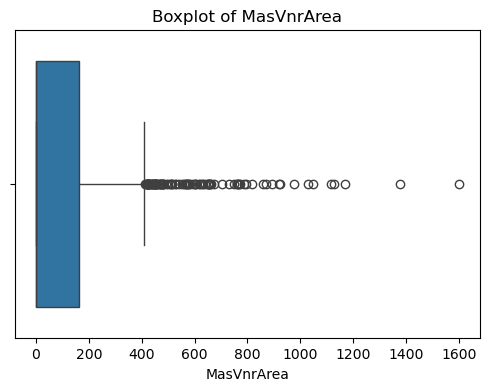

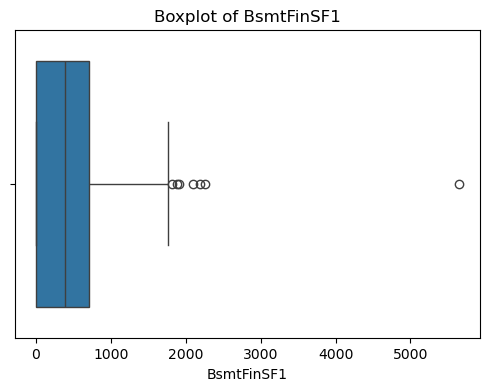

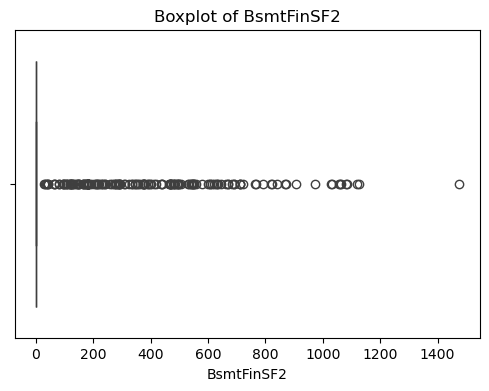

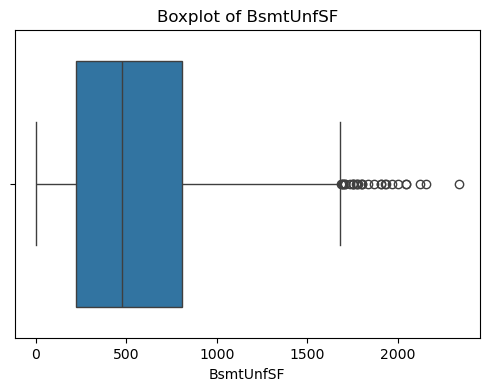

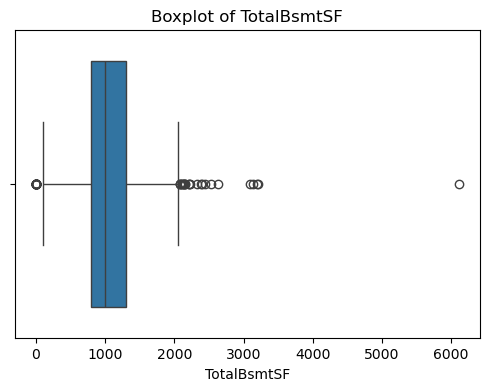

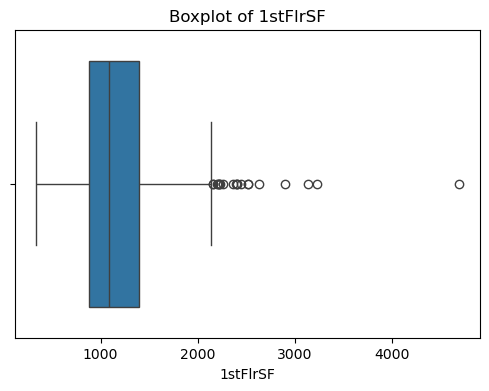

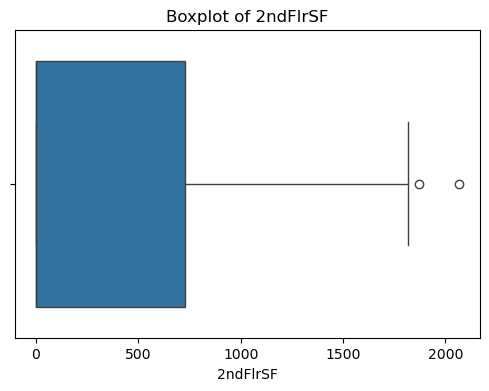

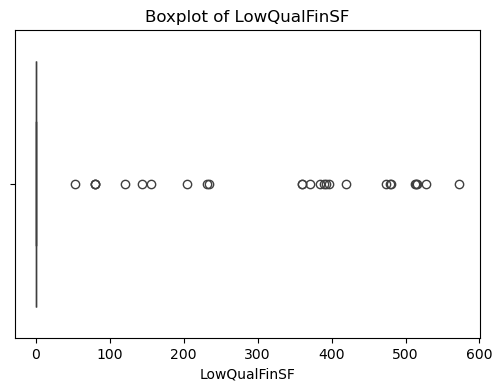

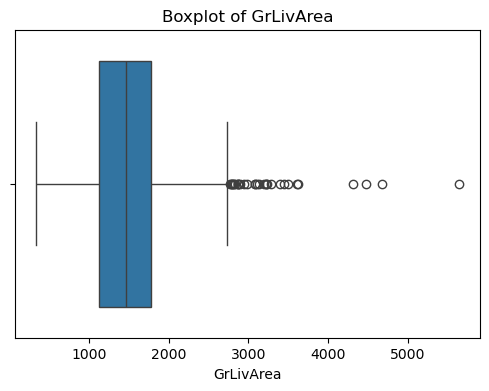

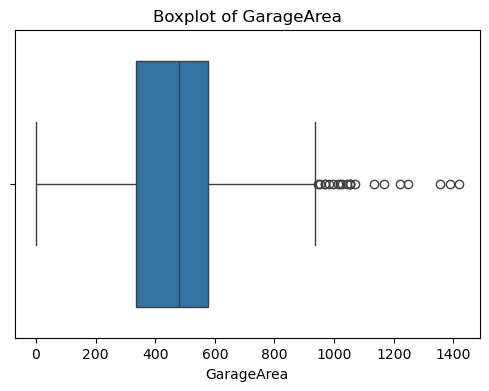

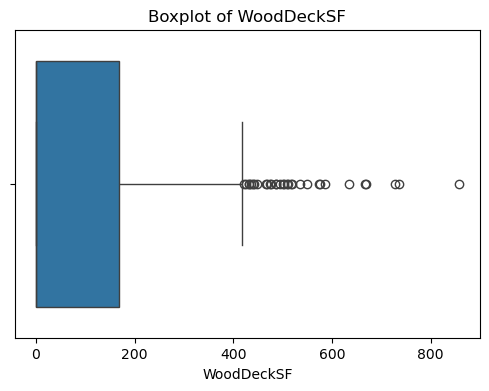

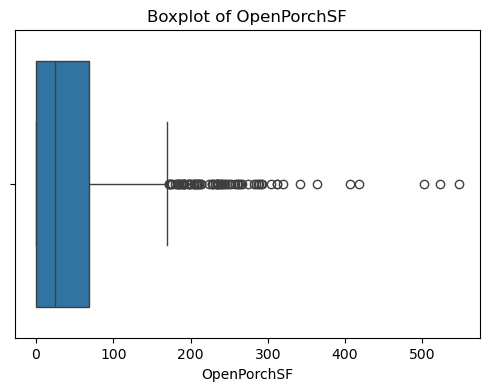

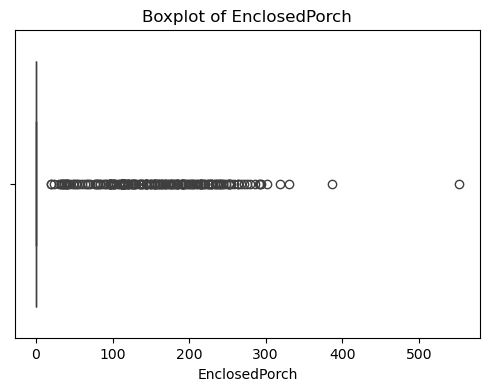

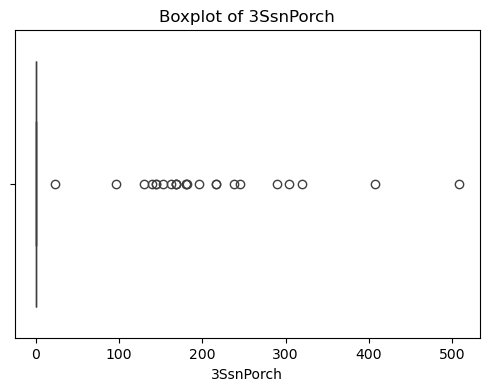

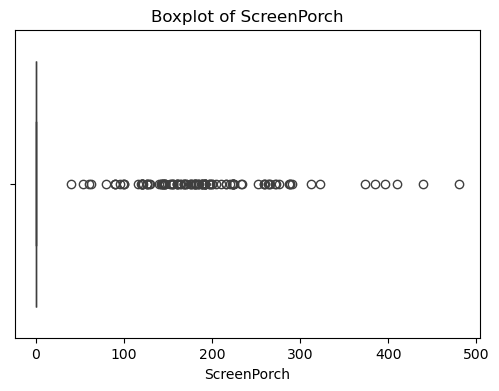

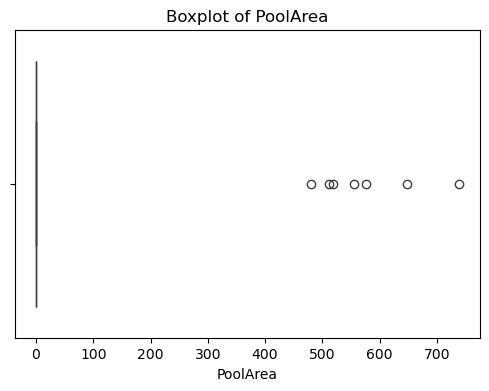

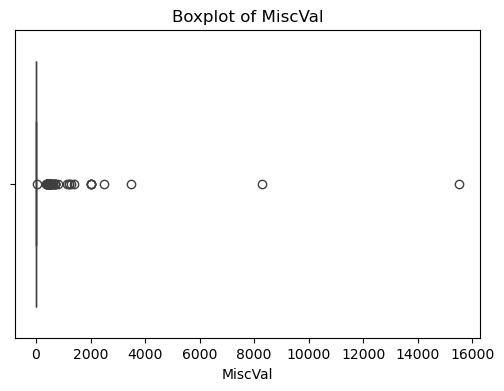

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_house[col])
    plt.title(f"Boxplot of {col}")
    plt.show()



In [82]:
def find_outliers_IQR(data, col):
    Q1 = df_house[col].quantile(0.25)
    Q3 = df_house[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_house[(df_house[col] < lower) | (df_house[col] > upper)][col]
    return outliers


for col in continuous_cols:
    outliers = find_outliers_IQR(df_house, col)

    print(f"\n===== {col} =====")
    print("Total Outliers:", len(outliers))

    if len(outliers) > 0:
        print("Min Outlier:", outliers.min())
        print("Max Outlier:", outliers.max())
        print("Outlier Values:\n", outliers.values)   # shows all values
    else:
        print("No Outliers Found")



===== LotFrontage =====
Total Outliers: 106
Min Outlier: 21.0
Max Outlier: 313.0
Outlier Values:
 [110. 108. 112. 115. 110.  24.  21. 121. 122.  24. 120. 134. 110. 141.
  24.  24. 174.  21.  21. 174.  21.  21. 120.  30. 129. 140. 120. 118.
 116. 150. 111.  21. 109. 130.  21.  24.  21. 137. 110.  21.  21.  24.
 130.  24.  30.  21.  21.  21. 120. 110.  24.  24.  30. 110. 144. 114.
  24.  30.  21. 128. 116. 149.  30.  21. 313.  24.  24.  24. 122. 130.
 121.  21. 115.  21.  21.  21. 120.  24.  24.  24. 114. 168. 182. 134.
  24. 109. 120. 118. 138. 160.  24. 152.  21. 124.  21. 313. 108. 108.
  24. 153. 120. 129. 124.  30.  21.  21.]

===== LotArea =====
Total Outliers: 69
Min Outlier: 1300
Max Outlier: 215245
Outlier Values:
 [ 50271  19900  21000  21453  19378  31770  22950  25419 159000  19296
  39104  19138  18386 215245 164660  20431  18800  53107  34650  22420
  21750  70761  53227  40094  32668  21872  21780  25095  46589  20896
  18450  21535  26178 115149  21695  53504  21384  286

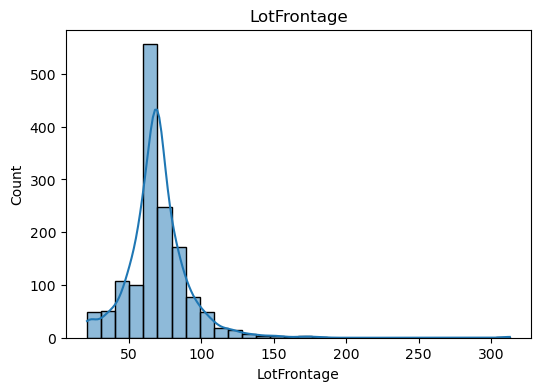

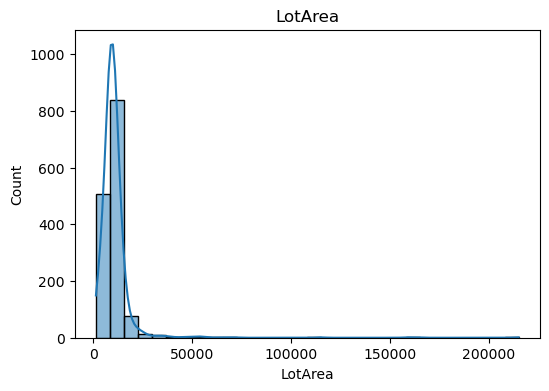

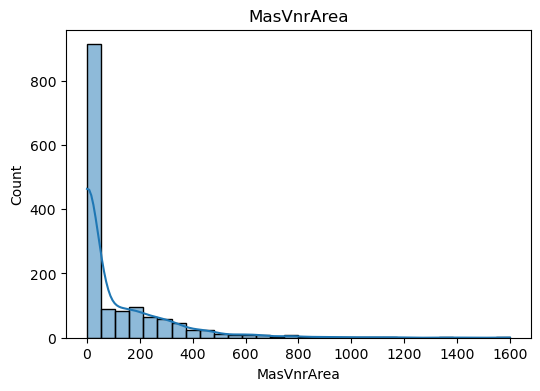

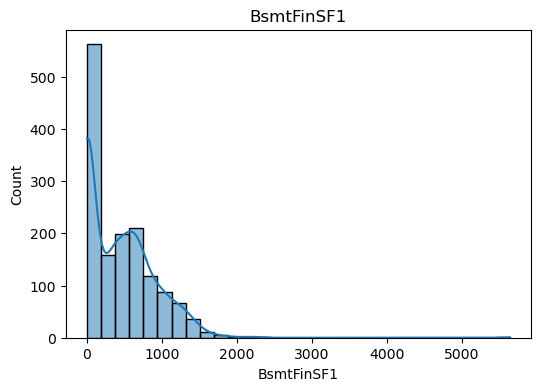

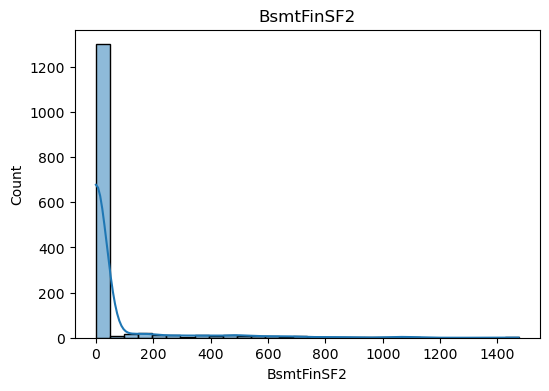

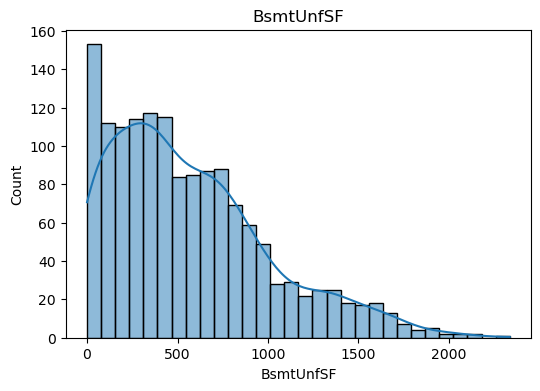

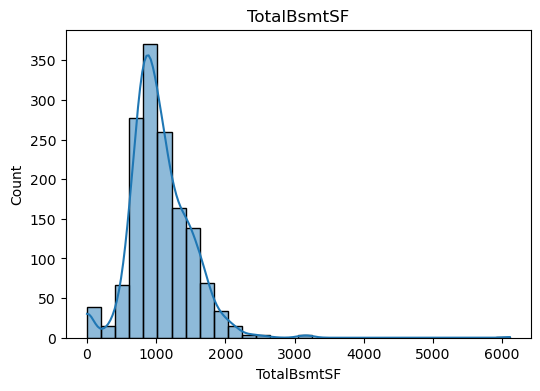

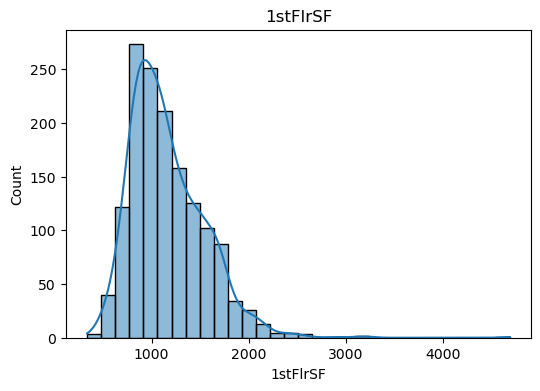

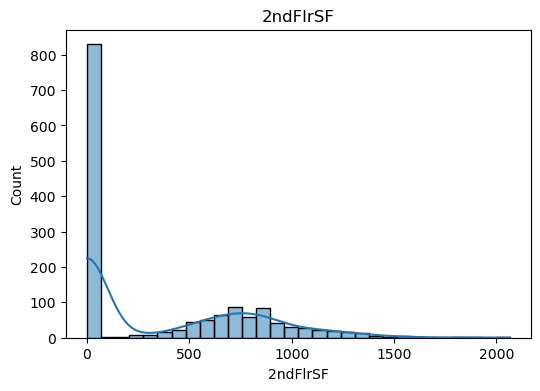

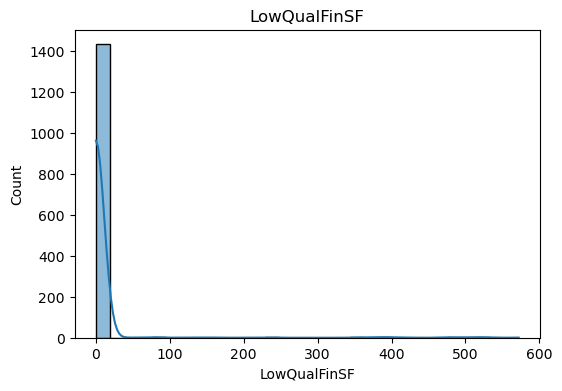

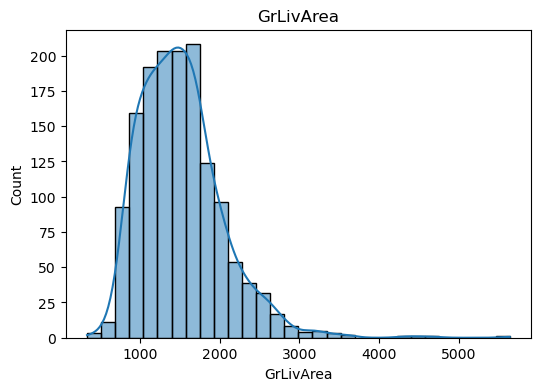

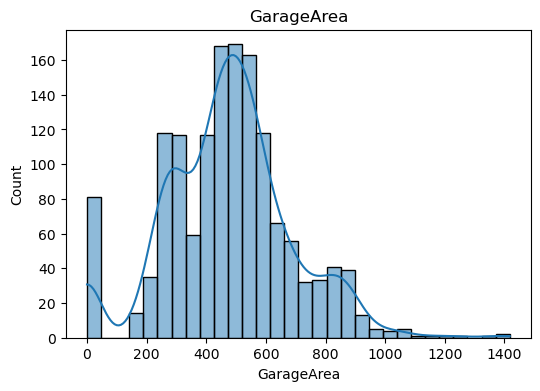

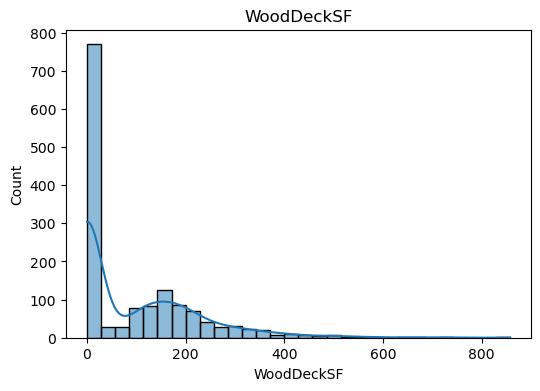

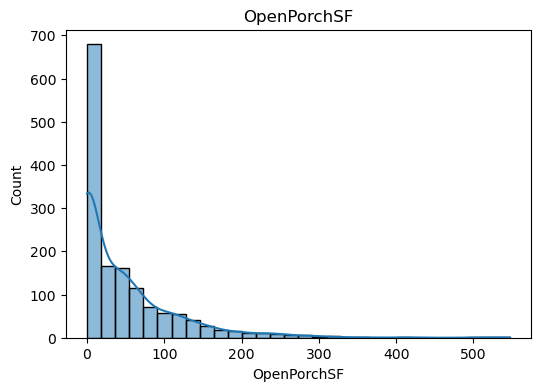

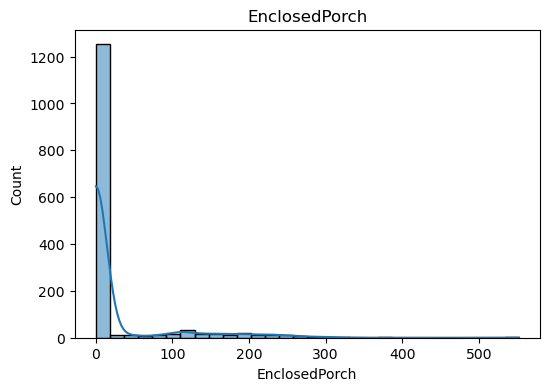

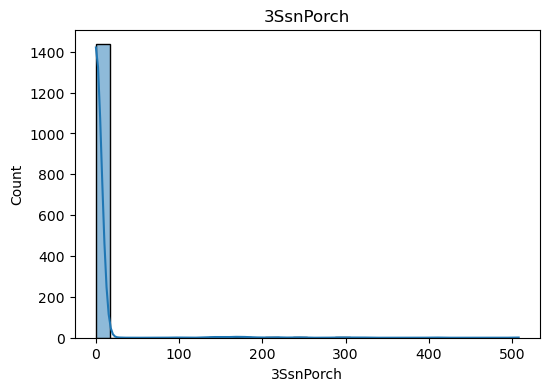

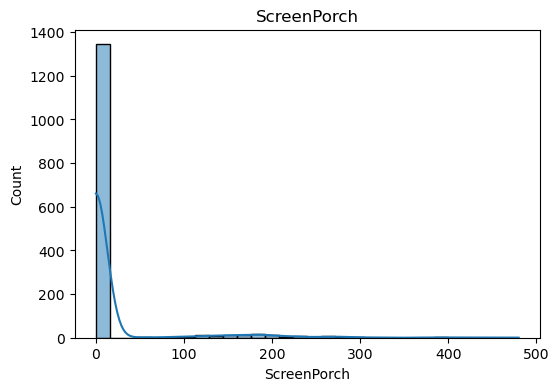

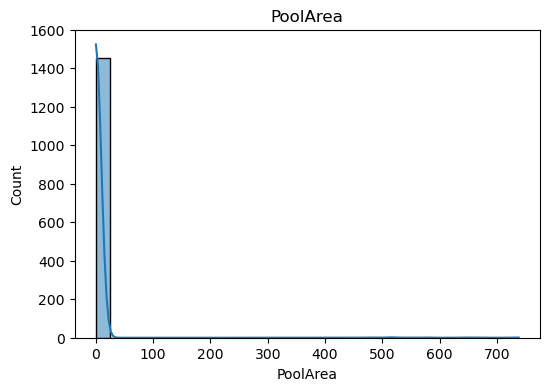

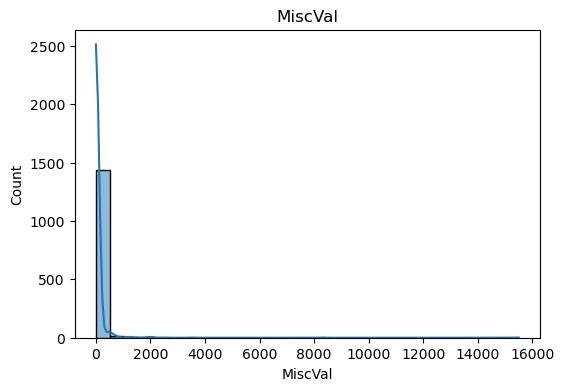

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_house[col], bins=30, kde=True)
    plt.title(col)
    plt.show()


In [84]:
# To handle outliers
skewed_cols = [
    'SalePrice', 'LotArea', 'GrLivArea',
    'TotalBsmtSF', '1stFlrSF',
    'GarageArea', 'MasVnrArea'
]

for col in skewed_cols:
    df_house[col + '_log'] = np.log1p(df_house[col])

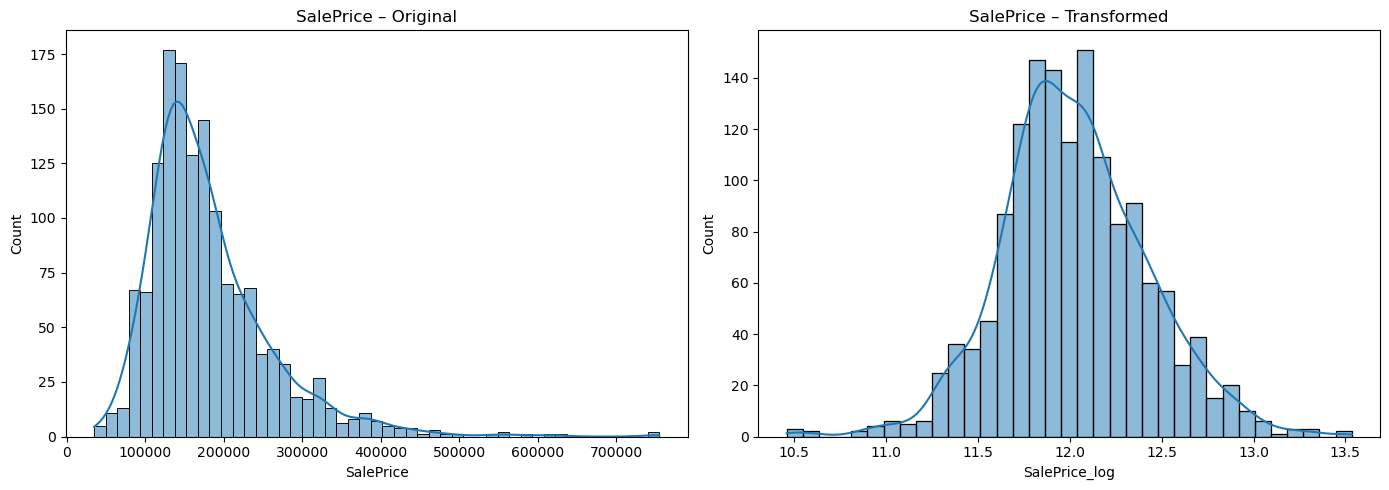

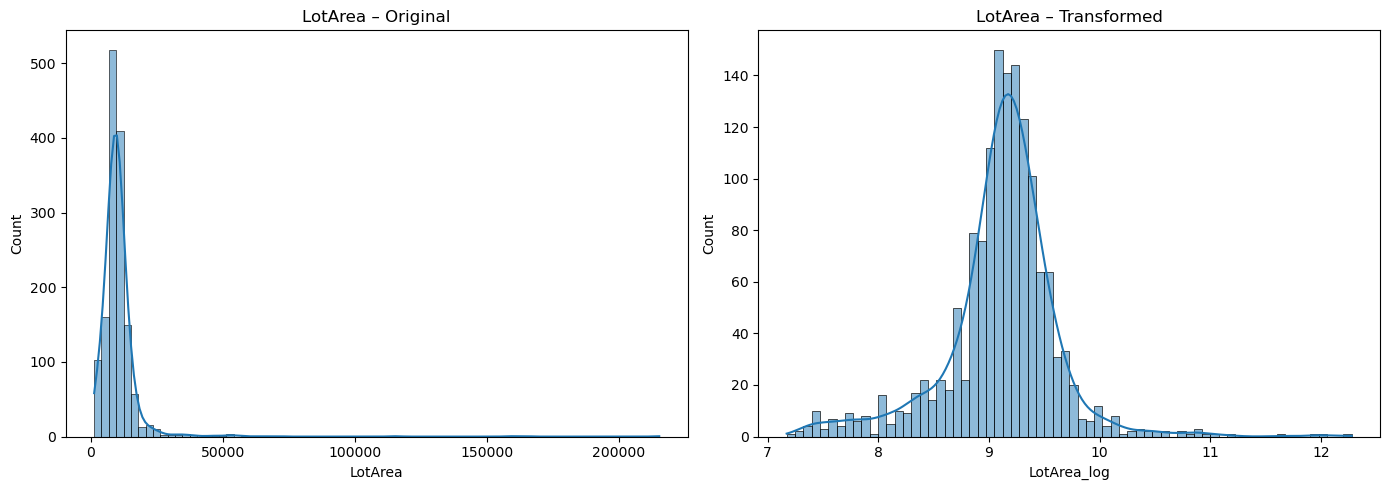

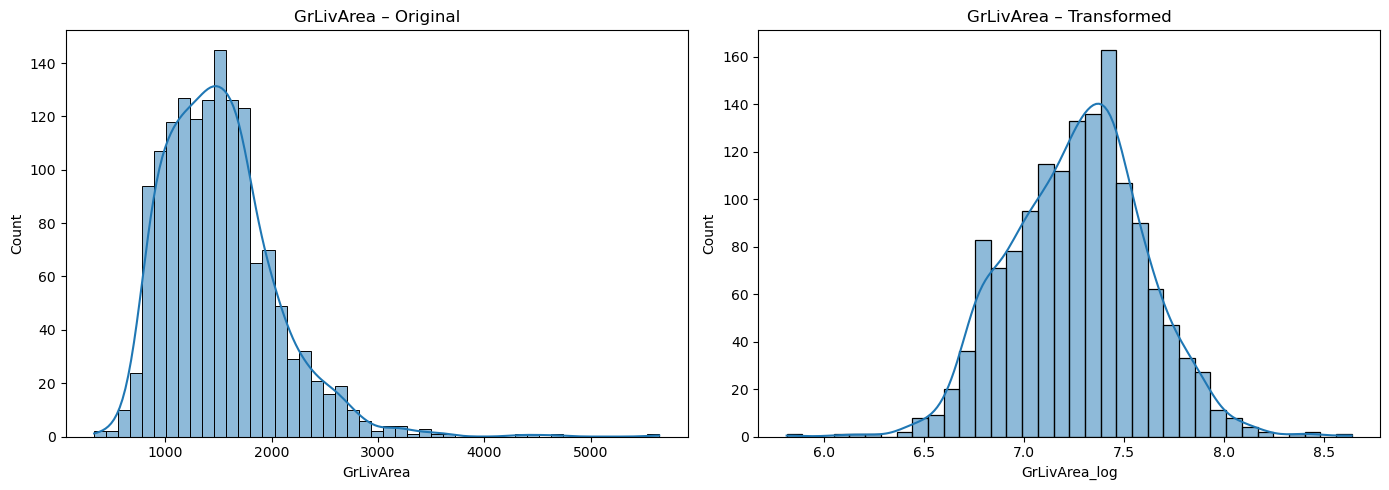

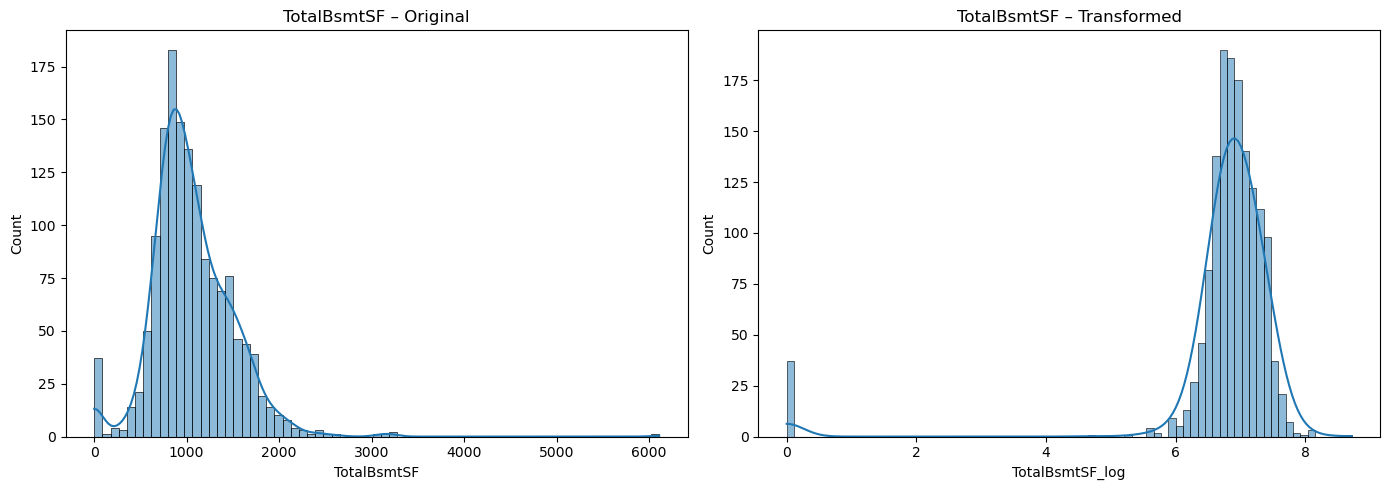

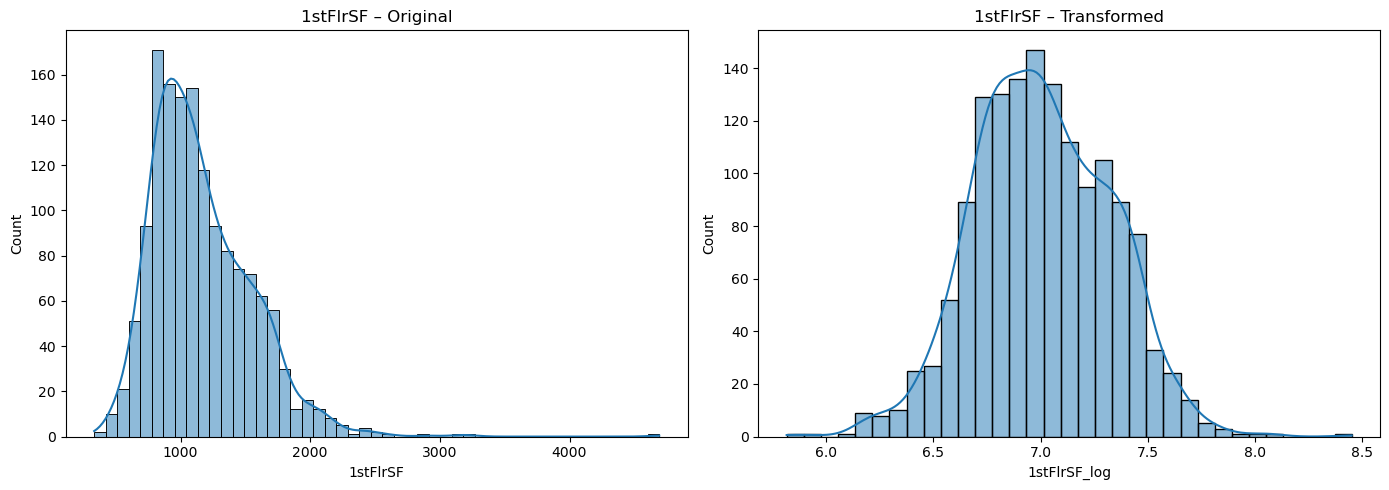

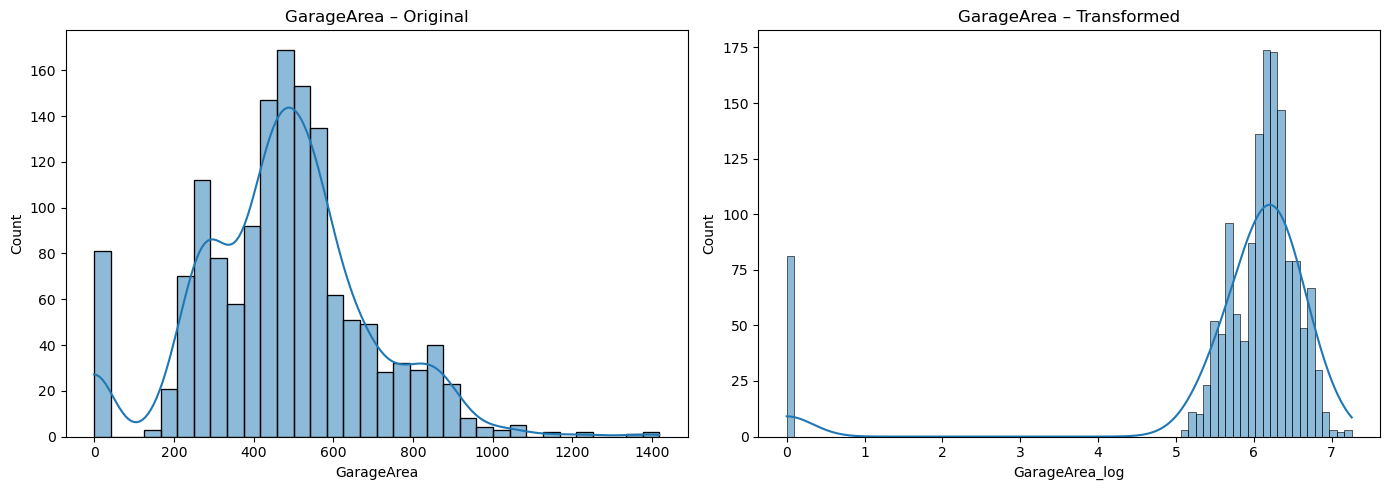

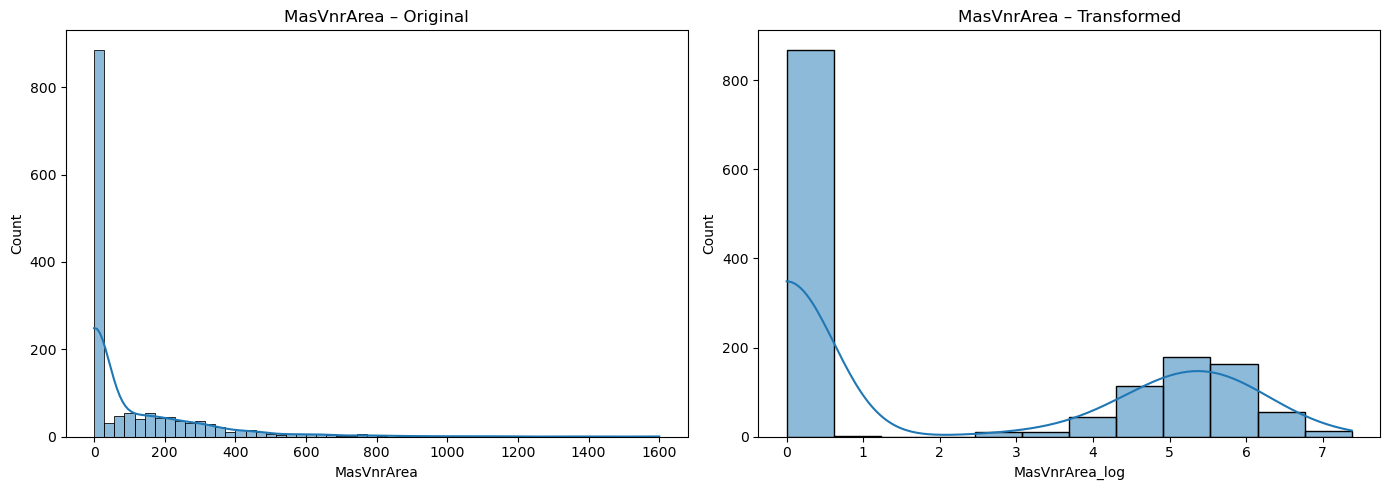

In [85]:
for col in skewed_cols:
    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    sns.histplot(df_house[col].dropna(), kde=True)
    plt.title(f'{col} – Original')

    plt.subplot(1,2,2)
    sns.histplot(df_house[f'{col}_log'].dropna(), kde=True)
    plt.title(f'{col} – Transformed')

    plt.tight_layout()
    plt.show()


In [86]:
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HasGarage,SalePrice_log,LotArea_log,GrLivArea_log,TotalBsmtSF_log,1stFlrSF_log,GarageArea_log,MasVnrArea_log
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3.0,1.0,Gd,8,Typ,0,NoFireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NoPool,NoFence,None,0,2,2008,WD,Normal,208500,1,12.247699,9.042040,7.444833,6.753438,6.753438,6.308098,5.283204
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3.0,1.0,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NoPool,NoFence,None,0,5,2007,WD,Normal,181500,1,12.109016,9.169623,7.141245,7.141245,7.141245,6.133398,0.000000
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3.0,1.0,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NoPool,NoFence,None,0,9,2008,WD,Normal,223500,1,12.317171,9.328212,7.488294,6.825460,6.825460,6.411818,5.093750
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3.0,1.0,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NoPool,NoFence,None,0,2,2006,WD,Abnorml,140000,1,11.849405,9.164401,7.448916,6.629363,6.869014,6.466145,0.000000
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4.0,1.0,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NoPool,NoFence,None,0,12,2008,WD,Normal,250000,1,12.429220,9.565284,7.695758,7.044033,7.044033,6.729824,5.860786


----------------------------------------------------------------------------------------------------------------------------------

# Step 7 — Feature Understanding

In [87]:
# # Feature Understanding
# 1️⃣ Size-related features (VERY EASY)
# Examples:

# LotArea

# GrLivArea

# TotalBsmtSF

# GarageArea

# Logic:

# Bigger space → higher price

# ✔ Direction: Increase
# ✔ Strength: Strong
# ✔ Action: Keep

# No overthinking needed.

# 2️⃣ Quality-related features (MOST IMPORTANT)
# Examples:

# OverallQual

# ExterQual

# KitchenQual

# BsmtQual

# These are human ratings.

# Logic:

# Better quality → higher price

# ✔ Direction: Increase
# ✔ Strength: Very Strong
# ✔ Action: Keep

# These often dominate models.

# 3️⃣ Count features (rooms, baths)
# Examples:

# BedroomAbvGr

# FullBath

# TotRmsAbvGrd

# Logic:

# More rooms → usually higher price

# But diminishing returns exist

# ✔ Direction: Increase (not linear)
# ✔ Strength: Medium
# ✔ Action: Keep

# 4️⃣ Age-related features
# Examples:

# YearBuilt

# YearRemodAdd

# GarageYrBlt

# Logic:

# Newer → more valuable

# Renovation adds value

# ✔ Direction: Newer = higher price
# ✔ Strength: Medium–Strong
# ✔ Action: Keep

# (You already handled skew/outliers well)

# 5️⃣ Location-related features (VERY STRONG)
# Examples:

# Neighborhood

# Condition1

# Condition2

# Logic:

# Location ALWAYS matters in housing

# ✔ Direction: Depends on category
# ✔ Strength: Very Strong
# ✔ Action: Keep

# No need to rank manually — model will learn.

# 6️⃣ Binary features (yes/no)
# Examples:

# HasGarage

# CentralAir

# PavedDrive

# Logic:

# Presence adds value

# ✔ Direction: Yes > No
# ✔ Strength: Medium
# ✔ Action: Keep

# 7️⃣ Weak / contextual features
# Examples:

# MoSold

# YrSold

# Fence

# MiscFeature

# Logic:

# Do NOT drive price directly

# May help slightly

# ✔ Direction: No clear logic
# ✔ Strength: Weak
# ✔ Action: Keep for now

# Model will ignore if useless.

# 8️⃣ Features that look suspicious (COMMON SENSE)
# Examples:

# Id

# Logic:

# Just an identifier

# ❌ Direction: None
# ❌ Strength: None
# ❌ Action: Drop

# You already know this.

# VERY IMPORTANT TRUTH (READ THIS CAREFULLY)

# Feature understanding ≠ feature dropping

# At this stage:

# You understand

# You expect

# You validate later

# You do NOT aggressively remove features here.

# What you should WRITE in your notebook (simple template)

# For each group:

# These features logically affect house price because they represent
# size/quality/location. Direction of impact is positive and they are
# expected to be strong predictors. We keep them for modeling.


# That’s enough. No essays needed.

---------------------------------------------------------------------------------------------------------------------------------

# Step 8: Feature Engineering

In [88]:
# Step 8: Feature Engineering
# 1️⃣ Aggregation Features
df_house['Total_Bathrooms'] = df_house['FullBath'] + 0.5 * df_house['HalfBath']
df_house['Total_SF'] = df_house['GrLivArea'] + df_house['TotalBsmtSF']

In [89]:
# 2️⃣ Ratio / Normalized Features (LIMITED & CONTROLLED)
df_house['Rooms_per_SF'] = df_house['TotRmsAbvGrd'] / df_house['GrLivArea']

In [90]:
# Interaction Feature
df_house['Quality_x_Size'] = df_house['OverallQual'] * df_house['GrLivArea']

In [91]:
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HasGarage,SalePrice_log,LotArea_log,GrLivArea_log,TotalBsmtSF_log,1stFlrSF_log,GarageArea_log,MasVnrArea_log,Total_Bathrooms,Total_SF,Rooms_per_SF,Quality_x_Size
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3.0,1.0,Gd,8,Typ,0,NoFireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NoPool,NoFence,None,0,2,2008,WD,Normal,208500,1,12.247699,9.042040,7.444833,6.753438,6.753438,6.308098,5.283204,2.5,2566,0.004678,11970
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3.0,1.0,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NoPool,NoFence,None,0,5,2007,WD,Normal,181500,1,12.109016,9.169623,7.141245,7.141245,7.141245,6.133398,0.000000,2.0,2524,0.004754,7572
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3.0,1.0,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NoPool,NoFence,None,0,9,2008,WD,Normal,223500,1,12.317171,9.328212,7.488294,6.825460,6.825460,6.411818,5.093750,2.5,2706,0.003359,12502
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3.0,1.0,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NoPool,NoFence,None,0,2,2006,WD,Abnorml,140000,1,11.849405,9.164401,7.448916,6.629363,6.869014,6.466145,0.000000,1.0,2473,0.004077,12019
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4.0,1.0,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NoPool,NoFence,None,0,12,2008,WD,Normal,250000,1,12.429220,9.565284,7.695758,7.044033,7.044033,6.729824,5.860786,2.5,3343,0.004095,17584


---------------------------------------------------------------------------------------------------------------------------------

# 9.Feature Encoding

In [92]:
cat_cols

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [93]:
len(cat_cols)

43

In [94]:
# ORDINAL categorical features
ordinal_cols = [
    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual', 'GarageCond',
    'PoolQC'
]

In [95]:
# NOMINAL categorical features
nominal_cols = [
    'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
    'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
    'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd',
    'MasVnrType', 'Foundation',
    'Heating', 'CentralAir', 'Electrical',
    'Functional', 'GarageType', 'GarageFinish',
    'PavedDrive', 'Fence', 'MiscFeature',
    'SaleType', 'SaleCondition'
]

In [96]:
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HasGarage,SalePrice_log,LotArea_log,GrLivArea_log,TotalBsmtSF_log,1stFlrSF_log,GarageArea_log,MasVnrArea_log,Total_Bathrooms,Total_SF,Rooms_per_SF,Quality_x_Size
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3.0,1.0,Gd,8,Typ,0,NoFireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NoPool,NoFence,None,0,2,2008,WD,Normal,208500,1,12.247699,9.042040,7.444833,6.753438,6.753438,6.308098,5.283204,2.5,2566,0.004678,11970
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3.0,1.0,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NoPool,NoFence,None,0,5,2007,WD,Normal,181500,1,12.109016,9.169623,7.141245,7.141245,7.141245,6.133398,0.000000,2.0,2524,0.004754,7572
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3.0,1.0,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NoPool,NoFence,None,0,9,2008,WD,Normal,223500,1,12.317171,9.328212,7.488294,6.825460,6.825460,6.411818,5.093750,2.5,2706,0.003359,12502
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3.0,1.0,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NoPool,NoFence,None,0,2,2006,WD,Abnorml,140000,1,11.849405,9.164401,7.448916,6.629363,6.869014,6.466145,0.000000,1.0,2473,0.004077,12019
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4.0,1.0,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NoPool,NoFence,None,0,12,2008,WD,Normal,250000,1,12.429220,9.565284,7.695758,7.044033,7.044033,6.729824,5.860786,2.5,3343,0.004095,17584


In [97]:
# Encode ORDINAL features
qual_mapping = {
    'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1,
    'None': 0, 'NoPool': 0, 'NoGarage': 0,
    'NoFireplace': 0, 'NoBasement': 0
}

bsmt_exposure_mapping = {
    'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1,
    'NoBasement': 0
}

bsmt_fin_mapping = {
    'GLQ': 6, 'ALQ': 5, 'BLQ': 4,
    'Rec': 3, 'LwQ': 2, 'Unf': 1,
    'NoBasement': 0
}

In [98]:
for col in ['ExterQual','ExterCond','BsmtQual','BsmtCond',
            'HeatingQC','KitchenQual',
            'FireplaceQu','GarageQual','GarageCond','PoolQC']:
    if col in df_house.columns:
        df_house[col] = df_house[col].map(qual_mapping).fillna(0)


In [99]:
if 'BsmtExposure' in df_house.columns:
    df_house['BsmtExposure'] = df_house['BsmtExposure'].map(bsmt_exposure_mapping).fillna(0)

In [100]:
for col in ['BsmtFinType1', 'BsmtFinType2']:
    if col in df_house.columns:
        df_house[col] = df_house[col].map(bsmt_fin_mapping).fillna(0)

In [101]:
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HasGarage,SalePrice_log,LotArea_log,GrLivArea_log,TotalBsmtSF_log,1stFlrSF_log,GarageArea_log,MasVnrArea_log,Total_Bathrooms,Total_SF,Rooms_per_SF,Quality_x_Size
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,4,3,PConc,4,3,1,6,706,1,0,150,856,GasA,5,Y,SBrkr,856,854,0,1710,1,0,2,1,3.0,1.0,4,8,Typ,0,0,Attchd,2003.0,RFn,2,548,3,3,Y,0,61,0,0,0,0,0,NoFence,None,0,2,2008,WD,Normal,208500,1,12.247699,9.042040,7.444833,6.753438,6.753438,6.308098,5.283204,2.5,2566,0.004678,11970
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,3,3,CBlock,4,3,4,5,978,1,0,284,1262,GasA,5,Y,SBrkr,1262,0,0,1262,0,1,2,0,3.0,1.0,3,6,Typ,1,3,Attchd,1976.0,RFn,2,460,3,3,Y,298,0,0,0,0,0,0,NoFence,None,0,5,2007,WD,Normal,181500,1,12.109016,9.169623,7.141245,7.141245,7.141245,6.133398,0.000000,2.0,2524,0.004754,7572
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,4,3,PConc,4,3,2,6,486,1,0,434,920,GasA,5,Y,SBrkr,920,866,0,1786,1,0,2,1,3.0,1.0,4,6,Typ,1,3,Attchd,2001.0,RFn,2,608,3,3,Y,0,42,0,0,0,0,0,NoFence,None,0,9,2008,WD,Normal,223500,1,12.317171,9.328212,7.488294,6.825460,6.825460,6.411818,5.093750,2.5,2706,0.003359,12502
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,3,3,BrkTil,3,4,1,5,216,1,0,540,756,GasA,4,Y,SBrkr,961,756,0,1717,1,0,1,0,3.0,1.0,4,7,Typ,1,4,Detchd,1998.0,Unf,3,642,3,3,Y,0,35,272,0,0,0,0,NoFence,None,0,2,2006,WD,Abnorml,140000,1,11.849405,9.164401,7.448916,6.629363,6.869014,6.466145,0.000000,1.0,2473,0.004077,12019
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,4,3,PConc,4,3,3,6,655,1,0,490,1145,GasA,5,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4.0,1.0,4,9,Typ,1,3,Attchd,2000.0,RFn,3,836,3,3,Y,192,84,0,0,0,0,0,NoFence,None,0,12,2008,WD,Normal,250000,1,12.429220,9.565284,7.695758,7.044033,7.044033,6.729824,5.860786,2.5,3343,0.004095,17584


In [102]:
# Encode NOMINAL features
df_house = pd.get_dummies(
    df_house,
    columns=nominal_cols,
    drop_first=True
)



In [103]:
df_house.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,SalePrice,HasGarage,SalePrice_log,LotArea_log,GrLivArea_log,TotalBsmtSF_log,1stFlrSF_log,GarageArea_log,MasVnrArea_log,Total_Bathrooms,Total_SF,Rooms_per_SF,Quality_x_Size,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_NoAlley,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_NoGarage,GarageFinish_NoGarage,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_P,PavedDrive_Y,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_NoFence,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,4,3,4,3,1,6,706,1,0,150,856,5,856,854,0,1710,1,0,2,1,3.0,1.0,4,8,0,0,2003.0,2,548,3,3,0,61,0,0,0,0,0,0,2,2008,208500,1,12.247699,9.042040,7.444833,6.753438,6.753438,6.308098,5.283204,2.5,2566,0.004678,11970,False,False,True,False,True,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,

In [104]:
df_house.isnull().sum().sum()

np.int64(0)

-------------------------------------------------------------------------------------------------------------------------------

# 10. Feature Selection

In [105]:
# STEP 0: Separate Target and Features
X = df_house.drop(['SalePrice', 'SalePrice_log'], axis=1)

y = df_house['SalePrice_log']

In [106]:
X.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,HasGarage,LotArea_log,GrLivArea_log,TotalBsmtSF_log,1stFlrSF_log,GarageArea_log,MasVnrArea_log,Total_Bathrooms,Total_SF,Rooms_per_SF,Quality_x_Size,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_NoAlley,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_NoGarage,GarageFinish_NoGarage,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_P,PavedDrive_Y,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_NoFence,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,4,3,4,3,1,6,706,1,0,150,856,5,856,854,0,1710,1,0,2,1,3.0,1.0,4,8,0,0,2003.0,2,548,3,3,0,61,0,0,0,0,0,0,2,2008,1,9.042040,7.444833,6.753438,6.753438,6.308098,5.283204,2.5,2566,0.004678,11970,False,False,True,False,True,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False

In [107]:
y.head()

0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice_log, dtype: float64

In [108]:
# STEP 1: FILTER METHOD (LOGIC-BASED)
# ## What we remove:ID column,Duplicate / redundant original features
filter_drop_cols = [
    'Id'
]

X_filter = X.drop(columns=filter_drop_cols)


In [109]:
# STEP 2: EMBEDDED METHOD (JUST OBSERVE, DO NOT DROP)
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_filter, y)

importances = pd.Series(rf.feature_importances_, index=X_filter.columns)
important_features = importances[importances > 0.01].index


In [110]:
important_features

Index(['OverallQual', 'YearBuilt', 'BsmtFinSF1', 'TotalBsmtSF', 'GarageCars',
       'Total_SF', 'Quality_x_Size'],
      dtype='object')

In [111]:
# STEP 3: TRAIN–TEST SPLIT: Kaggle dataset already provided separate train–test Excel

In [112]:
# STEP 4: FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_filter)

In [113]:
X_train_scaled

array([[ 0.07337496, -0.22087509, -0.20714171, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-0.87256276,  0.46031974, -0.09188637, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 0.07337496, -0.08463612,  0.07347998, ..., -0.11785113,
         0.4676514 , -0.30599503],
       ...,
       [ 0.30985939, -0.1754621 , -0.14781027, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-0.87256276, -0.08463612, -0.08016039, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-0.87256276,  0.23325479, -0.05811155, ..., -0.11785113,
         0.4676514 , -0.30599503]], shape=(1460, 227))

In [114]:
# STEP 5: WRAPPER METHOD (FINAL FEATURE SELECTION)
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rfecv = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

rfecv.fit(X_train_scaled, y)

,estimator,LinearRegression()
,step,1
,min_features_to_select,1
,cv,KFold(n_split... shuffle=True)
,scoring,'neg_root_mean_squared_error'
,verbose,0
,n_jobs,None
,importance_getter,'auto'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [115]:
# STEP 6: FINAL SELECTED FEATURES
final_features = X_filter.columns[rfecv.support_]
print("Final Selected Features:")
print(final_features)

Final Selected Features:
Index(['OverallQual', 'OverallCond', 'YearBuilt', 'TotalBsmtSF', '1stFlrSF',
       'GarageArea', 'HasGarage', 'GrLivArea_log', '1stFlrSF_log',
       'GarageArea_log', 'Quality_x_Size', 'RoofMatl_CompShg',
       'RoofMatl_Tar&Grv', 'RoofMatl_WdShngl', 'GarageType_NoGarage'],
      dtype='object')


In [116]:
# STEP 7: Reduce Dataset to FINAL FEATURES
X_train_final = X_filter[final_features]

In [117]:
X_train_final.head()

,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,GarageArea,HasGarage,GrLivArea_log,1stFlrSF_log,GarageArea_log,Quality_x_Size,RoofMatl_CompShg,RoofMatl_Tar&Grv,RoofMatl_WdShngl,GarageType_NoGarage
0,7,5,2003,856,856,548,1,7.444833,6.753438,6.308098,11970,True,False,False,False
1,6,8,1976,1262,1262,460,1,7.141245,7.141245,6.133398,7572,True,False,False,False
2,7,5,2001,920,920,608,1,7.488294,6.825460,6.411818,12502,True,False,False,False
3,7,5,1915,756,961,642,1,7.448916,6.869014,6.466145,12019,True,False,False,False
4,8,5,2000,1145,1145,836,1,7.695758,7.044033,6.729824,17584,True,False,False,False


-----------------------------------------------------------------------------------------------------------------------------------

# Step 11: Train–Test Split

Since the dataset was obtained from Kaggle, a predefined train and test split was already provided. Therefore, no additional train–test splitting was performed. The training dataset was used for model training, while the test dataset was kept untouched for final prediction.

In [118]:
# Final selected features
X_train_final.columns

Index(['OverallQual', 'OverallCond', 'YearBuilt', 'TotalBsmtSF', '1stFlrSF',
       'GarageArea', 'HasGarage', 'GrLivArea_log', '1stFlrSF_log',
       'GarageArea_log', 'Quality_x_Size', 'RoofMatl_CompShg',
       'RoofMatl_Tar&Grv', 'RoofMatl_WdShngl', 'GarageType_NoGarage'],
      dtype='object')

In [119]:
final_features = ['OverallQual', 'OverallCond', 'YearBuilt', 'TotalBsmtSF', '1stFlrSF',
       'GarageArea', 'HasGarage', 'GrLivArea_log', '1stFlrSF_log',
       'GarageArea_log', 'Quality_x_Size', 'RoofMatl_CompShg',
       'RoofMatl_Tar&Grv', 'RoofMatl_WdShngl', 'GarageType_NoGarage']

In [120]:
# Training data
X_train = df_house[final_features]
y_train = df_house['SalePrice_log']

In [121]:
X_train.head()

,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,GarageArea,HasGarage,GrLivArea_log,1stFlrSF_log,GarageArea_log,Quality_x_Size,RoofMatl_CompShg,RoofMatl_Tar&Grv,RoofMatl_WdShngl,GarageType_NoGarage
0,7,5,2003,856,856,548,1,7.444833,6.753438,6.308098,11970,True,False,False,False
1,6,8,1976,1262,1262,460,1,7.141245,7.141245,6.133398,7572,True,False,False,False
2,7,5,2001,920,920,608,1,7.488294,6.825460,6.411818,12502,True,False,False,False
3,7,5,1915,756,961,642,1,7.448916,6.869014,6.466145,12019,True,False,False,False
4,8,5,2000,1145,1145,836,1,7.695758,7.044033,6.729824,17584,True,False,False,False


In [122]:
y_train.head()

0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice_log, dtype: float64

----------------------------------------------------------------------------------------------------------------------------------

# Step 12: Feature Scaling

In [123]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

In [124]:
X_train_scaled

array([[ 0.65147924, -0.51719981,  1.05099379, ..., -0.08712888,
        -0.06423821, -0.24235968],
       [-0.07183611,  2.17962776,  0.15673371, ..., -0.08712888,
        -0.06423821, -0.24235968],
       [ 0.65147924, -0.51719981,  0.9847523 , ..., -0.08712888,
        -0.06423821, -0.24235968],
       ...,
       [ 0.65147924,  3.07857028, -1.00249232, ..., -0.08712888,
        -0.06423821, -0.24235968],
       [-0.79515147,  0.38174271, -0.70440562, ..., -0.08712888,
        -0.06423821, -0.24235968],
       [-0.79515147,  0.38174271, -0.20759447, ..., -0.08712888,
        -0.06423821, -0.24235968]], shape=(1460, 15))

----------------------------------------------------------------------------------------------------------------------------------

# Step 13: Model Training & Baseline Evaluation

In [125]:
# Step 13A.1: Train performance (on training data)
# Step 1: Train the model:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Step 2: Predict on training data
y_train_pred = model.predict(X_train_scaled)

# Step 3: Calculate Train RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print("Train RMSE:", train_rmse)


Train RMSE: 0.14900323729532025


In [126]:
# Step 13A.2: Cross-Validation performance (Validation estimate)
from sklearn.model_selection import cross_val_score

cv_rmse = -cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

print("CV RMSE:", cv_rmse)
print("Mean CV RMSE:", cv_rmse.mean())


CV RMSE: [0.14061083 0.1646482  0.15594137 0.13719447 0.17722574]
Mean CV RMSE: 0.15512412145781043


The model stable & generalized.

----------------------------------------------------------------------------------------------------------------------------------

# Step 14: Lock baseline results and move to model improvement

In [127]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

cv_rmse = np.sqrt(
    -cross_val_score(
        xgb,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    )
)

print("XGB CV RMSE:", cv_rmse)
print("Mean CV RMSE:", cv_rmse.mean())


XGB CV RMSE: [0.13653965 0.16135696 0.15399287 0.13008181 0.14134726]
Mean CV RMSE: 0.14466370923414065


In [128]:
# !pip install xgboost

In [129]:
# Hyperparameter tuning
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_dist = {
    'n_estimators': [300, 500, 800],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best CV RMSE:", -random_search.best_score_)
print("Best parameters:", random_search.best_params_)


Best CV RMSE: 0.14429275209779086
Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


----------------------------------------------------------------------------------------------------------------------------------

# STEP 15: Final Model Training

In [130]:
# Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

In [131]:
# FINAL TRAINING ON FULL DATA
final_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

final_model.fit(X_train_scaled, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


“After hyperparameter tuning, improvements became marginal, so I locked the model to avoid overfitting and trained on full data for final prediction.”

# Step 16: Final Evaluation on Test Data

In [132]:
# Load Test Data
df_test_house = pd.read_csv(r"C:\Users\ADMIN\Downloads\test.csv")

In [133]:
df_test_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [134]:
df_test_house.shape

(1459, 80)

In [135]:
df_test_house.duplicated().sum()

np.int64(0)

In [136]:
# Save Loan_ID
test_ids = df_test_house['Id']

In [137]:
test_ids

0       1461
1       1462
2       1463
3       1464
4       1465
5       1466
6       1467
7       1468
8       1469
9       1470
10      1471
11      1472
12      1473
13      1474
14      1475
15      1476
16      1477
17      1478
18      1479
19      1480
20      1481
21      1482
22      1483
23      1484
24      1485
25      1486
26      1487
27      1488
28      1489
29      1490
30      1491
31      1492
32      1493
33      1494
34      1495
35      1496
36      1497
37      1498
38      1499
39      1500
40      1501
41      1502
42      1503
43      1504
44      1505
45      1506
46      1507
47      1508
48      1509
49      1510
50      1511
51      1512
52      1513
53      1514
54      1515
55      1516
56      1517
57      1518
58      1519
59      1520
60      1521
61      1522
62      1523
63      1524
64      1525
65      1526
66      1527
67      1528
68      1529
69      1530
70      1531
71      1532
72      1533
73      1534
74      1535
75      1536
76      1537

In [138]:
# Step 1: DROP columns dropped in train
df_test_house = df_test_house.drop(['Id'], axis=1)

In [139]:
df_test_house.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [140]:
final_features

['OverallQual',
 'OverallCond',
 'YearBuilt',
 'TotalBsmtSF',
 '1stFlrSF',
 'GarageArea',
 'HasGarage',
 'GrLivArea_log',
 '1stFlrSF_log',
 'GarageArea_log',
 'Quality_x_Size',
 'RoofMatl_CompShg',
 'RoofMatl_Tar&Grv',
 'RoofMatl_WdShngl',
 'GarageType_NoGarage']

In [141]:
# Check Missing Values
df_test_house.isnull().sum()[df_test_house.isnull().sum() > 0].sort_values(ascending=False)

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageCond        78
GarageYrBlt       78
GarageQual        78
GarageFinish      78
GarageType        76
BsmtCond          45
BsmtExposure      44
BsmtQual          44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
BsmtFullBath       2
BsmtHalfBath       2
Functional         2
Utilities          2
GarageCars         1
GarageArea         1
TotalBsmtSF        1
KitchenQual        1
BsmtUnfSF          1
BsmtFinSF2         1
BsmtFinSF1         1
Exterior2nd        1
Exterior1st        1
SaleType           1
dtype: int64

In [142]:
# Handle categorical features where missing = "Not Present"
# Basement features
for col in bsmt_cols:
    df_test_house[col] = df_test_house[col].fillna('NoBasement')

# Garage features
for col in garage_cols:
    df_test_house[col] = df_test_house[col].fillna('NoGarage')


# Fireplace
df_test_house['FireplaceQu'] = df_test_house['FireplaceQu'].fillna('NoFireplace')


# High-missing but informative features
df_test_house['PoolQC'] = df_test_house['PoolQC'].fillna('NoPool')
df_test_house['Fence'] = df_test_house['Fence'].fillna('NoFence')
df_test_house['Alley'] = df_test_house['Alley'].fillna('NoAlley')
df_test_house['MiscFeature'] = df_test_house['MiscFeature'].fillna('None')

# Numeric but "not present"
df_test_house['MasVnrArea'] = df_test_house['MasVnrArea'].fillna(0)
df_test_house['GarageYrBlt'] = df_test_house['GarageYrBlt'].fillna(0)
df_test_house['MasVnrType'] = df_test_house['MasVnrType'].fillna('None')


In [143]:
df_test_house['LotFrontage'] = df_test_house['LotFrontage'].fillna(lotfrontage_median)
df_test_house['Electrical'] = df_test_house['Electrical'].fillna(electrical_mode)


In [144]:
df_test_house.isnull().sum()[df_test_house.isnull().sum() > 0].sort_values(ascending=False)

MSZoning        4
Utilities       2
BsmtFullBath    2
BsmtHalfBath    2
Functional      2
Exterior1st     1
Exterior2nd     1
BsmtFinSF1      1
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
KitchenQual     1
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64

In [145]:
bsmt_num_cols = [
    'BsmtFullBath', 'BsmtHalfBath',
    'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF'
]

for col in bsmt_num_cols:
    df_test_house[col] = df_test_house[col].fillna(0)


In [146]:
garage_num_cols = ['GarageCars', 'GarageArea']

for col in garage_num_cols:
    df_test_house[col] = df_test_house[col].fillna(0)


In [147]:
df_test_house.isnull().sum()[df_test_house.isnull().sum() > 0].sort_values(ascending=False)

MSZoning       4
Utilities      2
Functional     2
Exterior1st    1
Exterior2nd    1
KitchenQual    1
SaleType       1
dtype: int64

In [148]:
df_test_house['MSSubClass'] = df_test_house['MSSubClass'].astype('category')

In [149]:
df_test_house['GarageYrBlt'] = df_test_house['GarageYrBlt'].replace(0, np.nan)
df_test_house['HasGarage'] = df_test_house['GarageYrBlt'].notna().astype(int)
df_test_house['GarageYrBlt'] = df_test_house['GarageYrBlt'].fillna(garage_year_median)

df_test_house['BedroomAbvGr'] = df_test_house['BedroomAbvGr'].replace(0, np.nan)
df_test_house['BedroomAbvGr'] = df_test_house['BedroomAbvGr'].fillna(bedroom_median)

df_test_house['KitchenAbvGr'] = df_test_house['KitchenAbvGr'].replace(0, np.nan)
df_test_house['KitchenAbvGr'] = df_test_house['KitchenAbvGr'].fillna(1)

In [150]:
for col in cat_cols:
    df_test_house[col] = df_test_house[col].str.strip()

In [151]:
test_skewed_cols = [
   'LotArea', 'GrLivArea',
    'TotalBsmtSF', '1stFlrSF',
    'GarageArea', 'MasVnrArea'
]
for col in test_skewed_cols:
    df_test_house[col + '_log'] = np.log1p(df_test_house[col])

In [152]:
df_test_house['Total_Bathrooms'] = df_test_house['FullBath'] + 0.5 * df_test_house['HalfBath']
df_test_house['Total_SF'] = df_test_house['GrLivArea'] + df_test_house['TotalBsmtSF']

df_test_house['Rooms_per_SF'] = df_test_house['TotRmsAbvGrd'] / df_test_house['GrLivArea']

df_test_house['Quality_x_Size'] = df_test_house['OverallQual'] * df_test_house['GrLivArea']


In [153]:
for col in ['ExterQual','ExterCond','BsmtQual','BsmtCond',
            'HeatingQC','KitchenQual',
            'FireplaceQu','GarageQual','GarageCond','PoolQC']:
    if col in df_test_house.columns:
        df_test_house[col] = df_test_house[col].map(qual_mapping).fillna(0)

if 'BsmtExposure' in df_test_house.columns:
    df_test_house['BsmtExposure'] = df_test_house['BsmtExposure'].map(bsmt_exposure_mapping).fillna(0)

for col in ['BsmtFinType1', 'BsmtFinType2']:
    if col in df_test_house.columns:
        df_test_house[col] = df_test_house[col].map(bsmt_fin_mapping).fillna(0)


In [154]:
df_test_house = pd.get_dummies(
    df_test_house,
    columns=nominal_cols,
    drop_first=True
)

In [155]:
df_test_house = df_test_house.reindex(columns=df_house.columns, fill_value=0)

In [156]:
X_test_final = df_test_house[final_features]

In [157]:
X_test_scaled = scaler.transform(X_test_final)

In [158]:
df_test_house.isnull().sum()[df_test_house.isnull().sum() > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [159]:
X_test_final.isnull().sum()

OverallQual            0
OverallCond            0
YearBuilt              0
TotalBsmtSF            0
1stFlrSF               0
GarageArea             0
HasGarage              0
GrLivArea_log          0
1stFlrSF_log           0
GarageArea_log         0
Quality_x_Size         0
RoofMatl_CompShg       0
RoofMatl_Tar&Grv       0
RoofMatl_WdShngl       0
GarageType_NoGarage    0
dtype: int64

In [160]:
# Predict on Test Data
test_pred_log  = final_model.predict(X_test_scaled)

In [161]:
test_pred_log 

array([11.838145, 12.023695, 12.046564, ..., 12.043754, 11.684192,
       12.344153], shape=(1459,), dtype=float32)

In [162]:
# But Kaggle wants: SalePrice (not log)
# So you must reverse it:
test_pred = np.expm1(test_pred_log)

In [163]:
test_pred

array([138432.48, 166656.31, 170511.53, ..., 170032.98, 118679.67,
       229612.66], shape=(1459,), dtype=float32)

In [164]:
# CREATE KAGGLE SUBMISSION
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_pred
})

submission.to_csv('submission_House.csv', index=False)

In [165]:
submission.head()

,Id,SalePrice
0,1461,138432.484375
1,1462,166656.312500
2,1463,170511.531250
3,1464,193795.031250
4,1465,206299.703125


In [166]:
df_house.describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,SalePrice,HasGarage,SalePrice_log,LotArea_log,GrLivArea_log,TotalBsmtSF_log,1stFlrSF_log,GarageArea_log,MasVnrArea_log,Total_Bathrooms,Total_SF,Rooms_per_SF,Quality_x_Size
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.00000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.00000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,69.863699,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,3.39589,3.083562,3.489041,2.934932,1.630137,3.545890,443.639726,1.247260,46.549315,567.240411,1057.429452,4.145205,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.878767,1.04726,3.511644,6.517808,0.613014,1.825342,1978.589041,1.767123,472.980137,2.810274,2.808904,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,0.017808,43.489041,6.321918,2007.815753,180921.195890,0.944521,12.024057,9.110966,7.268512,6.750560,7.008452,5.808156,2.120264,1.756507,2572.893151,0.004488,9673.956164
std,421.610009,22.027677,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,0.57428,0.351054,0.876478,0.552159,1.067391,2.107776,456.098091,0.892332,161.319273,441.866955,438.705324,0.959501,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.794749,0.21863,0.663760,1.625393,0.644666,1.810877,23.997022,0.747315,213.804841,0.722898,0.719685,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,0.268952,496.123024,2.703626,1.328095,79442.502883,0.228992,0.399449,0.517369,0.333303,1.145712,0.317431,1.455118,2.628759,0.636015,823.598492,0.000846,5186.744876
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,2.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.00000,2.000000,2.000000,0.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,0.000000,10.460271,7.170888,5.814131,0.000000,5.814131,0.000000,0.000000,0.000000,334.000000,0.002127,334.000000
25%,365.750000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,3.00000,3.000000,3.000000,3.000000,1.000000,1.000000,0.000000,1.000000,0.000000,223.000000,795.750000,3.000000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.00000,3.000000,5.000000,0.000000,0.000000,1962.000000,1.000000,334.500000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,1.000000,11.775105,8.929898,7.030415,6.680541,6.783325,5.815592,0.000000,1.000000,2014.000000,0.003905,5790.000000
50%,730.500000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,3.00000,3.000000,4.000000,3.000000,1.000000,4.000000,3

In [167]:
# RMSE of 0.155 on Kaggle